# Treino de modelos de série temporal — incidentes P2/P3/P4, D+1 e D+7

Notebook de modelagem escrito a partir do que a **análise exploratória** já estabeleceu
(`data_exploration.ipynb` → `2_silver_data/s_fato_diario_prioridade.csv`). Não repete diagnóstico
de qualidade de dado, quebra estrutural ou dimensionamento — parte deles como dado.

## O que este notebook entrega

| Seção | Entrega |
|---|---|
| §2 | Carga das **9 séries** (3 grupos × 3 prioridades) e as janelas de treino/teste |
| §3 | Série + **ACF/PACF** + **decomposição STL**, com as observações ao fim da seção |
| §4 | Correlação das séries contra **todas as features disponíveis** nas camadas silver |
| §5 | **Método embedded (XGBoost)** — quais features além da autocorrelação explicam o volume |
| §5.7 | **Time responsável e descrição resumida** — os dois encodings testados, e por que ficaram fora |
| §6 | Desenho do treino: os 4 modelos, o que cada um recebe de entrada, e o split |
| §7 | Treino e previsão **D+1** e **D+7** (D+7 = soma de D+1…D+7) |
| §8 | Avaliação: métricas dos 4 modelos entre si e contra o **baseline ingênuo** |
| §9 | Escolha do modelo — o menos complexo com maior ganho |
| §10 | **Volumetria total**: soma(com+sem) contra um modelo treinado sem o grão de tipo |
| §11 | Tabelas gold |

## Os 3 grupos de série

| Grupo | Grão | Janela | Dias | Teste |
|---|---|---|---|---|
| `com_intervencao` | prioridade × tipo | 2025-01-01 → 2025-12-31 | 365 | últimas **3 semanas** (21 d) |
| `sem_intervencao` | prioridade × tipo | 2025-09-01 → 2025-12-31 | 122 | últimas **2 semanas** (14 d) |
| `total` | prioridade (sem tipo) | 2025-09-01 → 2025-12-31 | 122 | últimas **2 semanas** (14 d) |

O grupo `total` existe para responder uma pergunta específica (§10): **separar por tipo valeu a
pena?** Se um único modelo sobre o total previr melhor do que a soma dos dois modelos por tipo, a
separação custou mais do que rendeu.

## Três respostas que costumam ficar enterradas

Estão aqui em cima de propósito.

**1. As features de `Grupo designado` e `Descrição Resumida` melhoram a previsão? Não.** Foram
codificadas de duas formas (share em janela e *frequency encoding*), em três janelas, e testadas
uma a uma em §5.7. Nenhuma configuração reduz o erro além do ruído entre sementes do próprio
XGBoost. Elas ficam no painel de §4, que descreve o que existe; fora do modelo. E não mudariam a
camada gold de todo jeito: os 4 modelos de §7 não podem receber exógenas, pela regra da recursão
do D+7 (§6.2).

**2. Normalizar contagem em proporção ajuda? Sim — mas só um tipo.** `inc_por_ic`,
`inc_por_descricao` e `inc_por_time` (`abertos` sobre cada contagem de diversidade) reduzem o MAE
em **4,8 %**, com `t = −5,4` em teste pareado de 30 sementes. É o único ganho sólido de todo o
estudo. O que as separa das que falharam: numerador e denominador **já estavam** no modelo — a
razão expõe uma relação que a árvore só aproximaria com muitos cortes, em vez de trazer colunas
novas e ruidosas.

**3. Algum dos 4 modelos supera o baseline ingênuo?** Só um, num horizonte
(`com_intervencao` D+7). Está em §8 e §9, e é a razão da recomendação de §11. Nem o ganho do
item 2 muda isso — ele vale para o modelo diagnóstico de §5, que não entra na camada gold.

---

# 1. Ambiente, imports e padrão visual

In [1]:
import warnings
warnings.filterwarnings("ignore")

import logging
from pathlib import Path

# torch PRIMEIRO, e não é estilo: o prophet carrega uma runtime TBB própria que,
# se vier antes, faz a inicialização das DLLs do torch falhar (WinError 1114) neste ambiente.
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

from prophet import Prophet

# Prophet e cmdstanpy logam uma linha por ajuste; com ~150 reajustes em §7.3 o notebook
# fica ilegível. Desabilitar o logger não basta — o cmdstanpy instala handler próprio.
for nome_logger in ("prophet", "cmdstanpy"):
    lg = logging.getLogger(nome_logger)
    lg.setLevel(logging.CRITICAL)
    lg.handlers.clear()
    lg.propagate = False
    lg.disabled = True

SEMENTE = 42
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)

print(f"pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__} | torch {torch.__version__}")

pandas 2.2.2 | numpy 2.0.2 | xgboost 3.4.1 | torch 2.13.0+cpu


In [2]:
# Padrão visual do projeto (replicado localmente — este notebook não importa o de exploração).
PALETA = {
    "p2": "#C0392B", "p3": "#E67E22", "p4": "#F1C40F",
    "total": "#2C3E50", "neutro": "#95A5A6", "destaque": "#2980B9",
    "real": "#2C3E50", "treino": "#BDC3C7", "teste": "#E8DAEF",
}
COR_PRIORIDADE = {2: PALETA["p2"], 3: PALETA["p3"], 4: PALETA["p4"]}
COR_MODELO = {
    "ARIMA": "#2980B9", "SARIMA": "#16A085", "Prophet": "#8E44AD",
    "LSTM": "#D35400", "Ingênuo": PALETA["neutro"],
}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (12, 4.5), "figure.dpi": 110,
        "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
        "axes.labelsize": 10, "axes.edgecolor": "#DDDDDD",
        "grid.color": "#EEEEEE", "grid.linewidth": 0.8,
        "legend.frameon": False, "xtick.labelsize": 9, "ytick.labelsize": 9,
    },
)


def novo_grafico(titulo, subtitulo=None, figsize=(12, 4.5), nrows=1, ncols=1):
    """Cria figura/eixos já titulados. Retorna (fig, ax) ou (fig, array de ax)."""
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    ax0 = axes if (nrows == 1 and ncols == 1) else np.ravel(axes)[0]
    ax0.set_title(titulo, pad=14 if subtitulo else 8)
    if subtitulo:
        ax0.text(0, 1.02, subtitulo, transform=ax0.transAxes,
                 fontsize=9, color="#666666", va="bottom")
    return fig, axes


def finalizar(fig, fonte=None):
    """Aplica layout e uma nota de rodapé opcional."""
    if fonte:
        fig.text(0.005, -0.04, fonte, fontsize=8, color="#888888")
    fig.tight_layout()
    plt.show()


def tabela(df, titulo=None, casas=2):
    """Exibe um DataFrame como markdown — nunca to_string() cru."""
    from IPython.display import Markdown, display
    saida = df.copy()
    for c in saida.select_dtypes(include=[float]).columns:
        saida[c] = saida[c].round(casas)
    texto = (f"**{titulo}**\n\n" if titulo else "") + saida.to_markdown(index=False)
    display(Markdown(texto))

---

# 2. Carga e construção das séries

## 2.1 Configuração

As janelas são **literais**, vindas da decisão de negócio registrada na exploração — não são
recalculadas aqui:

- `com_intervencao` atravessa 2025 inteiro sem quebra estrutural → **365 dias**, teste nas
  **3 últimas semanas**;
- `sem_intervencao` só existe depois da mudança de instrumentação de setembro → **122 dias**,
  teste nas **2 últimas semanas**;
- `total` (soma dos dois tipos) fica restrito à mesma janela de 122 dias, senão a comparação
  de §10 seria contra um modelo com o triplo de histórico — e o ganho viria da janela, não do grão.

In [3]:
CAMINHO_SILVER = Path("../2_silver_data")
CAMINHO_GOLD = Path("../3_gold_data")

PRIORIDADES = [2, 3, 4]
GRUPOS = ["com_intervencao", "sem_intervencao", "total"]

JANELA = {
    "com_intervencao": {"inicio": "2025-01-01", "fim": "2025-12-31", "dias_teste": 21},
    "sem_intervencao": {"inicio": "2025-09-01", "fim": "2025-12-31", "dias_teste": 14},
    "total":           {"inicio": "2025-09-01", "fim": "2025-12-31", "dias_teste": 14},
}

PASSO_MAXIMO = 7          # horizonte do D+7 acumulado
PERIODO_SAZONAL = 7       # sazonalidade semanal

# Features de calendário — as únicas exógenas conhecidas para qualquer data futura,
# portanto as únicas que sobrevivem à recursão do D+7 (ver §6.2).
FEATURES_CALENDARIO = [
    "dia_semana", "fim_de_semana", "dia_util", "feriado",
    "vespera_feriado", "pos_feriado", "dia_mes",
    "sen_semana", "cos_semana", "sen_ano", "cos_ano",
]

In [4]:
fato = pd.read_csv(CAMINHO_SILVER / "s_fato_diario_prioridade.csv", sep=";", parse_dates=["data"])
calendario = pd.read_csv(CAMINHO_SILVER / "s_dim_calendario.csv", sep=";", parse_dates=["data"])

print(f"fato       {fato.shape[0]:>6,} x {fato.shape[1]:>3}   "
      f"{fato.data.min():%Y-%m-%d} -> {fato.data.max():%Y-%m-%d}")
print(f"calendario {calendario.shape[0]:>6,} x {calendario.shape[1]:>3}")
print(f"grão do fato: {sorted(fato.prioridade.unique())} x {sorted(fato.tipo_tratamento.unique())}")

fato        6,570 x  53   2023-01-02 -> 2025-12-31
calendario  1,095 x  23
grão do fato: [np.int64(2), np.int64(3), np.int64(4)] x ['com_intervencao', 'sem_intervencao']


## 2.2 As 9 séries

`total` não é uma terceira categoria no dado — é a **soma** de `com_intervencao` e
`sem_intervencao` por `data × prioridade`. Construir aqui, uma vez, evita reagregação espalhada
pelo notebook.

In [5]:
def montar_series(fato, calendario):
    """Devolve um dicionário {(grupo, prioridade): DataFrame diário} já recortado na janela."""
    total = (
        fato.groupby(["data", "prioridade"], as_index=False)["abertos"].sum()
        .assign(tipo_tratamento="total")
    )
    base = pd.concat([fato[["data", "prioridade", "tipo_tratamento", "abertos"]], total],
                     ignore_index=True)

    cal = calendario[["data"] + FEATURES_CALENDARIO]
    series = {}
    for grupo in GRUPOS:
        ini, fim = JANELA[grupo]["inicio"], JANELA[grupo]["fim"]
        for p in PRIORIDADES:
            s = base[(base.tipo_tratamento == grupo) & (base.prioridade == p)
                     & (base.data >= ini) & (base.data <= fim)]
            s = s[["data", "abertos"]].merge(cal, on="data", how="left").sort_values("data")
            s = s.reset_index(drop=True)
            assert s.data.is_unique, f"{grupo} P{p}: data duplicada"
            assert (s.data.diff().dropna() == pd.Timedelta(days=1)).all(), \
                f"{grupo} P{p}: grade de datas com buraco"
            series[(grupo, p)] = s
    return series


SERIES = montar_series(fato, calendario)

resumo = pd.DataFrame([
    {"grupo": g, "prioridade": p, "dias": len(s),
     "inicio": s.data.min().date(), "fim": s.data.max().date(),
     "media_dia": s.abertos.mean(), "desvio": s.abertos.std(),
     "min": s.abertos.min(), "max": s.abertos.max(),
     "pct_zeros": (s.abertos == 0).mean() * 100}
    for (g, p), s in SERIES.items()
])
tabela(resumo, "As 9 séries — nível e dispersão dentro da própria janela")

**As 9 séries — nível e dispersão dentro da própria janela**

| grupo           |   prioridade |   dias | inicio     | fim        |   media_dia |   desvio |   min |   max |   pct_zeros |
|:----------------|-------------:|-------:|:-----------|:-----------|------------:|---------:|------:|------:|------------:|
| com_intervencao |            2 |    365 | 2025-01-01 | 2025-12-31 |       25.71 |    30.7  |     4 |   327 |        0    |
| com_intervencao |            3 |    365 | 2025-01-01 | 2025-12-31 |       63.82 |    33.27 |     1 |   188 |        0    |
| com_intervencao |            4 |    365 | 2025-01-01 | 2025-12-31 |       23.12 |    11.55 |     0 |    99 |        1.37 |
| sem_intervencao |            2 |    122 | 2025-09-01 | 2025-12-31 |       51.33 |    70.31 |     4 |   660 |        0    |
| sem_intervencao |            3 |    122 | 2025-09-01 | 2025-12-31 |      147.19 |   126.1  |    36 |   729 |        0    |
| sem_intervencao |            4 |    122 | 2025-09-01 | 2025-12-31 |      459.57 |   118.51 |   263 |   913 |        0    |
| total           |            2 |    122 | 2025-09-01 | 2025-12-31 |       82.01 |    83.12 |    12 |   684 |        0    |
| total           |            3 |    122 | 2025-09-01 | 2025-12-31 |      201.62 |   125.65 |    56 |   849 |        0    |
| total           |            4 |    122 | 2025-09-01 | 2025-12-31 |      481.97 |   123.62 |   273 |   942 |        0    |

## 2.3 Split treino × teste

Corte **único e cronológico** por grupo: o teste é sempre a fatia mais recente da janela, nunca
uma amostra embaralhada. Isso é o que torna a avaliação honesta para série temporal — qualquer
embaralhamento deixaria o modelo ver o futuro.

O corte é o mesmo para as 3 prioridades dentro de um grupo, para que a soma por prioridade
continue comparável.

In [6]:
def definir_corte(grupo):
    """Primeira data do teste = fim da janela - (dias_teste - 1)."""
    fim = pd.Timestamp(JANELA[grupo]["fim"])
    return fim - pd.Timedelta(days=JANELA[grupo]["dias_teste"] - 1)


CORTE = {g: definir_corte(g) for g in GRUPOS}

SPLIT = {}
for (g, p), s in SERIES.items():
    treino = s[s.data < CORTE[g]].reset_index(drop=True)
    teste = s[s.data >= CORTE[g]].reset_index(drop=True)
    SPLIT[(g, p)] = {"treino": treino, "teste": teste}

tabela(pd.DataFrame([
    {"grupo": g, "dias_totais": len(SERIES[(g, 2)]),
     "treino_inicio": SPLIT[(g, 2)]["treino"].data.min().date(),
     "treino_fim": SPLIT[(g, 2)]["treino"].data.max().date(),
     "dias_treino": len(SPLIT[(g, 2)]["treino"]),
     "teste_inicio": SPLIT[(g, 2)]["teste"].data.min().date(),
     "teste_fim": SPLIT[(g, 2)]["teste"].data.max().date(),
     "dias_teste": len(SPLIT[(g, 2)]["teste"])}
    for g in GRUPOS
]), "Split por grupo — idêntico para P2, P3 e P4")

**Split por grupo — idêntico para P2, P3 e P4**

| grupo           |   dias_totais | treino_inicio   | treino_fim   |   dias_treino | teste_inicio   | teste_fim   |   dias_teste |
|:----------------|--------------:|:----------------|:-------------|--------------:|:---------------|:------------|-------------:|
| com_intervencao |           365 | 2025-01-01      | 2025-12-10   |           344 | 2025-12-11     | 2025-12-31  |           21 |
| sem_intervencao |           122 | 2025-09-01      | 2025-12-17   |           108 | 2025-12-18     | 2025-12-31  |           14 |
| total           |           122 | 2025-09-01      | 2025-12-17   |           108 | 2025-12-18     | 2025-12-31  |           14 |

---

# 3. Visualização das séries

Três leituras por série, sempre nesta ordem:

1. **A série** dentro da janela, com o corte treino/teste marcado — mostra nível, tendência e
   choques.
2. **ACF e PACF**, calculados **só na fatia de treino** — dizem quanta memória a série tem e de
   que tipo. Espiar o teste, mesmo num gráfico diagnóstico, contaminaria a escolha de modelo.
3. **Decomposição STL** (período 7) — separa tendência, sazonalidade semanal e resíduo, e é o que
   permite dizer quanto do movimento é estrutura e quanto é ruído.

As observações consolidadas estão em **§3.4**, ao fim da seção.

## 3.1 As séries e o corte treino/teste

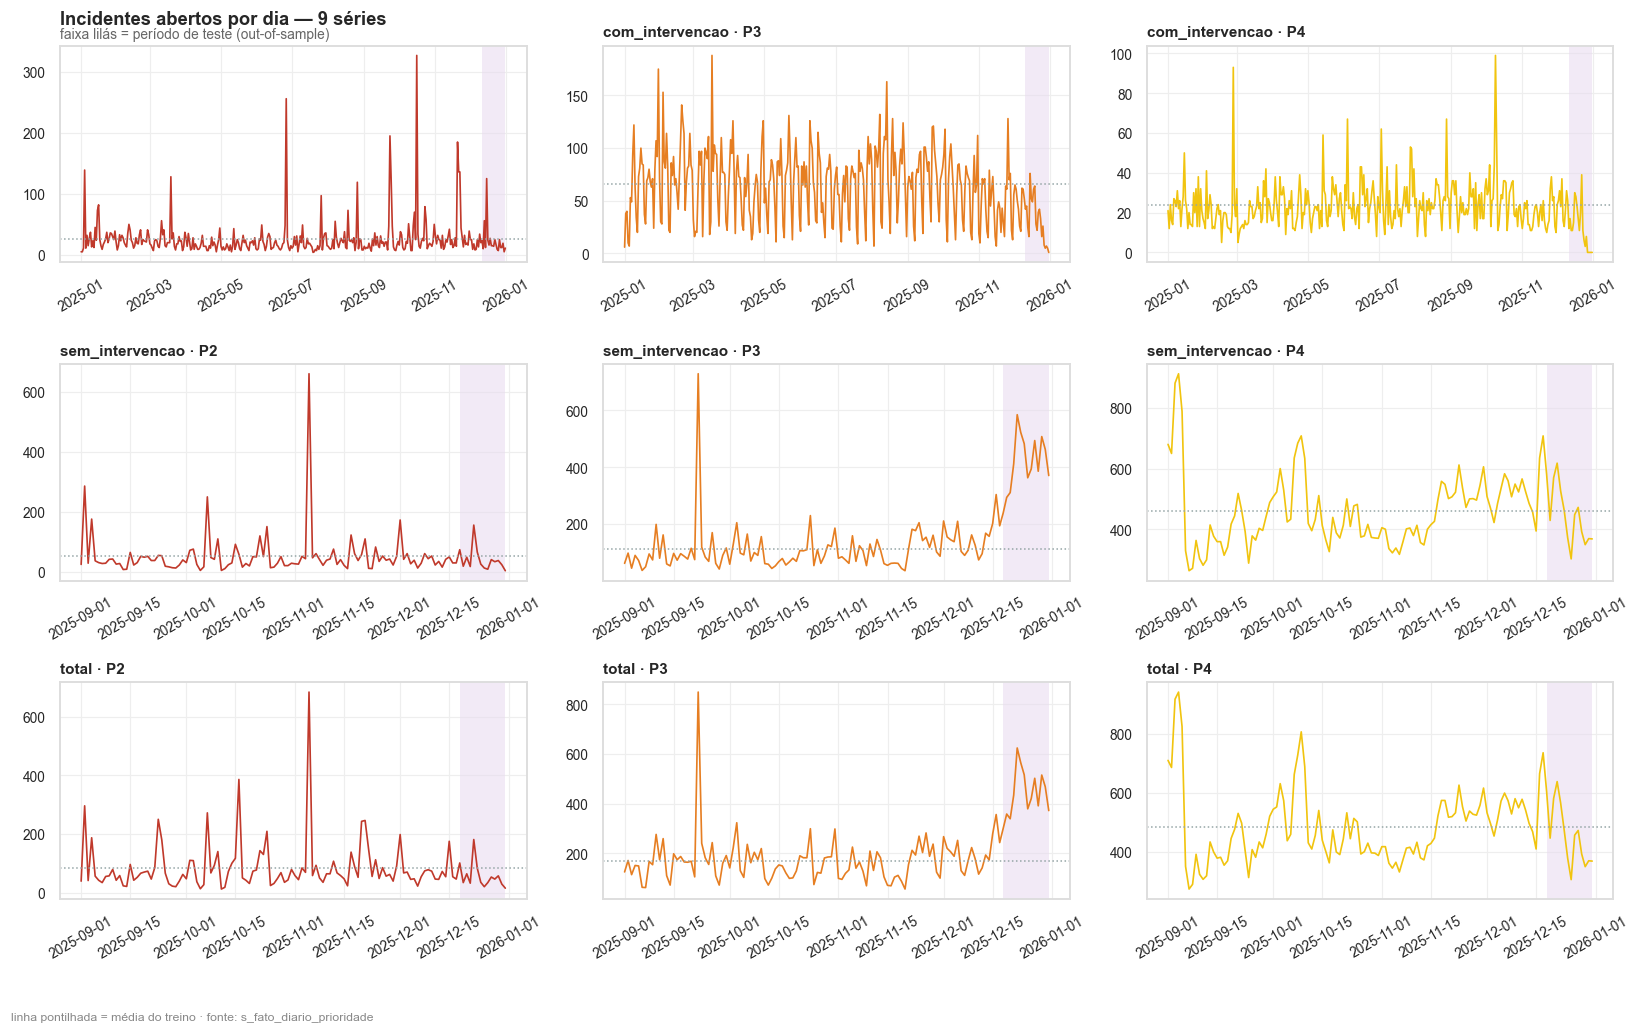

In [7]:
fig, axes = novo_grafico(
    "Incidentes abertos por dia — 9 séries",
    "faixa lilás = período de teste (out-of-sample)",
    figsize=(15, 9), nrows=3, ncols=3,
)
for i, g in enumerate(GRUPOS):
    for j, p in enumerate(PRIORIDADES):
        ax = axes[i, j]
        s = SERIES[(g, p)]
        ax.plot(s.data, s.abertos, color=COR_PRIORIDADE[p], lw=1.1)
        ax.axvspan(CORTE[g], s.data.max(), color=PALETA["teste"], alpha=0.55, lw=0)
        media = SPLIT[(g, p)]["treino"].abertos.mean()
        ax.axhline(media, color=PALETA["neutro"], ls=":", lw=1)
        if i or j:
            ax.set_title(f"{g} · P{p}", fontsize=10)
        ax.tick_params(axis="x", rotation=30)
finalizar(fig, "linha pontilhada = média do treino · fonte: s_fato_diario_prioridade")

## 3.2 Autocorrelação (ACF) e autocorrelação parcial (PACF)

**Como ler.** A **ACF** mede a correlação da série com ela mesma defasada de *k* dias, incluindo
o efeito indireto que passa pelos lags intermediários — um pico em 7, 14, 21 é assinatura de
sazonalidade semanal. A **PACF** mede a mesma correlação *descontando* os lags intermediários —
é ela que diz quantos termos autorregressivos a série realmente precisa. A faixa sombreada é o
intervalo de confiança de 95%: barra dentro da faixa é ruído.

Ambas calculadas apenas no treino, com `method="ywm"` na PACF.

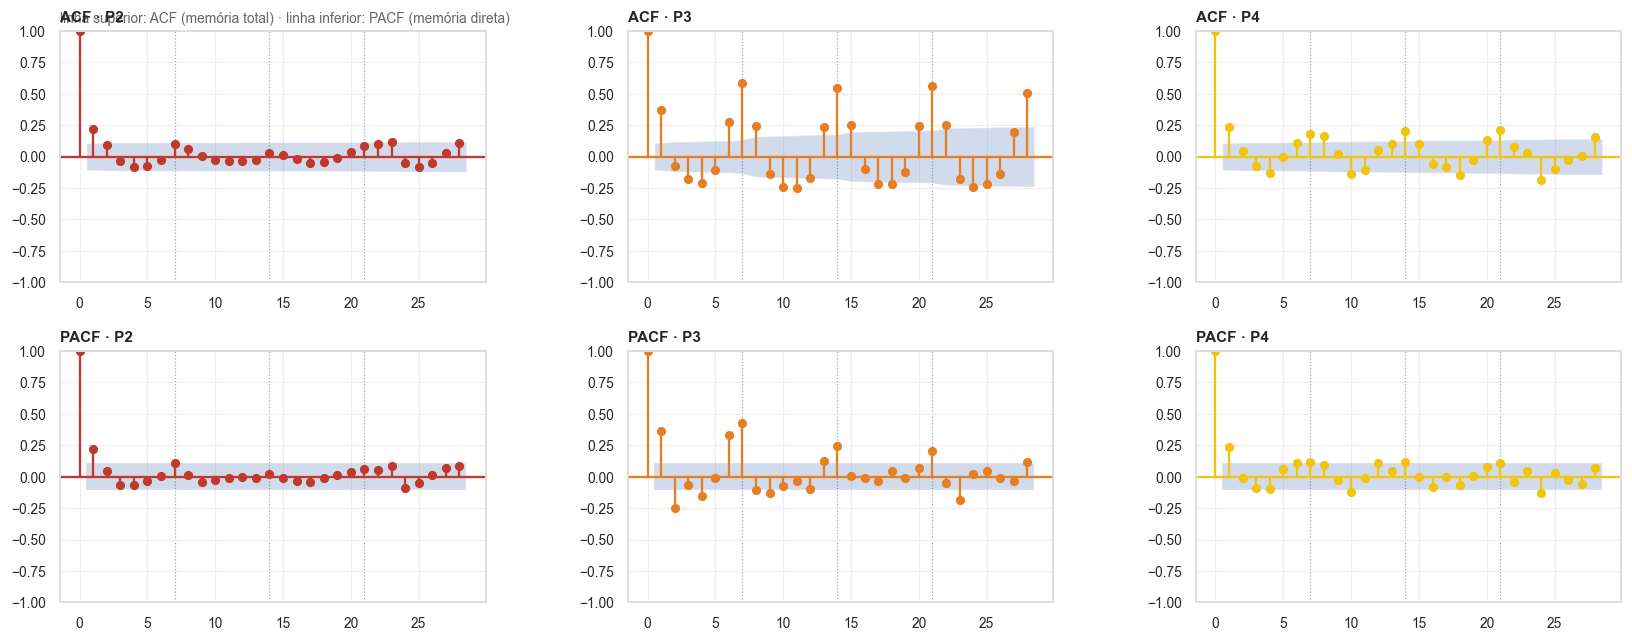

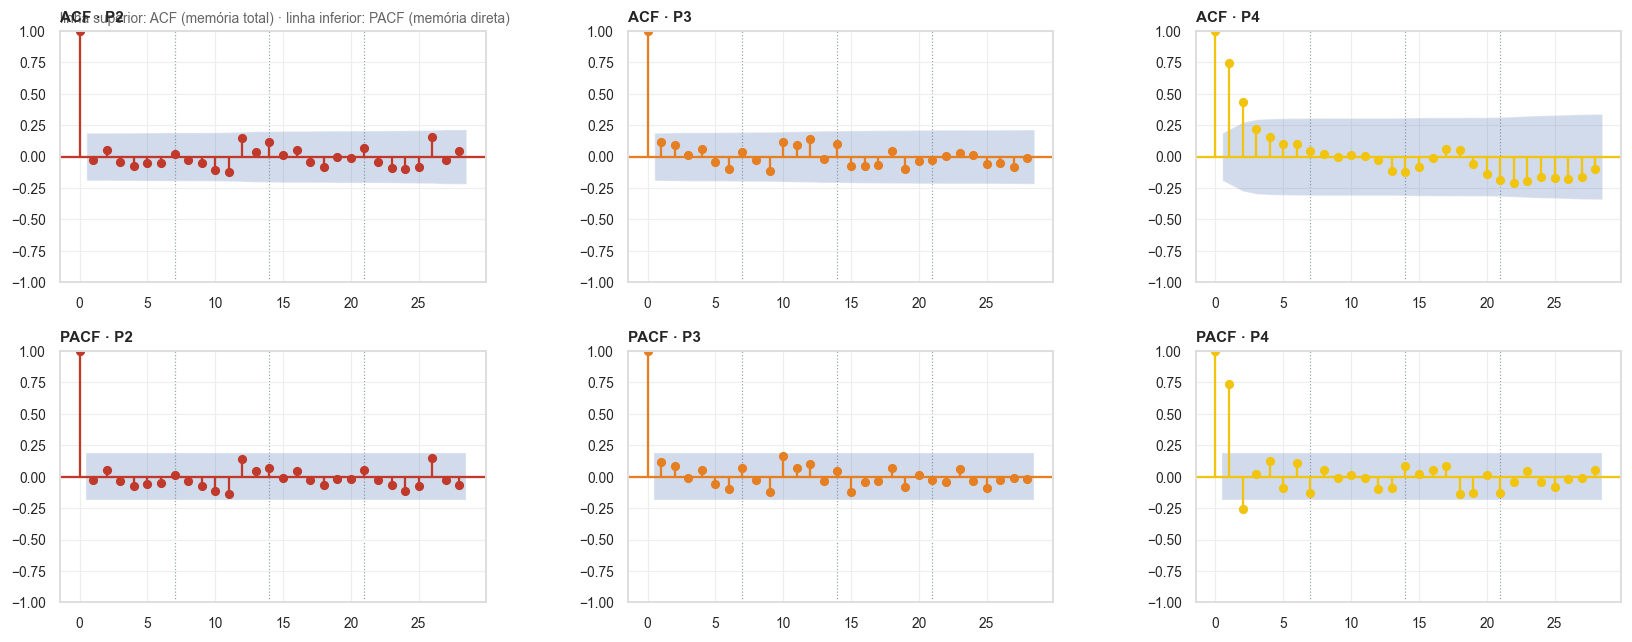

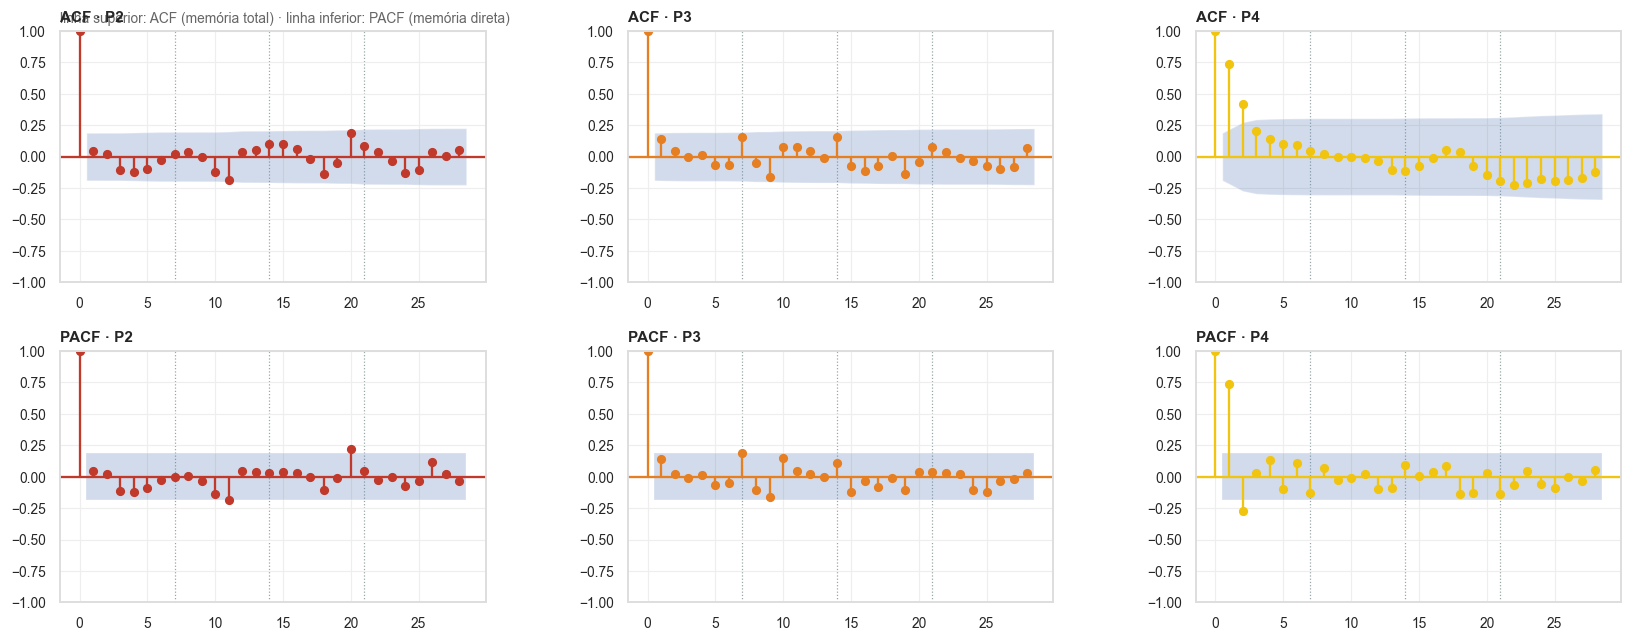

In [8]:
for g in GRUPOS:
    fig, axes = novo_grafico(
        f"ACF e PACF — {g} (só na fatia de treino)",
        "linha superior: ACF (memória total) · linha inferior: PACF (memória direta)",
        figsize=(15, 6), nrows=2, ncols=3,
    )
    for j, p in enumerate(PRIORIDADES):
        y = SPLIT[(g, p)]["treino"].abertos
        n_lags = min(28, len(y) // 2 - 1)
        plot_acf(y, lags=n_lags, ax=axes[0, j], color=COR_PRIORIDADE[p],
                 vlines_kwargs={"colors": COR_PRIORIDADE[p]})
        plot_pacf(y, lags=n_lags, ax=axes[1, j], method="ywm", color=COR_PRIORIDADE[p],
                  vlines_kwargs={"colors": COR_PRIORIDADE[p]})
        axes[0, j].set_title(f"ACF · P{p}", fontsize=10)
        axes[1, j].set_title(f"PACF · P{p}", fontsize=10)
        for ax in (axes[0, j], axes[1, j]):
            for k in (7, 14, 21):
                if k <= n_lags:
                    ax.axvline(k, color=PALETA["neutro"], ls=":", lw=0.8, zorder=0)
    finalizar(fig)

In [9]:
def resumo_autocorrelacao(y, lags=(1, 2, 3, 7, 14)):
    """ACF e PACF nos lags de interesse + o limite de significância de 95%."""
    from statsmodels.tsa.stattools import acf, pacf
    n = len(y)
    maximo = max(lags)
    a = acf(y, nlags=maximo, fft=False)
    pa = pacf(y, nlags=maximo, method="ywm")
    limite = 1.96 / np.sqrt(n)
    return {f"acf_{k}": a[k] for k in lags} | {f"pacf_{k}": pa[k] for k in lags} | {"limite_95": limite}


diag_acf = pd.DataFrame([
    {"grupo": g, "prioridade": p, **resumo_autocorrelacao(SPLIT[(g, p)]["treino"].abertos)}
    for g in GRUPOS for p in PRIORIDADES
])
tabela(diag_acf, "ACF/PACF nos lags relevantes — valor acima de `limite_95` é sinal, não ruído", casas=3)

**ACF/PACF nos lags relevantes — valor acima de `limite_95` é sinal, não ruído**

| grupo           |   prioridade |   acf_1 |   acf_2 |   acf_3 |   acf_7 |   acf_14 |   pacf_1 |   pacf_2 |   pacf_3 |   pacf_7 |   pacf_14 |   limite_95 |
|:----------------|-------------:|--------:|--------:|--------:|--------:|---------:|---------:|---------:|---------:|---------:|----------:|------------:|
| com_intervencao |            2 |   0.219 |   0.088 |  -0.036 |   0.098 |    0.025 |    0.219 |    0.042 |   -0.067 |    0.111 |     0.018 |       0.106 |
| com_intervencao |            3 |   0.367 |  -0.078 |  -0.18  |   0.585 |    0.545 |    0.367 |   -0.245 |   -0.067 |    0.425 |     0.245 |       0.106 |
| com_intervencao |            4 |   0.234 |   0.044 |  -0.077 |   0.177 |    0.207 |    0.234 |   -0.011 |   -0.089 |    0.119 |     0.113 |       0.106 |
| sem_intervencao |            2 |  -0.03  |   0.052 |  -0.04  |   0.018 |    0.116 |   -0.03  |    0.051 |   -0.037 |    0.014 |     0.072 |       0.189 |
| sem_intervencao |            3 |   0.115 |   0.094 |   0.009 |   0.039 |    0.096 |    0.115 |    0.082 |   -0.011 |    0.071 |     0.047 |       0.189 |
| sem_intervencao |            4 |   0.74  |   0.431 |   0.219 |   0.046 |   -0.125 |    0.74  |   -0.258 |    0.02  |   -0.127 |     0.081 |       0.189 |
| total           |            2 |   0.042 |   0.023 |  -0.108 |   0.02  |    0.099 |    0.042 |    0.021 |   -0.11  |   -0.001 |     0.029 |       0.189 |
| total           |            3 |   0.143 |   0.045 |  -0.001 |   0.159 |    0.158 |    0.143 |    0.025 |   -0.011 |    0.186 |     0.106 |       0.189 |
| total           |            4 |   0.739 |   0.42  |   0.204 |   0.043 |   -0.118 |    0.739 |   -0.275 |    0.026 |   -0.129 |     0.089 |       0.189 |

## 3.3 Decomposição STL

STL (*Seasonal-Trend decomposition using Loess*) quebra a série em **tendência + sazonalidade +
resíduo**. Uso período 7 (semana), não 365: com 122 dias na janela mais curta não há dois ciclos
anuais para estimar sazonalidade anual — pedir isso ao STL produziria uma componente inventada.

A métrica que resume cada painel é a **força da componente**, no sentido de Hyndman:

`força = max(0, 1 - Var(resíduo) / Var(resíduo + componente))`

Perto de 1, a componente domina; perto de 0, ela é irrelevante diante do ruído.

In [10]:
def forca_componente(residuo, componente):
    """Força da componente (Hyndman): 1 - Var(R) / Var(R + componente)."""
    denominador = np.var(residuo + componente)
    if denominador <= 0:
        return 0.0
    return float(max(0.0, 1 - np.var(residuo) / denominador))


DECOMPOSICAO = {}
linhas_stl = []
for g in GRUPOS:
    for p in PRIORIDADES:
        s = SERIES[(g, p)]
        y = pd.Series(s.abertos.values, index=pd.DatetimeIndex(s.data), name="abertos")
        res = STL(y, period=PERIODO_SAZONAL, robust=True).fit()
        DECOMPOSICAO[(g, p)] = res
        linhas_stl.append({
            "grupo": g, "prioridade": p,
            "forca_tendencia": forca_componente(res.resid, res.trend),
            "forca_sazonal": forca_componente(res.resid, res.seasonal),
            "dp_residuo": float(np.std(res.resid)),
            "residuo_sobre_media": float(np.std(res.resid) / y.mean()),
        })

tabela(pd.DataFrame(linhas_stl),
       "Força das componentes STL — quanto de cada série é estrutura e quanto é ruído", casas=3)

**Força das componentes STL — quanto de cada série é estrutura e quanto é ruído**

| grupo           |   prioridade |   forca_tendencia |   forca_sazonal |   dp_residuo |   residuo_sobre_media |
|:----------------|-------------:|------------------:|----------------:|-------------:|----------------------:|
| com_intervencao |            2 |             0.04  |           0.128 |       28.124 |                 1.094 |
| com_intervencao |            3 |             0.407 |           0.653 |       17.606 |                 0.276 |
| com_intervencao |            4 |             0.231 |           0.257 |        8.992 |                 0.389 |
| sem_intervencao |            2 |             0.014 |           0.128 |       65.011 |                 1.267 |
| sem_intervencao |            3 |             0.654 |           0.085 |       73.55  |                 0.5   |
| sem_intervencao |            4 |             0.44  |           0.069 |       89.623 |                 0.195 |
| total           |            2 |             0.047 |           0.133 |       75.369 |                 0.919 |
| total           |            3 |             0.58  |           0.209 |       77.902 |                 0.386 |
| total           |            4 |             0.429 |           0.06  |       94.381 |                 0.196 |

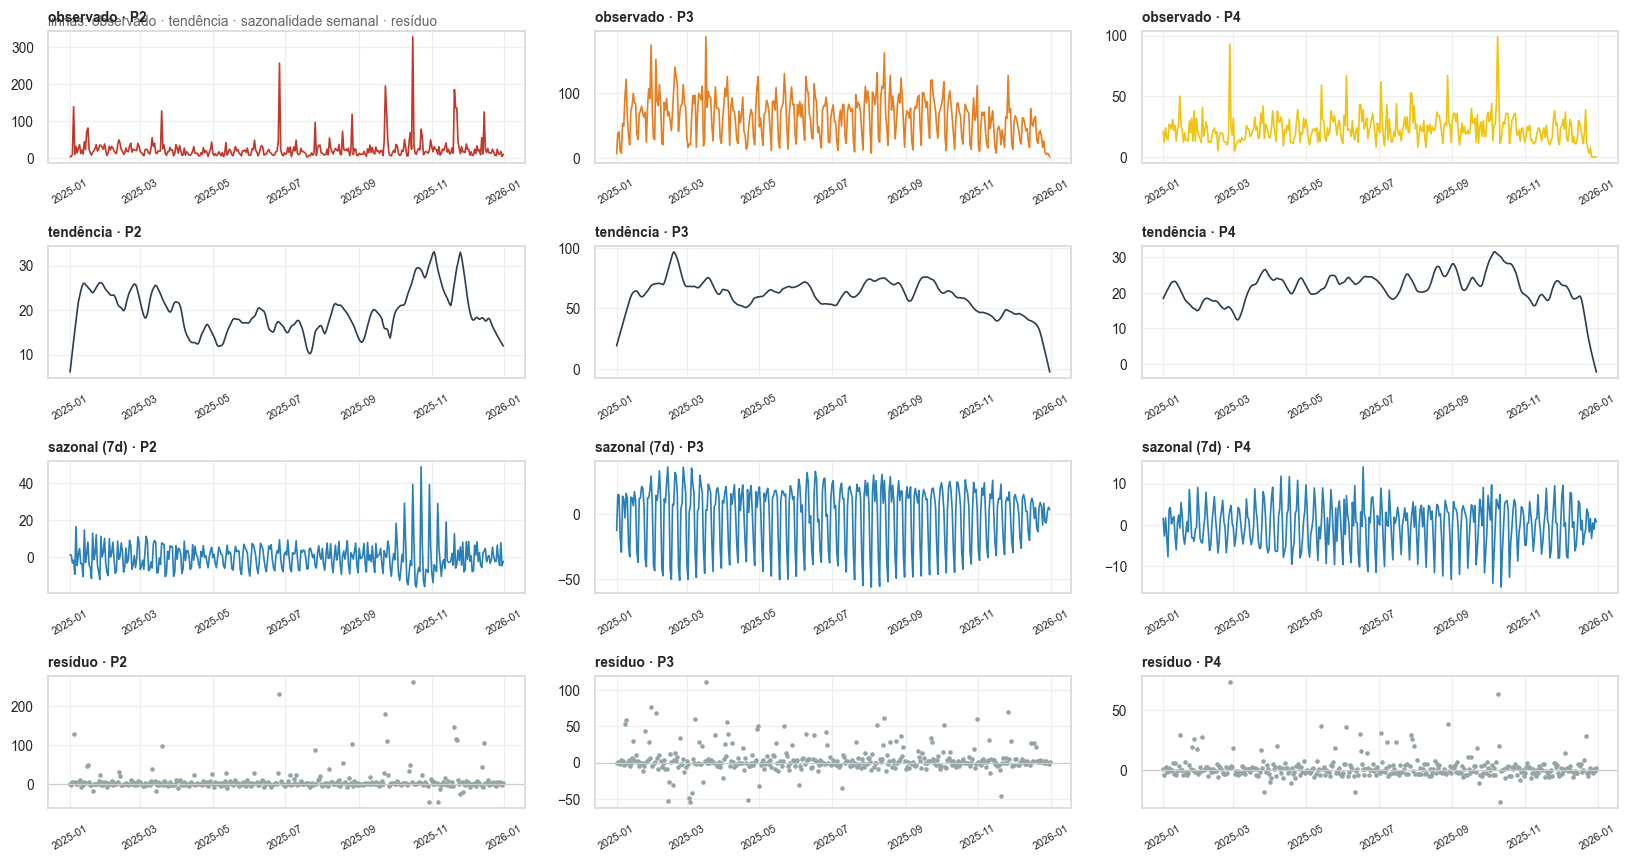

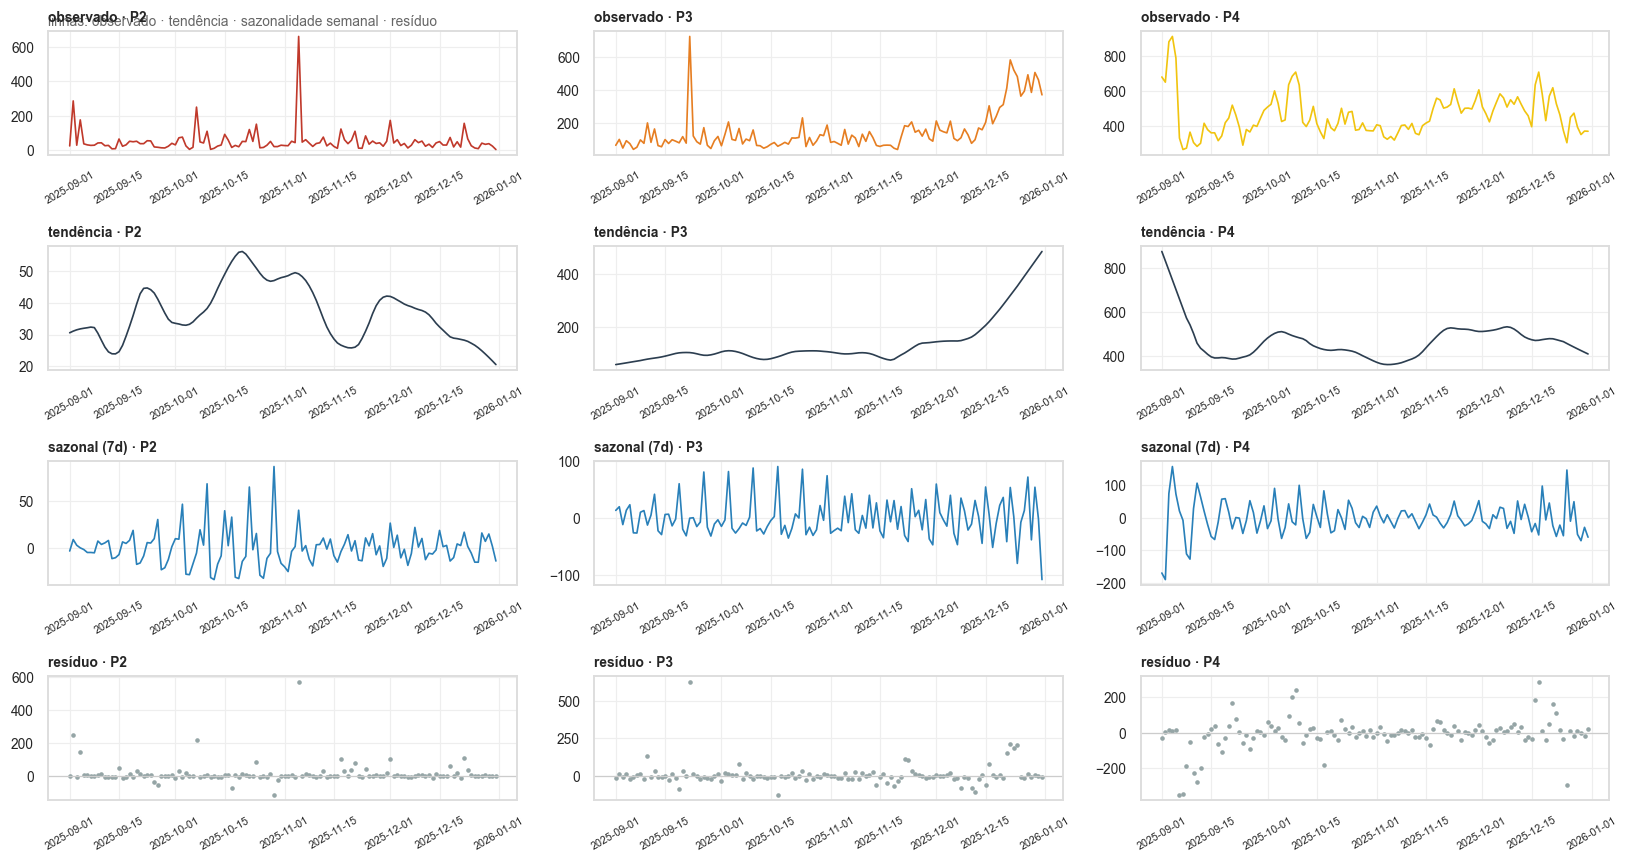

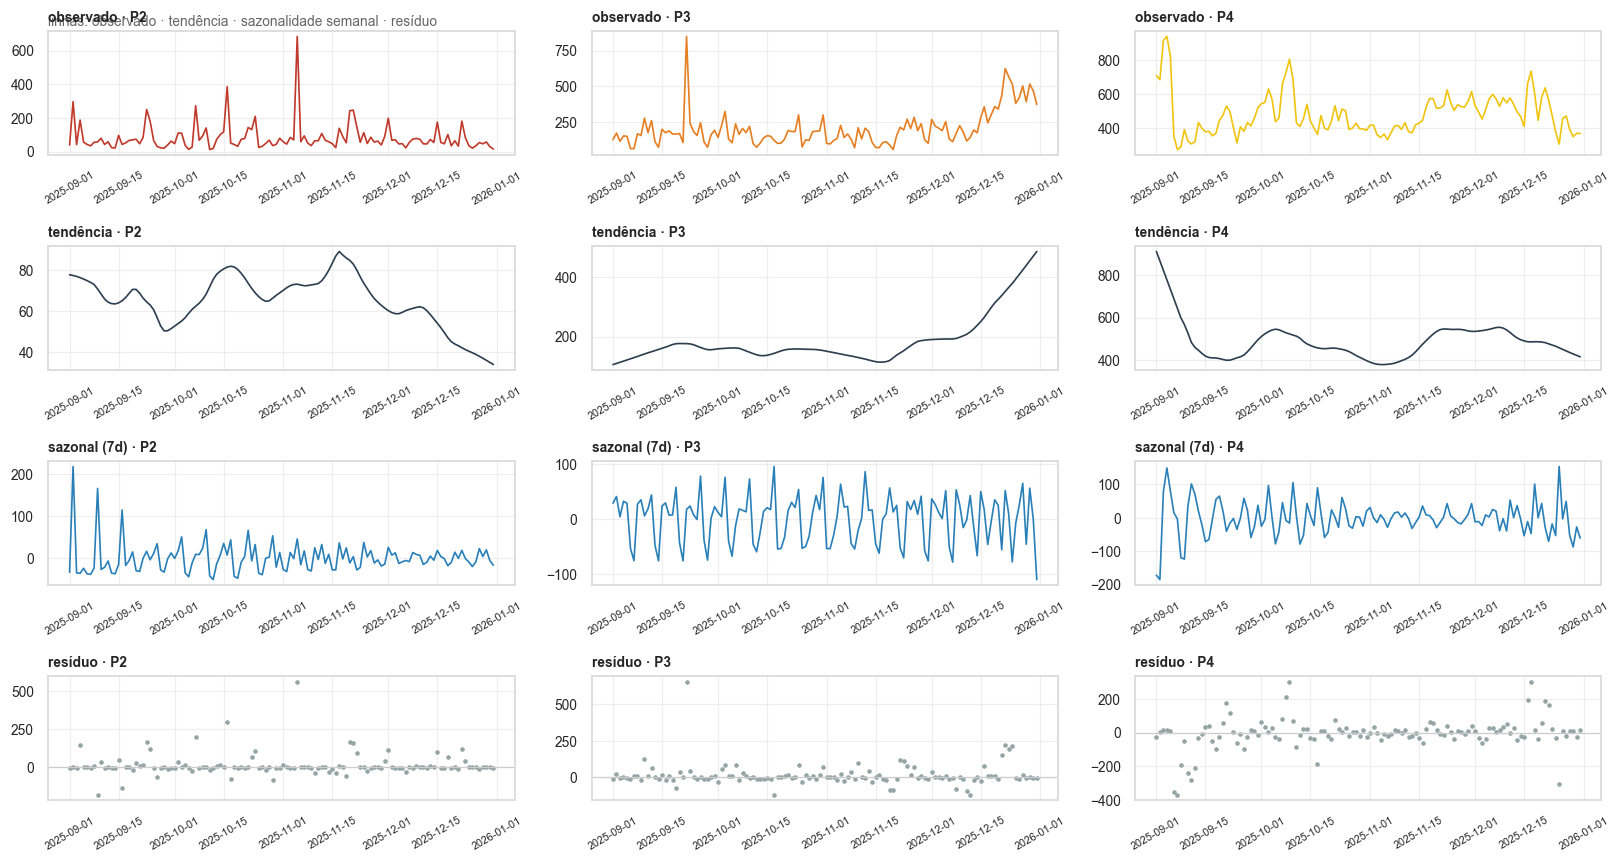

In [11]:
for g in GRUPOS:
    fig, axes = novo_grafico(
        f"Decomposição STL (período 7) — {g}",
        "linhas: observado · tendência · sazonalidade semanal · resíduo",
        figsize=(15, 8), nrows=4, ncols=3,
    )
    for j, p in enumerate(PRIORIDADES):
        res = DECOMPOSICAO[(g, p)]
        componentes = [
            ("observado", res.observed, COR_PRIORIDADE[p]),
            ("tendência", res.trend, PALETA["total"]),
            ("sazonal (7d)", res.seasonal, PALETA["destaque"]),
            ("resíduo", res.resid, PALETA["neutro"]),
        ]
        for i, (nome, serie, cor) in enumerate(componentes):
            ax = axes[i, j]
            if nome == "resíduo":
                ax.axhline(0, color="#CCCCCC", lw=0.8)
                ax.scatter(serie.index, serie.values, s=4, color=cor)
            else:
                ax.plot(serie.index, serie.values, color=cor, lw=1.1)
            ax.set_title(f"{nome} · P{p}" if i or j else f"observado · P{p}", fontsize=9)
            ax.tick_params(axis="x", rotation=30, labelsize=7)
    finalizar(fig)

## 3.4 Observações — o que cada gráfico permite constatar

A célula abaixo lê os números que acabaram de ser calculados e escreve as observações a partir
deles, em vez de deixá-las escritas à mão num markdown que envelhece se o dado mudar.

In [12]:
from IPython.display import Markdown, display

stl = pd.DataFrame(linhas_stl).set_index(["grupo", "prioridade"])
acf_idx = diag_acf.set_index(["grupo", "prioridade"])

partes = ["### Observações lidas dos gráficos de §3\n"]

# --- 1. nível e escala
partes.append("**1. Nível e escala separam os grupos antes de qualquer modelo.**\n")
for g in GRUPOS:
    medias = ", ".join(f"P{p} ≈ {SERIES[(g, p)].abertos.mean():.0f}/dia" for p in PRIORIDADES)
    partes.append(f"- `{g}`: {medias}.")
maior = resumo.loc[resumo.media_dia.idxmax()]
menor = resumo.loc[resumo.media_dia.idxmin()]
partes.append(
    f"\nA série mais volumosa (`{maior.grupo}` P{int(maior.prioridade)}, {maior.media_dia:.0f}/dia) tem "
    f"**{maior.media_dia / menor.media_dia:.0f}×** o volume da menor (`{menor.grupo}` "
    f"P{int(menor.prioridade)}, {menor.media_dia:.0f}/dia). Consequência prática: **MAE não é "
    "comparável entre séries** — só dentro da mesma série. Por isso §8 reporta MASE ao lado do "
    "MAE, que é escala-livre e não quebra nos dias de contagem zero.\n"
)

# --- 2. ACF
partes.append("**2. ACF — a memória é curta e a sazonalidade semanal é fraca.**\n")
for g in GRUPOS:
    for p in PRIORIDADES:
        r = acf_idx.loc[(g, p)]
        lag1 = "significativo" if abs(r.acf_1) > r.limite_95 else "dentro do ruído"
        lag7 = "significativo" if abs(r.acf_7) > r.limite_95 else "dentro do ruído"
        partes.append(
            f"- `{g}` P{p}: ACF(1) = {r.acf_1:.2f} ({lag1}), ACF(7) = {r.acf_7:.2f} ({lag7}) "
            f"— limite de 95% em ±{r.limite_95:.2f}."
        )
n_sig7 = int((acf_idx.acf_7.abs() > acf_idx.limite_95).sum())
partes.append(
    f"\nEm **{n_sig7} das 9 séries** o lag 7 passa do limite de significância. "
    + ("Sazonalidade semanal existe mas é modesta — justifica *testar* SARIMA contra ARIMA, não "
       "assumir que o termo sazonal vai valer o custo.\n"
       if n_sig7 <= 6 else
       "Sazonalidade semanal presente na maioria das séries — o termo sazonal do SARIMA e a "
       "sazonalidade semanal do Prophet têm o que capturar.\n")
)

# --- 3. PACF
partes.append("**3. PACF — corte rápido: pouca ordem autorregressiva.**\n")
maior_ordem = {}
for g in GRUPOS:
    for p in PRIORIDADES:
        r = acf_idx.loc[(g, p)]
        sig = [k for k in (1, 2, 3, 7, 14) if abs(r[f"pacf_{k}"]) > r.limite_95]
        maior_ordem[(g, p)] = max(sig) if sig else 0
        partes.append(f"- `{g}` P{p}: lags com PACF significativa = {sig if sig else 'nenhum'}.")
partes.append(
    "\nA PACF cortando cedo é o argumento a favor de **ordens baixas** no ARIMA/SARIMA: uma "
    "estrutura autorregressiva longa gastaria parâmetros em lags que não carregam sinal — caro "
    "sobretudo nas séries de 122 dias.\n"
)

# --- 4. STL
partes.append("**4. Decomposição — o resíduo domina, e é isso que limita o teto de acerto.**\n")
for g in GRUPOS:
    for p in PRIORIDADES:
        r = stl.loc[(g, p)]
        partes.append(
            f"- `{g}` P{p}: força da tendência = {r.forca_tendencia:.2f}, "
            f"força sazonal = {r.forca_sazonal:.2f}, "
            f"desvio do resíduo = {r.residuo_sobre_media * 100:.0f}% da média da série."
        )
partes.append(
    f"\nA sazonalidade semanal média das 9 séries é **{stl.forca_sazonal.mean():.2f}** contra "
    f"**{stl.forca_tendencia.mean():.2f}** de tendência. O resíduo responde, em média, por "
    f"**{stl.residuo_sobre_media.mean() * 100:.0f}%** da média do nível — é a **componente "
    "estocástica** que a instrução de §5 quer entender. Nenhum dos modelos de §7 explica essa "
    "parcela a partir do próprio passado; se algo a explica, tem de vir de fora da série, e é "
    "exatamente isso que o XGBoost de §5 vai procurar.\n"
)

# --- 5. o que isso decide
partes.append("**5. O que essas três leituras decidem para o resto do notebook.**\n")
partes.append(
    "- Memória curta (PACF) + sazonalidade semanal fraca a moderada (ACF/STL) → **ARIMA de ordem "
    "baixa é um candidato competitivo**, e o SARIMA precisa provar que o termo sazonal paga o "
    "custo em parâmetro.\n"
    "- Tendência fraca em quase todas as séries → o componente de tendência do Prophet tem pouco "
    "a capturar; o valor dele aqui vem de feriados e sazonalidade, não de trend.\n"
    "- Resíduo alto → **o baseline ingênuo vai ser um adversário duro**. Numa série dominada por "
    "ruído, repetir o último valor é difícil de bater, e §8 leva isso a sério em vez de tratá-lo "
    "como formalidade.\n"
    "- Escalas muito diferentes entre séries → cada série ganha o seu próprio modelo e o seu "
    "próprio escalonamento no LSTM."
)

display(Markdown("\n".join(partes)))

### Observações lidas dos gráficos de §3

**1. Nível e escala separam os grupos antes de qualquer modelo.**

- `com_intervencao`: P2 ≈ 26/dia, P3 ≈ 64/dia, P4 ≈ 23/dia.
- `sem_intervencao`: P2 ≈ 51/dia, P3 ≈ 147/dia, P4 ≈ 460/dia.
- `total`: P2 ≈ 82/dia, P3 ≈ 202/dia, P4 ≈ 482/dia.

A série mais volumosa (`total` P4, 482/dia) tem **21×** o volume da menor (`com_intervencao` P4, 23/dia). Consequência prática: **MAE não é comparável entre séries** — só dentro da mesma série. Por isso §8 reporta MASE ao lado do MAE, que é escala-livre e não quebra nos dias de contagem zero.

**2. ACF — a memória é curta e a sazonalidade semanal é fraca.**

- `com_intervencao` P2: ACF(1) = 0.22 (significativo), ACF(7) = 0.10 (dentro do ruído) — limite de 95% em ±0.11.
- `com_intervencao` P3: ACF(1) = 0.37 (significativo), ACF(7) = 0.58 (significativo) — limite de 95% em ±0.11.
- `com_intervencao` P4: ACF(1) = 0.23 (significativo), ACF(7) = 0.18 (significativo) — limite de 95% em ±0.11.
- `sem_intervencao` P2: ACF(1) = -0.03 (dentro do ruído), ACF(7) = 0.02 (dentro do ruído) — limite de 95% em ±0.19.
- `sem_intervencao` P3: ACF(1) = 0.12 (dentro do ruído), ACF(7) = 0.04 (dentro do ruído) — limite de 95% em ±0.19.
- `sem_intervencao` P4: ACF(1) = 0.74 (significativo), ACF(7) = 0.05 (dentro do ruído) — limite de 95% em ±0.19.
- `total` P2: ACF(1) = 0.04 (dentro do ruído), ACF(7) = 0.02 (dentro do ruído) — limite de 95% em ±0.19.
- `total` P3: ACF(1) = 0.14 (dentro do ruído), ACF(7) = 0.16 (dentro do ruído) — limite de 95% em ±0.19.
- `total` P4: ACF(1) = 0.74 (significativo), ACF(7) = 0.04 (dentro do ruído) — limite de 95% em ±0.19.

Em **2 das 9 séries** o lag 7 passa do limite de significância. Sazonalidade semanal existe mas é modesta — justifica *testar* SARIMA contra ARIMA, não assumir que o termo sazonal vai valer o custo.

**3. PACF — corte rápido: pouca ordem autorregressiva.**

- `com_intervencao` P2: lags com PACF significativa = [1, 7].
- `com_intervencao` P3: lags com PACF significativa = [1, 2, 7, 14].
- `com_intervencao` P4: lags com PACF significativa = [1, 7, 14].
- `sem_intervencao` P2: lags com PACF significativa = nenhum.
- `sem_intervencao` P3: lags com PACF significativa = nenhum.
- `sem_intervencao` P4: lags com PACF significativa = [1, 2].
- `total` P2: lags com PACF significativa = nenhum.
- `total` P3: lags com PACF significativa = nenhum.
- `total` P4: lags com PACF significativa = [1, 2].

A PACF cortando cedo é o argumento a favor de **ordens baixas** no ARIMA/SARIMA: uma estrutura autorregressiva longa gastaria parâmetros em lags que não carregam sinal — caro sobretudo nas séries de 122 dias.

**4. Decomposição — o resíduo domina, e é isso que limita o teto de acerto.**

- `com_intervencao` P2: força da tendência = 0.04, força sazonal = 0.13, desvio do resíduo = 109% da média da série.
- `com_intervencao` P3: força da tendência = 0.41, força sazonal = 0.65, desvio do resíduo = 28% da média da série.
- `com_intervencao` P4: força da tendência = 0.23, força sazonal = 0.26, desvio do resíduo = 39% da média da série.
- `sem_intervencao` P2: força da tendência = 0.01, força sazonal = 0.13, desvio do resíduo = 127% da média da série.
- `sem_intervencao` P3: força da tendência = 0.65, força sazonal = 0.09, desvio do resíduo = 50% da média da série.
- `sem_intervencao` P4: força da tendência = 0.44, força sazonal = 0.07, desvio do resíduo = 20% da média da série.
- `total` P2: força da tendência = 0.05, força sazonal = 0.13, desvio do resíduo = 92% da média da série.
- `total` P3: força da tendência = 0.58, força sazonal = 0.21, desvio do resíduo = 39% da média da série.
- `total` P4: força da tendência = 0.43, força sazonal = 0.06, desvio do resíduo = 20% da média da série.

A sazonalidade semanal média das 9 séries é **0.19** contra **0.32** de tendência. O resíduo responde, em média, por **58%** da média do nível — é a **componente estocástica** que a instrução de §5 quer entender. Nenhum dos modelos de §7 explica essa parcela a partir do próprio passado; se algo a explica, tem de vir de fora da série, e é exatamente isso que o XGBoost de §5 vai procurar.

**5. O que essas três leituras decidem para o resto do notebook.**

- Memória curta (PACF) + sazonalidade semanal fraca a moderada (ACF/STL) → **ARIMA de ordem baixa é um candidato competitivo**, e o SARIMA precisa provar que o termo sazonal paga o custo em parâmetro.
- Tendência fraca em quase todas as séries → o componente de tendência do Prophet tem pouco a capturar; o valor dele aqui vem de feriados e sazonalidade, não de trend.
- Resíduo alto → **o baseline ingênuo vai ser um adversário duro**. Numa série dominada por ruído, repetir o último valor é difícil de bater, e §8 leva isso a sério em vez de tratá-lo como formalidade.
- Escalas muito diferentes entre séries → cada série ganha o seu próprio modelo e o seu próprio escalonamento no LSTM.

---

# 4. Visualização das features

Pergunta desta seção: **das features disponíveis nas camadas silver, quais têm relação com o
volume de incidentes?**

Duas leituras diferentes, que respondem a coisas diferentes:

| Leitura | Correlação de… | Serve para |
|---|---|---|
| **Contemporânea** | feature em D × `abertos` em D | descrever o que acompanha o volume |
| **Preditiva** | feature em D × `abertos` em **D+1** | descobrir o que pode virar feature de modelo |

Só a segunda tem valor para previsão. A primeira entra porque expõe um problema que
contaminaria a leitura: várias colunas do fato são **decomposições do próprio alvo**
(`abertos_monitoramento + abertos_manual = abertos`) e por isso correlacionam quase 1 com ele —
sem serem informativas. Elas ficam marcadas na tabela.

Uso **Spearman**, não Pearson: as séries têm picos fortes (P2 chega a 660 num dia de média 51) e
Pearson seria sequestrado por esses pontos.

In [ ]:
concentracao = pd.read_csv(CAMINHO_SILVER / "s_ft_concentracao.csv", sep=";", parse_dates=["data"])
features_ic = pd.read_csv(CAMINHO_SILVER / "s_ft_ic.csv", sep=";", parse_dates=["data"])
diario = pd.read_csv(CAMINHO_SILVER / "s_fato_diario.csv", sep=";", parse_dates=["data"])

# Time responsável e descrição resumida — as duas dimensões que a silver descreve e que este
# notebook nunca tinha carregado. Vêm no grão dia × valor × tipo_tratamento, o mesmo das séries.
fato_time = pd.read_csv(CAMINHO_SILVER / "s_fato_diario_time.csv", sep=";", parse_dates=["data"])
fato_classe = pd.read_csv(CAMINHO_SILVER / "s_fato_diario_classe.csv", sep=";", parse_dates=["data"])
ft_texto = pd.read_csv(CAMINHO_SILVER / "s_ft_texto.csv", sep=";", parse_dates=["data"])

# Colunas do fato diário que não são calendário (o calendário já entra por s_dim_calendario).
cols_diario = [c for c in diario.columns
               if c not in calendario.columns and c != "data"]

# Colunas do próprio grão (data × prioridade × tipo) que não são o alvo nem chave.
NAO_FEATURE = {"data", "prioridade", "tipo_tratamento", "abertos", "regime",
               "y_abertos_d1", "y_abertos_d7", "y_abertos_acum_1a7"}
cols_grao = [c for c in fato.columns if c not in NAO_FEATURE]

# Decomposições do alvo: somam de volta em `abertos` no mesmo dia.
TAUTOLOGICAS = {
    "abertos_monitoramento", "abertos_manual",
    "abertos_hor_comercial", "abertos_fora_hor_comercial",
}

# --- Times que viram coluna própria ---------------------------------------------------------
# 17 times, mas a distribuição é brutalmente desigual: um deles concentra ~3/4 do volume e a
# cauda tem times com um punhado de incidentes no ano. Uma coluna por time seria quase toda
# ruído, então só os que sustentam o volume viram coluna; o resto vira o bucket `outros`.
# O corte sai do **treino** de todos os grupos (data < menor CORTE) — escolher a lista olhando
# o volume total seria deixar o teste opinar sobre quais features existem.
CORTE_FEATURE = min(CORTE.values())
COBERTURA_TIME = 0.95

_vol_treino = (fato_time[fato_time.data < CORTE_FEATURE]
               .groupby("time")[[f"abertos_p{p}" for p in PRIORIDADES]].sum().sum(axis=1)
               .sort_values(ascending=False))
_share = _vol_treino / _vol_treino.sum()
TIMES_COLUNA = list(_share.index[:max(1, int((_share.cumsum() < COBERTURA_TIME).sum() + 1))])
CLASSES_COLUNA = sorted(fato_classe.classe_descricao.dropna().unique())

print(f"features do grão (data x prioridade x tipo): {len(cols_grao)}")
print(f"features do dia (s_fato_diario):             {len(cols_diario)}")
print(f"features de IC (s_ft_ic):                    {len(features_ic.columns) - 1}")
print(f"features de concentração:                    {len(concentracao.columns) - 1}")
print(f"features de calendário:                      {len(FEATURES_CALENDARIO)}")
print(f"features de texto (s_ft_texto):              {len(ft_texto.columns) - 3}")
print()
print(f"corte de referência para escolher features:  {CORTE_FEATURE:%Y-%m-%d}")
print(f"times com coluna própria ({_share[TIMES_COLUNA].sum():.1%} do volume de treino): "
      f"{TIMES_COLUNA}")
print(f"classes de descrição:                        {len(CLASSES_COLUNA)} — {CLASSES_COLUNA}")


In [ ]:
CHAVES_PAINEL = ["data", "prioridade", "tipo_tratamento"]

# Janelas em que a composição é medida. Um share de um único dia é instável onde o volume é
# baixo — `com_intervencao` P2 tem média de ~5 incidentes/dia, então UM incidente desloca a
# participação de um time em 20 pontos percentuais. Medir a composição em janela troca esse
# ruído amostral por uma estimativa do mix corrente.
#   lag1 = ontem (D−1);  7d/30d = janelas fechando em D, inclusive.
# Mesma convenção de `abertos_lag_1` / `abertos_media_7d` na silver.
JANELAS_MIX = {"lag1": 1, "7d": 7, "30d": 30}


def share_em_janela(largo, janela, nome):
    """Participação de cada coluna de `largo` na janela, dentro de cada série.

    `largo` chega indexado por (data, prioridade, tipo_tratamento), uma coluna por bucket, com a
    CONTAGEM de incidentes do dia. Devolve as mesmas colunas como proporção da janela.

    É **razão de somas** (soma do bucket na janela ÷ soma total na janela), não média das razões
    diárias. As duas divergem quando o volume oscila, e é a razão de somas que responde "que
    fração da carga da semana foi deste time" — a média das razões daria o mesmo peso a um
    domingo de 3 incidentes e a uma terça de 400.

    O `rolling` corre dentro de cada série. A silver garante grade de datas completa, então
    janela de 7 dias é 7 *dias* e não 7 *registros* — sem isso o resultado seria silenciosamente
    errado nos trechos em que a série tem dias vazios.
    """
    g = largo.groupby(level=["prioridade", "tipo_tratamento"], observed=True)
    if nome == "lag1":
        somas = g.shift(1)
    else:
        somas = g.rolling(janela, min_periods=1).sum().reset_index(level=[0, 1], drop=True)
        somas = somas.reindex(largo.index)
    total = somas.sum(axis=1)
    return somas.div(total.where(total > 0), axis=0)


def encoding_categorico(fato, dimensao, valores, prefixo, incluir_total=True, resumo=False):
    """Composição de uma dimensão categórica ao longo do tempo, no grão data × prioridade × tipo.

    Num grão diário, "one-hot" não é uma coluna 0/1 por linha: o que interessa é **que fração da
    carga** coube a cada valor da categoria. A contagem inteira não vira feature — as contagens
    dos buckets somam exatamente `abertos`, então seriam o alvo reescrito em outra base, sem
    informação nova sobre ele (`abertos` já está no modelo como lag 1). Elas existem aqui só como
    matriz intermediária, e o assert abaixo usa essa propriedade para provar que o pivot não
    perdeu nem duplicou incidente.

    Valores fora de `valores` caem no bucket `outros`, para que a soma dos shares continue 1.

    O grupo `total` é montado **aqui**, somando as contagens antes de dividir. Somar shares (que
    é o que aconteceria se o `total` fosse construído a jusante) não significa nada: dois shares
    de 0,8 somam 1,6.
    """
    longo = fato.melt(
        id_vars=["data", dimensao, "tipo_tratamento"],
        value_vars=[f"abertos_p{p}" for p in PRIORIDADES],
        var_name="prioridade", value_name="n",
    )
    longo["prioridade"] = longo.prioridade.str.replace("abertos_p", "", regex=False).astype(int)
    longo[dimensao] = np.where(longo[dimensao].isin(valores), longo[dimensao], "outros")

    if incluir_total:
        soma = longo.groupby(["data", "prioridade", dimensao], as_index=False)["n"].sum()
        soma["tipo_tratamento"] = "total"
        longo = pd.concat([longo, soma], ignore_index=True)

    largo = (longo.groupby(CHAVES_PAINEL + [dimensao], observed=True)["n"].sum()
             .unstack(dimensao, fill_value=0)
             .sort_index(level=["prioridade", "tipo_tratamento", "data"]))

    # A contagem particiona o dia: é o que garante que o pivot está correto.
    CONTAGENS_POR_DIMENSAO[prefixo] = largo

    blocos = []
    for nome, janela in JANELAS_MIX.items():
        share = share_em_janela(largo, janela, nome)
        blocos.append(share.add_prefix(f"mix{prefixo}_").add_suffix(f"_{nome}"))
        if resumo:
            blocos.append(resumo_concentracao(share, f"conc{prefixo}_{nome}"))
    return pd.concat(blocos, axis=1).reset_index()


def resumo_concentracao(shares, prefixo):
    """Diversidade e concentração a partir de uma matriz de shares — exata só se ela for completa.

    Aplicado às classes de descrição, onde as 11 viram coluna e nada cai no bucket `outros`.
    Não é aplicado aos times: lá a matriz é truncada no top-K, e um HHI calculado sobre buckets
    mediria a concentração entre os buckets, não entre os times. Para essa leitura já existe
    `hhi_times` no grão dia, vindo de `s_ft_concentracao`, calculado sobre os 17.
    """
    p = shares.to_numpy(dtype=float)
    com_dado = np.nansum(p, axis=1) > 0
    seguro = np.where(np.isnan(p), 0.0, p)
    ent = -np.nansum(np.where(seguro > 0, seguro * np.log(seguro), 0.0), axis=1)
    ent = ent / np.log(shares.shape[1])
    out = pd.DataFrame(index=shares.index)
    out[f"{prefixo}_ativos"] = np.where(com_dado, (seguro > 0).sum(axis=1), np.nan)
    out[f"{prefixo}_hhi"] = np.where(com_dado, (seguro ** 2).sum(axis=1), np.nan)
    out[f"{prefixo}_lider"] = np.where(com_dado, seguro.max(axis=1), np.nan)
    out[f"{prefixo}_entropia"] = np.where(com_dado, ent, np.nan)
    return out


# Colunas de `s_ft_texto` e como cada uma se agrega ao construir o grupo `total`.
# Média de médias ponderada pelo nº de incidentes é **exata** para uma média; mínimo de mínimos
# é exato para um mínimo; contagem soma. Mediana, percentil e entropia da união NÃO são
# recuperáveis a partir das partes — ficam nulas no `total` em vez de receberem uma média
# ponderada que pareceria um número e não seria.
AGREGACAO_TEXTO = {
    "freq_template_media": "ponderada",
    "freq_time_media": "ponderada",
    "pct_template_novo": "ponderada",
    "freq_time_min": "min",
    "incidentes": "soma",
    "templates_novos": "soma",
    "freq_template_mediana": None,
    "freq_template_p10": None,
    "entropia_templates_dia": None,
    "entropia_times_dia": None,
}

# As mesmas janelas do mix, aplicadas às features de texto: um dia isolado de descrição rara diz
# menos do que uma semana em que a raridade subiu. A frequência em si continua **expansiva**
# (contada só sobre dias < D, ver s_ft_texto) — a janela suaviza, não muda a definição.
TEXTO_EM_JANELA = ["freq_template_media", "pct_template_novo",
                   "entropia_templates_dia", "entropia_times_dia"]


def completar_total_texto(ft):
    """Acrescenta as linhas do grupo `total` a uma tabela no grão data × prioridade × tipo."""
    base = ft[ft.tipo_tratamento.isin(["com_intervencao", "sem_intervencao"])].copy()
    peso = base["incidentes"].astype(float)
    partes = {}
    for col, como in AGREGACAO_TEXTO.items():
        if col not in base.columns or como is None:
            continue
        if como == "soma":
            partes[col] = base.groupby(["data", "prioridade"])[col].sum()
        elif como == "min":
            partes[col] = base.groupby(["data", "prioridade"])[col].min()
        else:
            num = (base[col] * peso).groupby([base.data, base.prioridade]).sum()
            den = peso.where(base[col].notna()).groupby([base.data, base.prioridade]).sum()
            partes[col] = num / den.where(den > 0)
    total = pd.DataFrame(partes).reset_index()
    total["tipo_tratamento"] = "total"
    for col, como in AGREGACAO_TEXTO.items():
        if col in base.columns and como is None:
            total[col] = np.nan
    return pd.concat([ft, total], ignore_index=True)


def adicionar_janelas_texto(texto):
    """Versões `_7d` e `_30d` das features de texto, suavizadas dentro de cada série."""
    t = texto.sort_values(CHAVES_PAINEL).set_index(CHAVES_PAINEL)
    g = t.groupby(level=["prioridade", "tipo_tratamento"], observed=True)
    novas = {}
    for col in TEXTO_EM_JANELA:
        if col not in t.columns:
            continue
        for nome, janela in (("7d", 7), ("30d", 30)):
            m = (g[col].rolling(janela, min_periods=1).mean()
                 .reset_index(level=[0, 1], drop=True).reindex(t.index))
            novas[f"{col}_{nome}"] = m
    return pd.concat([t, pd.DataFrame(novas, index=t.index)], axis=1).reset_index()


def montar_matriz_features(fato, incluir_total=True):
    """Painel data x prioridade x grupo com TODAS as features disponíveis nas camadas silver.

    O alvo (`abertos`) e o alvo de amanhã (`y_d1`) vêm junto para permitir as duas leituras
    de correlação. As features do dia (IC, concentração, fato diário, calendário) são iguais
    para as 3 prioridades — repetem por linha, o que é correto: são contexto do dia.

    Já as features de time, classe e texto entram no grão cheio (data × prioridade × tipo): é
    justamente para isso que a camada silver foi reconstruída. Elas são anexadas **depois** da
    montagem do `total`, com a agregação própria de cada uma — ver `encoding_categorico` e
    `completar_total_texto`.
    """
    base = fato.copy()
    if incluir_total:
        numericas = [c for c in fato.columns
                     if fato[c].dtype.kind in "if" and c not in ("prioridade", "regime")]
        # contagem soma; taxa e duração são médias — somar uma mediana de duração não significa nada
        como = {c: ("mean" if c.startswith(("duracao", "taxa")) else "sum") for c in numericas}
        soma = fato.groupby(["data", "prioridade"], as_index=False).agg(como)
        soma["tipo_tratamento"] = "total"
        base = pd.concat([base, soma], ignore_index=True)

    base = base.sort_values(["tipo_tratamento", "prioridade", "data"])
    base["y_d1"] = base.groupby(["tipo_tratamento", "prioridade"])["abertos"].shift(-1)

    base = (base
            .merge(calendario[["data"] + FEATURES_CALENDARIO], on="data", how="left")
            .merge(concentracao, on="data", how="left")
            .merge(features_ic, on="data", how="left")
            .merge(diario[["data"] + cols_diario], on="data", how="left"))

    # --- Time responsável e descrição resumida, no grão cheio --------------------------------
    mix_time = encoding_categorico(fato_time, "time", TIMES_COLUNA, "time", incluir_total)
    mix_classe = encoding_categorico(fato_classe, "classe_descricao", CLASSES_COLUNA, "classe",
                                     incluir_total, resumo=True)
    texto = completar_total_texto(ft_texto) if incluir_total else ft_texto
    texto = adicionar_janelas_texto(texto).drop(columns=["regime", "incidentes"], errors="ignore")

    base = (base
            .merge(mix_time, on=CHAVES_PAINEL, how="left")
            .merge(mix_classe, on=CHAVES_PAINEL, how="left")
            .merge(texto, on=CHAVES_PAINEL, how="left"))
    return base


CONTAGENS_POR_DIMENSAO = {}
PAINEL = montar_matriz_features(fato)
COLUNAS_FEATURE = [c for c in PAINEL.columns
                   if c not in NAO_FEATURE | {"y_d1"} and PAINEL[c].dtype.kind in "if"]

PREFIXOS_NOVOS = ("mixtime_", "mixclasse_", "conctime_", "concclasse_", "freq_", "entropia_")
FEATURES_NOVAS = [c for c in COLUNAS_FEATURE
                  if c.startswith(PREFIXOS_NOVOS)
                  or c.startswith("pct_template_novo") or c.startswith("templates_novos")]
print(f"painel: {PAINEL.shape[0]:,} linhas x {len(COLUNAS_FEATURE)} features numéricas")
print(f"  das quais {len(FEATURES_NOVAS)} vêm de time responsável / descrição resumida")

# --- Verificações do encoding ---------------------------------------------------------------
# 1. A matriz de contagens particiona o dia: se o pivot tivesse perdido ou duplicado incidente,
#    a soma dos buckets não bateria com `abertos`. É o que autoriza usá-la como denominador.
chave_abertos = PAINEL.set_index(CHAVES_PAINEL)["abertos"]
for pref, largo in CONTAGENS_POR_DIMENSAO.items():
    dif = (largo.sum(axis=1) - chave_abertos.reindex(largo.index)).abs()
    assert dif.max() == 0, f"{pref}: as contagens não reconstituem `abertos` (max {dif.max()})"
print(f"OK — as contagens de {list(CONTAGENS_POR_DIMENSAO)} reconstituem `abertos` exatamente "
      f"(usadas só como denominador; não viram feature).")

# 2. O share tem de somar 1 em toda janela com volume, nos três grupos — inclusive no `total`,
#    que é onde uma soma ingênua de shares apareceria como 1,x e passaria despercebida.
for pref in ("mixtime_", "mixclasse_"):
    for nome in JANELAS_MIX:
        cols = [c for c in PAINEL.columns if c.startswith(pref) and c.endswith(f"_{nome}")]
        soma = PAINEL[cols].sum(axis=1, min_count=1).dropna()
        ok = soma[soma > 0]
        assert np.allclose(ok, 1.0), f"{pref}{nome}: share não soma 1 (min {ok.min():.6f})"
print("OK — shares somam 1 em todas as janelas, nas 3 leituras de grupo.")

# --- O que entra no modelo de §5 --------------------------------------------------------------
# As 80 colunas de time/classe/texto ficam no painel — §4 é para descrever o que existe — mas
# NÃO entram no modelo principal. O motivo está medido em §5.7: em nenhuma janela elas reduzem
# o erro de forma que sobreviva à troca da semente do XGBoost. Deixá-las aqui só adicionaria
# variância e deslocaria os números de §5.3–§5.6 por ruído.
FEATURES_MODELO = [c for c in COLUNAS_FEATURE if c not in set(FEATURES_NOVAS)]
print(f"features do painel: {len(COLUNAS_FEATURE)} · no modelo de §5: {len(FEATURES_MODELO)} "
      f"(as {len(FEATURES_NOVAS)} novas são testadas à parte, em §5.7)")


In [ ]:
def prova_de_defasagem(dimensao="time"):
    """Verifica que as features novas medem D — nunca D+1, que é o alvo.

    A dúvida é legítima e recorrente: as colunas de composição são construídas a partir dos
    incidentes do dia, e o alvo é o volume do dia seguinte. Se o alinhamento estivesse errado por
    uma linha, o modelo estaria lendo a resposta, e nada no código gritaria.

    O teste usa uma propriedade exata: as contagens por bucket **particionam o dia**. A soma
    delas tem de ser idêntica a `abertos` em D, em 100% das linhas, e coincidir com `y_d1` (que
    é `abertos` em D+1) apenas quando os dois dias tiverem o mesmo volume — ou seja, por acaso.
    """
    largo = CONTAGENS_POR_DIMENSAO[dimensao]
    soma = largo.sum(axis=1).rename("soma_buckets")
    ref = PAINEL.set_index(CHAVES_PAINEL)[["abertos", "y_d1"]]
    j = ref.join(soma, how="inner").reset_index().dropna(subset=["y_d1"])

    linhas = []
    for g in GRUPOS:
        for p in PRIORIDADES:
            sub = j[(j.tipo_tratamento == g) & (j.prioridade == p)
                    & (j.data >= JANELA[g]["inicio"]) & (j.data <= JANELA[g]["fim"])]
            if sub.empty:
                continue
            linhas.append({
                "grupo": g, "prioridade": p, "dias": len(sub),
                "== abertos em D": (sub.soma_buckets == sub.abertos).mean() * 100,
                "== abertos em D+1": (sub.soma_buckets == sub.y_d1).mean() * 100,
            })
    return pd.DataFrame(linhas)


defasagem = prova_de_defasagem()
tabela(defasagem, "Prova de defasagem — a composição soma o volume de D, não o de D+1 (%)",
       casas=1)

assert np.allclose(defasagem["== abertos em D"], 100.0), "as features não estão alinhadas em D"
assert defasagem["== abertos em D+1"].max() < 50, "coincidência alta demais com D+1 — investigar"
print("OK — em todas as séries a composição reconstitui o volume de D em 100% dos dias, e o de "
      "D+1\nsó por coincidência. As features estão no passado do alvo, como têm de estar.")


In [15]:
def correlacoes(painel, grupo, prioridade, colunas):
    """Spearman de cada feature contra `abertos` em D e contra `abertos` em D+1."""
    sub = painel[(painel.tipo_tratamento == grupo) & (painel.prioridade == prioridade)]
    ini, fim = JANELA[grupo]["inicio"], JANELA[grupo]["fim"]
    sub = sub[(sub.data >= ini) & (sub.data <= fim)]
    # só o treino: a correlação também é uma decisão, e decisão não olha o teste
    sub = sub[sub.data < CORTE[grupo]]

    linhas = []
    for c in colunas:
        x = sub[c]
        if x.notna().sum() < 30 or x.nunique() < 3:
            continue
        linhas.append({
            "grupo": grupo, "prioridade": prioridade, "feature": c,
            "corr_hoje": x.corr(sub["abertos"], method="spearman"),
            "corr_amanha": x.corr(sub["y_d1"], method="spearman"),
            "tautologica": c in TAUTOLOGICAS,
        })
    return pd.DataFrame(linhas)


CORRELACOES = pd.concat(
    [correlacoes(PAINEL, g, p, COLUNAS_FEATURE) for g in GRUPOS for p in PRIORIDADES],
    ignore_index=True,
)
CORRELACOES["abs_amanha"] = CORRELACOES.corr_amanha.abs()
print(f"{len(CORRELACOES):,} pares (série x feature) avaliados")

734 pares (série x feature) avaliados


## 4.1 As features que mais correlacionam com o volume de amanhã

Ranking pela **média** do valor absoluto da correlação preditiva entre as 9 séries — uma feature
que só funciona numa série é menos interessante do que uma que funciona em todas.

In [16]:
ranking = (CORRELACOES[~CORRELACOES.tautologica]
           .groupby("feature")
           .agg(corr_media=("abs_amanha", "mean"),
                corr_min=("abs_amanha", "min"),
                corr_max=("abs_amanha", "max"),
                series=("abs_amanha", "size"))
           .sort_values("corr_media", ascending=False)
           .reset_index())

tabela(ranking.head(20), "Top 20 features por correlação de Spearman com `abertos` em D+1", casas=3)

**Top 20 features por correlação de Spearman com `abertos` em D+1**

| feature                        |   corr_media |   corr_min |   corr_max |   series |
|:-------------------------------|-------------:|-----------:|-----------:|---------:|
| fechados                       |        0.362 |      0.139 |      0.763 |        9 |
| ics_distintos                  |        0.321 |      0.168 |      0.505 |        9 |
| sen_semana                     |        0.298 |      0.045 |      0.548 |        9 |
| fechados_lag_1                 |        0.273 |      0.041 |      0.499 |        9 |
| fechados_total                 |        0.268 |      0.088 |      0.575 |        9 |
| abertos_total                  |        0.266 |      0.079 |      0.594 |        9 |
| abertos_sem_classificacao      |        0.262 |      0.006 |      0.764 |        9 |
| fechados_sem_intervencao_total |        0.258 |      0.049 |      0.663 |        9 |
| dia_semana                     |        0.245 |      0.07  |      0.458 |        9 |
| cos_semana                     |        0.244 |      0.003 |      0.48  |        9 |
| abertos_monitoramento_total    |        0.239 |      0.002 |      0.614 |        9 |
| fechados_entrou_kpi            |        0.209 |      0.079 |      0.351 |        4 |
| cos_ano                        |        0.208 |      0.086 |      0.362 |        9 |
| abertos_media_14d              |        0.2   |      0.099 |      0.307 |        9 |
| abertos_soma_14d               |        0.2   |      0.099 |      0.307 |        9 |
| abertos_soma_7d                |        0.196 |      0.063 |      0.275 |        9 |
| abertos_media_7d               |        0.196 |      0.063 |      0.275 |        9 |
| abertos_lag_1                  |        0.195 |      0.049 |      0.507 |        9 |
| ics_ativos_dia                 |        0.194 |      0.046 |      0.37  |        9 |
| ics_inativos                   |        0.193 |      0.007 |      0.372 |        9 |

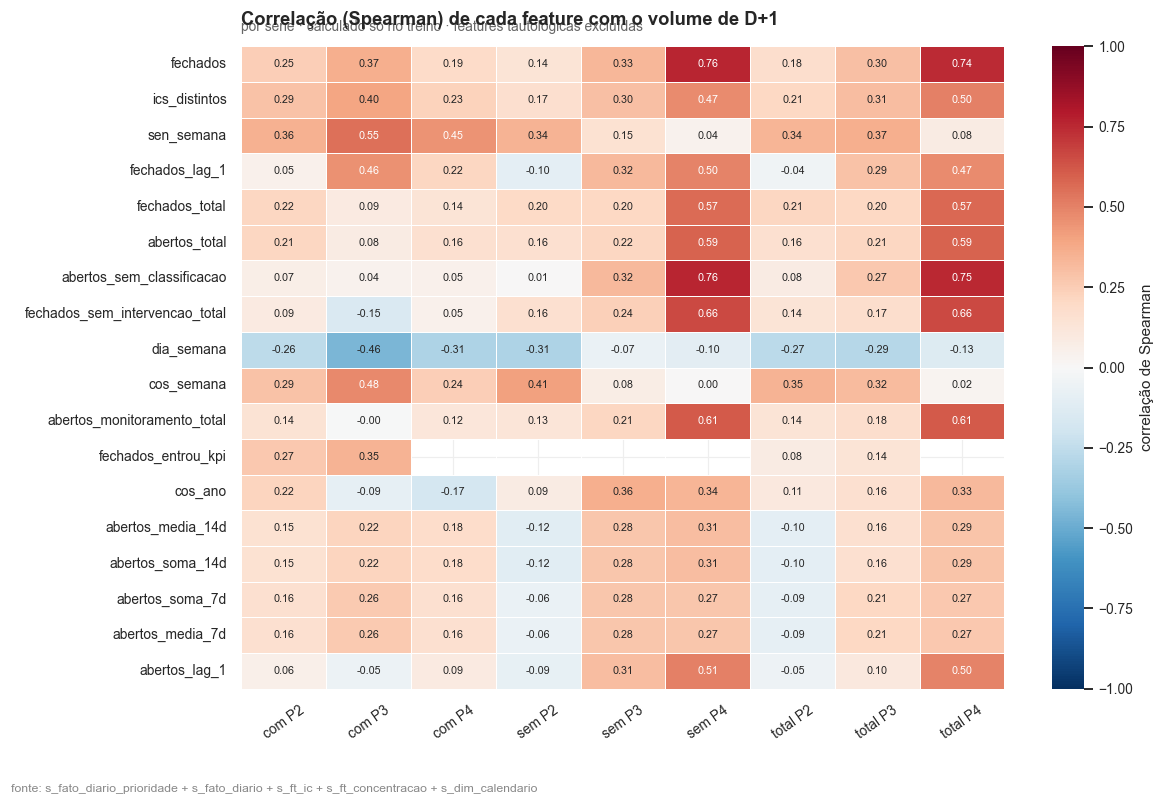

In [17]:
topo = ranking.head(18).feature.tolist()
matriz = (CORRELACOES[CORRELACOES.feature.isin(topo)]
          .assign(serie=lambda d: d.grupo.str.replace("_intervencao", "", regex=False)
                  + " P" + d.prioridade.astype(str))
          .pivot(index="feature", columns="serie", values="corr_amanha")
          .loc[topo])

fig, ax = novo_grafico(
    "Correlação (Spearman) de cada feature com o volume de D+1",
    "por série · calculado só no treino · features tautológicas excluídas",
    figsize=(11, 7),
)
sns.heatmap(matriz, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "correlação de Spearman"}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=35)
finalizar(fig, "fonte: s_fato_diario_prioridade + s_fato_diario + s_ft_ic + s_ft_concentracao + s_dim_calendario")

## 4.2 O efeito tautológico, explicitado

Para não deixar dúvida sobre por que as colunas marcadas foram excluídas do ranking: elas
correlacionam quase perfeitamente com o alvo **no mesmo dia** porque *são* o alvo, decomposto.

In [18]:
comparacao = (CORRELACOES
              .groupby("tautologica")
              .agg(features=("feature", "nunique"),
                   corr_hoje_media=("corr_hoje", lambda s: s.abs().mean()),
                   corr_amanha_media=("abs_amanha", "mean"))
              .reset_index()
              .assign(tipo=lambda d: np.where(d.tautologica, "decomposição do alvo", "demais features"))
              .drop(columns="tautologica"))
tabela(comparacao[["tipo", "features", "corr_hoje_media", "corr_amanha_media"]],
       "Correlação média — decomposições do alvo contra o resto", casas=3)

destaque = (CORRELACOES[CORRELACOES.tautologica]
            .groupby("feature")[["corr_hoje", "abs_amanha"]].mean().reset_index()
            .rename(columns={"abs_amanha": "corr_amanha_abs"}))
tabela(destaque, "As 4 colunas excluídas, uma a uma", casas=3)

**Correlação média — decomposições do alvo contra o resto**

| tipo                 |   features |   corr_hoje_media |   corr_amanha_media |
|:---------------------|-----------:|------------------:|--------------------:|
| demais features      |         82 |             0.258 |               0.158 |
| decomposição do alvo |          4 |             0.747 |               0.306 |

**As 4 colunas excluídas, uma a uma**

| feature                    |   corr_hoje |   corr_amanha_abs |
|:---------------------------|------------:|------------------:|
| abertos_fora_hor_comercial |       0.692 |             0.297 |
| abertos_hor_comercial      |       0.868 |             0.373 |
| abertos_manual             |       0.397 |             0.165 |
| abertos_monitoramento      |       0.945 |             0.358 |

## 4.3 Leitura da seção

In [19]:
from IPython.display import Markdown, display

top10 = ranking.head(10)
lags_no_top10 = [f for f in top10.feature if f.startswith("abertos_")]
melhor_lag = ranking[ranking.feature.str.startswith("abertos_")].iloc[0]
posicao_lag = int(ranking.index[ranking.feature == melhor_lag.feature][0]) + 1

texto = f"""
O ranking **não** é liderado pelo passado da própria série, que era o resultado esperado depois
de §3. As três primeiras colocadas são
{", ".join(f"`{f}` ({c:.2f})" for f, c in zip(top10.feature.head(3), top10.corr_media.head(3)))},
e a primeira feature de lag/janela móvel do alvo — `{melhor_lag.feature}` — aparece só na
**posição {posicao_lag}** ({melhor_lag.corr_media:.2f}).

Duas leituras possíveis, e a correlação par a par **não consegue escolher entre elas**:

1. essas features carregam informação genuína que o passado do alvo não tem; ou
2. elas são apenas **outra codificação do nível recente da série** — um dia com muitos incidentes
   abertos é um dia com muitos incidentes fechados, com mais ICs distintos acionados e com mais
   volume total na base. Nesse caso a correlação alta é reflexo, não sinal.

Distinguir as duas exige medir cada feature **na presença de todas as outras**, que é o que a
correlação par a par por construção não faz. É a próxima seção.
"""
display(Markdown(texto))


O ranking **não** é liderado pelo passado da própria série, que era o resultado esperado depois
de §3. As três primeiras colocadas são
`fechados` (0.36), `ics_distintos` (0.32), `sen_semana` (0.30),
e a primeira feature de lag/janela móvel do alvo — `abertos_total` — aparece só na
**posição 6** (0.27).

Duas leituras possíveis, e a correlação par a par **não consegue escolher entre elas**:

1. essas features carregam informação genuína que o passado do alvo não tem; ou
2. elas são apenas **outra codificação do nível recente da série** — um dia com muitos incidentes
   abertos é um dia com muitos incidentes fechados, com mais ICs distintos acionados e com mais
   volume total na base. Nesse caso a correlação alta é reflexo, não sinal.

Distinguir as duas exige medir cada feature **na presença de todas as outras**, que é o que a
correlação par a par por construção não faz. É a próxima seção.


---

# 5. Método embedded — o que explica o volume além da autocorrelação

Conforme pedido: um modelo de árvore com **todas as features disponíveis**, tendo `prioridade` e
`tipo_tratamento` como features, para mapear o que — além dos próprios lags — influencia a
quantidade de incidentes.

## 5.1 Por que árvore, e por que XGBoost

Um modelo embedded mede a importância **dentro** do ajuste, não antes dele: cada feature é
avaliada na presença de todas as outras, então a redundância que §4 não conseguia enxergar
aparece sozinha (features redundantes dividem o ganho e afundam no ranking). O XGBoost em
particular lida bem com o que este dado tem: escalas muito diferentes, não-linearidade,
interação (o efeito do dia da semana muda conforme o volume recente) e colunas correlacionadas
entre si.

## 5.2 Sobre "há uma forma melhor de avaliar as features?" — sim, três ressalvas

A pergunta do enunciado merece resposta direta. O ganho (`gain`) do XGBoost é a métrica de
importância mais usada e a **menos confiável** das três que este notebook calcula:

1. **Ganho é enviesado por cardinalidade.** Features contínuas com muitos valores distintos
   ganham mais oportunidades de corte do que uma binária como `feriado`, e por isso sobem no
   ranking mesmo sem carregar mais sinal. Por isso o ranking principal aqui é **permutation
   importance medida no conjunto de teste**, não o ganho do treino: ela responde "quanto o erro
   *out-of-sample* piora se eu embaralhar esta coluna", que é a pergunta que interessa.

2. **Importância dividida entre features correlacionadas.** `abertos_lag_1`, `abertos_media_7d` e
   `abertos_soma_7d` carregam quase a mesma informação; o modelo escolhe uma e as outras parecem
   inúteis. A leitura correta não é "as outras duas não importam", é "*esse bloco* importa".
   Por isso §5.5 reporta também a importância **agregada por família de feature**.

3. **Importância não é causalidade, e aqui há um risco concreto de vazamento conceitual.**
   Várias features de contexto (`ics_ativos`, `times_com_incidente`, `abertos_total`) são
   *medidas do mesmo dia* — em produção, no momento de prever D+1, o valor delas em D é
   conhecido, então usá-las é legítimo; mas para o D+7 elas teriam de ser previstas também.
   Isso está tratado explicitamente em §6.2.

**Alternativas que valeriam a pena num passo seguinte** (fora do escopo deste notebook, mas
respondendo à pergunta): *SHAP values* dariam o efeito de cada feature **por observação**, com
sinal e direção, em vez de um único número por coluna — e resolvem o problema (1) por
construção. E, para o objetivo declarado de "entender o componente estocástico", o teste
formal certo é a **causalidade de Granger** de cada candidata contra o resíduo do modelo
univariado: ela pergunta exatamente "esta série adiciona informação além do próprio passado do
alvo?", que é a pergunta de fundo.

In [20]:
def montar_dados_embedded(painel, colunas_feature):
    """Uma única matriz com as 9 séries empilhadas: features em D, alvo `abertos` em D+1.

    `prioridade` e `tipo_tratamento` entram como features, conforme pedido — é o que permite
    ao modelo dizer se elas importam mais ou menos do que as demais colunas.
    """
    quadros = []
    for g in GRUPOS:
        ini, fim = JANELA[g]["inicio"], JANELA[g]["fim"]
        sub = painel[(painel.tipo_tratamento == g) & (painel.data >= ini) & (painel.data <= fim)]
        quadros.append(sub)
    dados = pd.concat(quadros, ignore_index=True)
    dados = dados[dados.y_d1.notna()].copy()

    dados["p_prioridade"] = dados.prioridade.astype(int)
    dados["t_com_intervencao"] = (dados.tipo_tratamento == "com_intervencao").astype(int)
    dados["t_sem_intervencao"] = (dados.tipo_tratamento == "sem_intervencao").astype(int)
    dados["t_total"] = (dados.tipo_tratamento == "total").astype(int)

    features = (["p_prioridade", "t_com_intervencao", "t_sem_intervencao", "t_total"]
                + [c for c in colunas_feature if c not in TAUTOLOGICAS]
                + ["abertos"])
    features = list(dict.fromkeys(features))

    dados["em_teste"] = [d >= CORTE[g] for d, g in zip(dados.data, dados.tipo_tratamento)]
    return dados, features


DADOS_EMB, FEATURES_EMB = montar_dados_embedded(PAINEL, FEATURES_MODELO)
treino_emb = DADOS_EMB[~DADOS_EMB.em_teste]
teste_emb = DADOS_EMB[DADOS_EMB.em_teste]

print(f"treino {len(treino_emb):,} linhas · teste {len(teste_emb):,} linhas · {len(FEATURES_EMB)} features")
print(f"alvo: `abertos` em D+1 · feature `abertos` (dia D) incluída — é o lag 1, legítimo")

treino 1,680 linhas · teste 138 linhas · 93 features
alvo: `abertos` em D+1 · feature `abertos` (dia D) incluída — é o lag 1, legítimo


In [21]:
modelo_emb = xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, reg_lambda=2.0,
    objective="count:poisson",     # o alvo é contagem não-negativa
    random_state=SEMENTE, n_jobs=2,
)
modelo_emb.fit(treino_emb[FEATURES_EMB], treino_emb.y_d1, verbose=False)

previsto_emb = modelo_emb.predict(teste_emb[FEATURES_EMB])
mae_emb = np.abs(previsto_emb - teste_emb.y_d1).mean()
mae_ing = np.abs(teste_emb.abertos - teste_emb.y_d1).mean()
print(f"XGBoost  MAE no teste: {mae_emb:,.2f}")
print(f"Ingênuo  MAE no teste: {mae_ing:,.2f}")
print(f"O modelo existe aqui para MEDIR FEATURES, não para competir — a competição é §7.")

XGBoost  MAE no teste: 53.64
Ingênuo  MAE no teste: 43.28
O modelo existe aqui para MEDIR FEATURES, não para competir — a competição é §7.


## 5.3 Importância por permutação (no teste) — o ranking principal

In [22]:
perm = permutation_importance(
    modelo_emb, teste_emb[FEATURES_EMB], teste_emb.y_d1,
    n_repeats=15, random_state=SEMENTE, scoring="neg_mean_absolute_error",
    n_jobs=1,   # n_jobs>1 trava aqui: joblib/loky dentro de kernel Jupyter no Windows
)
ganhos = modelo_emb.get_booster().get_score(importance_type="gain")
importancia = pd.DataFrame({
    "feature": FEATURES_EMB,
    "perm_media": perm.importances_mean,
    "perm_dp": perm.importances_std,
})
importancia["ganho"] = importancia.feature.map(ganhos).fillna(0.0)
importancia["ganho_pct"] = importancia.ganho / importancia.ganho.sum() * 100
importancia = importancia.sort_values("perm_media", ascending=False).reset_index(drop=True)

tabela(importancia.head(20)[["feature", "perm_media", "perm_dp", "ganho_pct"]],
       "Top 20 — `perm_media` = piora do MAE no teste ao embaralhar a coluna", casas=3)

**Top 20 — `perm_media` = piora do MAE no teste ao embaralhar a coluna**

| feature                    |   perm_media |   perm_dp |   ganho_pct |
|:---------------------------|-------------:|----------:|------------:|
| fechados                   |       12.048 |     2.965 |      11.203 |
| abertos_sem_classificacao  |       10.219 |     3.022 |       8.374 |
| p_prioridade               |        7.708 |     3.327 |       1.014 |
| ics_distintos              |        4.098 |     1.873 |       6.449 |
| abertos                    |        3.829 |     1.607 |       4.559 |
| fechados_lag_1             |        3.514 |     2.132 |       5.425 |
| abertos_soma_7d            |        3.348 |     2.155 |      14.327 |
| t_com_intervencao          |        3.246 |     0.552 |       1.717 |
| abertos_soma_14d           |        2.982 |     1.295 |       9.694 |
| t_total                    |        2.419 |     0.972 |       0.367 |
| taxa_sem_intervencao_total |        1.215 |     0.583 |       0.286 |
| abertos_lag_7              |        0.744 |     0.295 |       0.216 |
| fechados_entrou_kpi        |        0.707 |     0.444 |       0.375 |
| abertos_media_14d          |        0.429 |     0.431 |       1.447 |
| backlog                    |        0.425 |     1.357 |       0.314 |
| duracao_mediana_h          |        0.424 |     0.792 |       0.686 |
| abertos_p5                 |        0.314 |     0.232 |       0.196 |
| times_distintos            |        0.286 |     0.132 |       0.085 |
| cos_semana                 |        0.27  |     0.19  |       0.721 |
| abertos_lag_1              |        0.263 |     0.814 |       0.323 |

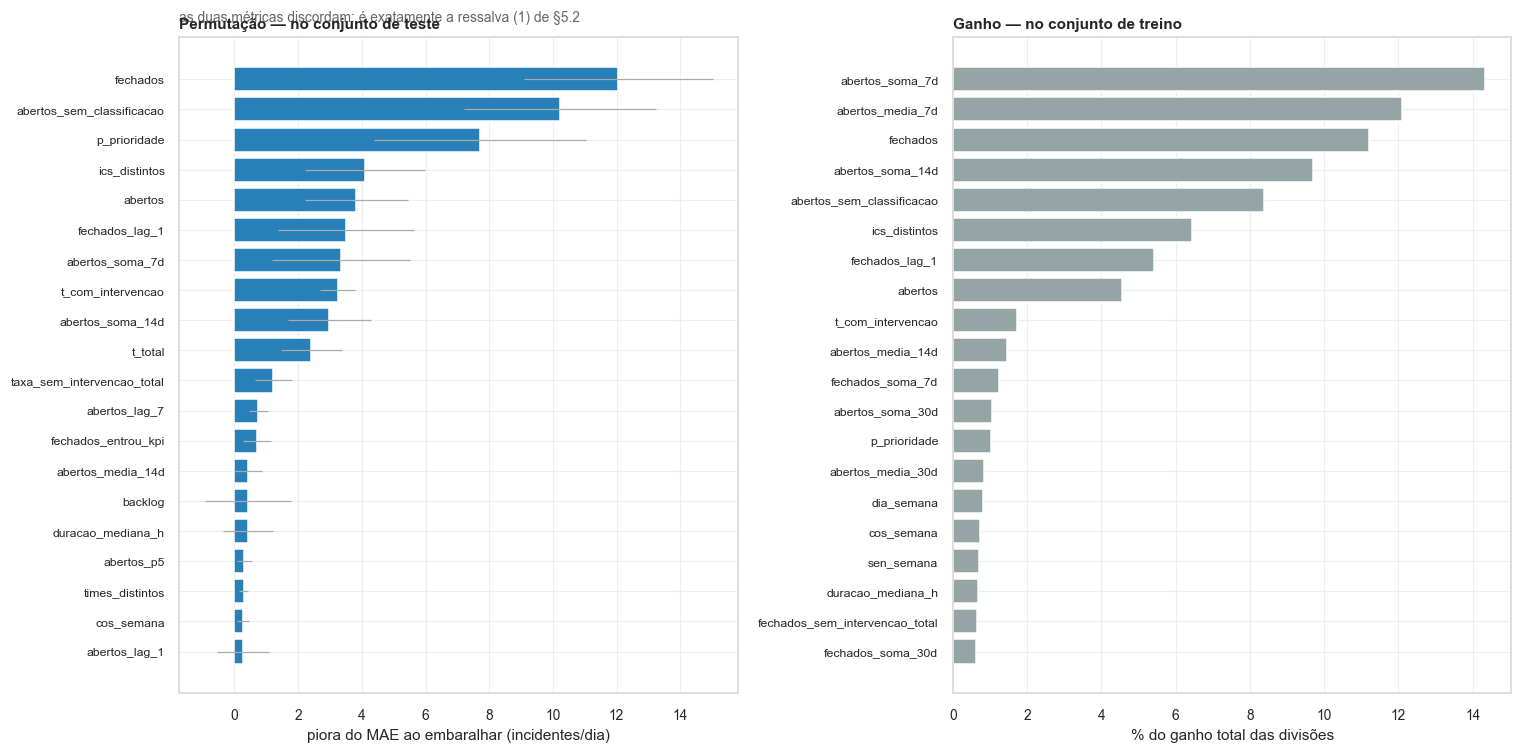

In [23]:
topo_imp = importancia.head(20).iloc[::-1]
fig, axes = novo_grafico(
    "Importância das features — permutação no teste × ganho no treino",
    "as duas métricas discordam: é exatamente a ressalva (1) de §5.2",
    figsize=(14, 7), ncols=2,
)
axes[0].barh(topo_imp.feature, topo_imp.perm_media, xerr=topo_imp.perm_dp,
             color=PALETA["destaque"], error_kw={"lw": 0.8, "ecolor": "#AAAAAA"})
axes[0].set_xlabel("piora do MAE ao embaralhar (incidentes/dia)")
axes[0].set_title("Permutação — no conjunto de teste", fontsize=10)

topo_ganho = importancia.sort_values("ganho_pct", ascending=False).head(20).iloc[::-1]
axes[1].barh(topo_ganho.feature, topo_ganho.ganho_pct, color=PALETA["neutro"])
axes[1].set_xlabel("% do ganho total das divisões")
axes[1].set_title("Ganho — no conjunto de treino", fontsize=10)
for ax in axes:
    ax.tick_params(axis="y", labelsize=8)
finalizar(fig)

## 5.4 Prioridade e tipo — as duas features que o enunciado pediu para posicionar

In [24]:
pedidas = ["p_prioridade", "t_com_intervencao", "t_sem_intervencao", "t_total"]
posicao = importancia.reset_index().rename(columns={"index": "posicao"})
posicao["posicao"] += 1
tabela(posicao[posicao.feature.isin(pedidas)][["posicao", "feature", "perm_media", "ganho_pct"]],
       f"Onde `prioridade` e `tipo_tratamento` caem no ranking de {len(FEATURES_EMB)} features", casas=3)

**Onde `prioridade` e `tipo_tratamento` caem no ranking de 93 features**

|   posicao | feature           |   perm_media |   ganho_pct |
|----------:|:------------------|-------------:|------------:|
|         3 | p_prioridade      |        7.708 |       1.014 |
|         8 | t_com_intervencao |        3.246 |       1.717 |
|        10 | t_total           |        2.419 |       0.367 |
|        72 | t_sem_intervencao |       -0.07  |       0.038 |

## 5.5 Importância agregada por família — a leitura que a redundância não distorce

Como avisado na ressalva (2), features correlacionadas entre si dividem a importância e afundam
individualmente. Agregando por família, a comparação passa a ser entre **blocos de informação**,
que é a pergunta real: *quanto o passado da própria série vale contra o contexto operacional,
contra o calendário, contra a identidade da série?*

In [ ]:
FAMILIA_TIME = "mix de times (share em janela)"
FAMILIA_CLASSE = "mix de classes de descrição (share em janela)"
FAMILIA_TEXTO = "raridade do texto (frequency encoding)"

PREFIXOS_TEXTO = ("freq_", "pct_template_novo", "templates_novos",
                  "entropia_templates_dia", "entropia_times_dia")


def familia(nome):
    """Rótulo de família de uma feature. A ordem dos testes importa.

    As três famílias novas são testadas **antes** dos prefixos genéricos: `entropia_times_dia_7d`
    começa com `entropia` e cairia em "concentração times/classes" se a checagem viesse depois,
    misturando a leitura por série (nova) com a leitura por dia (antiga) numa família só — que é
    exatamente a comparação que esta seção precisa fazer.
    """
    if nome in ("p_prioridade", "t_com_intervencao", "t_sem_intervencao", "t_total"):
        return "identidade da série (prioridade/tipo)"
    if nome in FEATURES_CALENDARIO:
        return "calendário"
    if nome.startswith(("mixtime_", "conctime_")):
        return FAMILIA_TIME
    if nome.startswith(("mixclasse_", "concclasse_")):
        return FAMILIA_CLASSE
    if nome.startswith(PREFIXOS_TEXTO):
        return FAMILIA_TEXTO
    if nome.startswith("inc_por_"):
        return "concentração do evento (razão)"
    if nome == "abertos" or nome.startswith("abertos_lag") or nome.startswith("abertos_media") \
            or nome.startswith("abertos_soma") or nome.startswith("abertos_ac"):
        return "passado do próprio alvo (autocorrelação)"
    if nome.startswith("fechados") or nome.startswith("kpi_violado") or nome in ("backlog", "saldo_aberto_fechado"):
        return "fluxo de fechamento / backlog"
    if nome.startswith("ics") or nome.startswith("pct_ics") or nome.startswith("volume_janela"):
        return "parque de ICs"
    if nome.startswith("hhi") or nome.startswith("share_") or nome.startswith("times") \
            or nome.startswith("entropia") or nome.startswith("classes"):
        return "concentração times/classes (grão dia)"
    if nome.startswith("duracao"):
        return "duração dos incidentes"
    return "contexto do dia (volume total da base)"


def janela_de(nome):
    """Sufixo de janela de uma feature nova: `lag1`, `7d`, `30d` ou `dia` (sem janela)."""
    for j in ("lag1", "7d", "30d"):
        if nome.endswith(f"_{j}"):
            return j
    return "dia"


importancia["familia"] = importancia.feature.map(familia)
por_familia = (importancia.groupby("familia")
               .agg(features=("feature", "size"),
                    perm_total=("perm_media", "sum"),
                    perm_maxima=("perm_media", "max"),
                    ganho_pct=("ganho_pct", "sum"))
               .sort_values("perm_total", ascending=False).reset_index())
por_familia["perm_pct"] = (por_familia.perm_total.clip(lower=0)
                           / por_familia.perm_total.clip(lower=0).sum() * 100)
tabela(por_familia[["familia", "features", "perm_total", "perm_pct", "ganho_pct"]],
       "Importância somada por família de feature", casas=2)

# Nenhuma feature pode ficar órfã de família: uma coluna que caísse no rótulo genérico passaria
# despercebida e a leitura por família ficaria errada sem sinal nenhum.
FAMILIAS_NOVAS = [FAMILIA_TIME, FAMILIA_CLASSE, FAMILIA_TEXTO]
_sem_familia = [c for c in FEATURES_NOVAS if familia(c) not in FAMILIAS_NOVAS]
assert not _sem_familia, f"features novas fora das famílias novas: {sorted(_sem_familia)}"
assert not (set(FEATURES_EMB) & set(FEATURES_NOVAS)), (
    "as features de time/classe/texto não entram no modelo desta seção — ver §5.7")
print(f"\nAs {len(FEATURES_NOVAS)} features de time responsável e descrição resumida ficam fora "
      f"deste ranking: têm seção própria, com ablação controlada, em §5.7.")


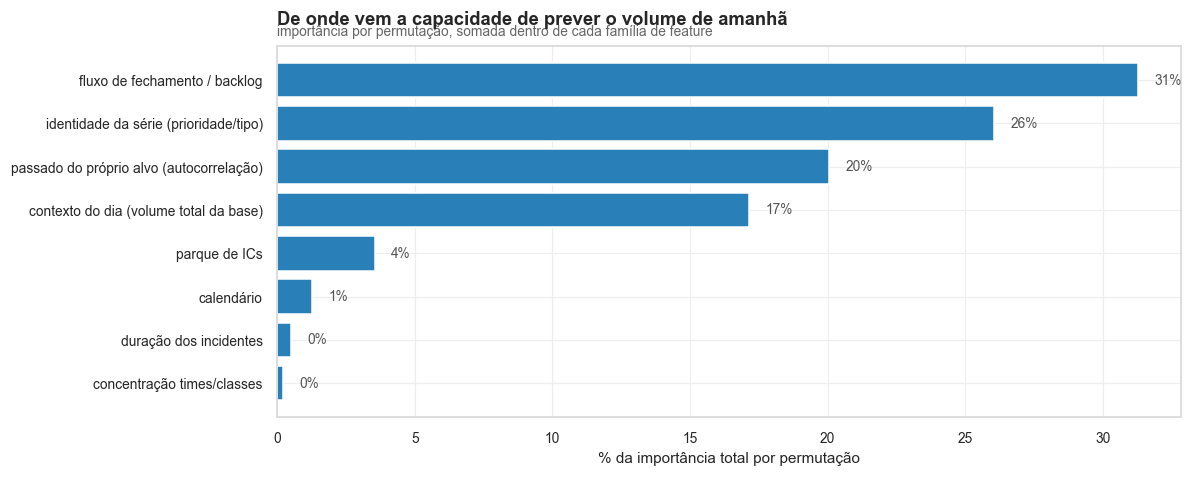

In [26]:
fam = por_familia.sort_values("perm_pct").query("perm_pct > 0")
fig, ax = novo_grafico(
    "De onde vem a capacidade de prever o volume de amanhã",
    "importância por permutação, somada dentro de cada família de feature",
    figsize=(11, 4.5),
)
ax.barh(fam.familia, fam.perm_pct, color=PALETA["destaque"])
for y, (v, t) in enumerate(zip(fam.perm_pct, fam.perm_total)):
    ax.text(v + 0.6, y, f"{v:.0f}%", va="center", fontsize=9, color="#555555")
ax.set_xlabel("% da importância total por permutação")
ax.set_ylabel("")
finalizar(fig)

## 5.6 Teste de ablação — a informação de fora é real ou é o nível disfarçado?

O ranking por família ainda deixa a dúvida de §4.3 em pé, agora com mais força: se as features
de fechamento e de contexto do dia forem apenas **outra codificação do nível recente da série**,
a importância alta delas é redundância, não informação nova.

Há um jeito direto de decidir isso, e ele é mais conclusivo do que qualquer ranking: **treinar de
novo sem elas** e ver quanto o erro out-of-sample piora. Se piorar pouco, elas eram substituíveis
pelo que já estava lá.

O corte não é arbitrário — é exatamente a fronteira que interessa ao resto do notebook: o modelo
restrito recebe só o que **sobrevive à recursão do D+7** (calendário + passado do próprio alvo +
identidade da série), que é o conjunto que §6.2 vai adotar.

In [ ]:
# O XGBoost tem duas fontes de aleatoriedade ligadas (`subsample=0.8`, `colsample_bytree=0.8`),
# e o teste tem 138 pontos. Nessa escala, o MAE de um único ajuste varia mais entre sementes do
# que entre conjuntos de features: medido, o desvio-padrão é ~2,5 MAE, quase 5% da média. Uma
# ablação de semente única aqui não mede a feature, mede a semente — então toda comparação desta
# seção roda em várias e reporta média e dispersão.
SEMENTES_ABLACAO = [42, 7, 13, 101, 2024, 555, 88, 314]


def mae_medio(colunas, sementes=SEMENTES_ABLACAO):
    """MAE de teste médio e desvio-padrão do XGBoost de §5.3 sobre um subconjunto de colunas."""
    erros = []
    for s in sementes:
        m = xgb.XGBRegressor(
            n_estimators=600, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=5, reg_lambda=2.0,
            objective="count:poisson", random_state=s, n_jobs=2,
        )
        m.fit(treino_emb[colunas], treino_emb.y_d1, verbose=False)
        erros.append(float(np.abs(m.predict(teste_emb[colunas]) - teste_emb.y_d1).mean()))
    return float(np.mean(erros)), float(np.std(erros, ddof=1))


FAMILIAS_RECURSIVAS = {
    "identidade da série (prioridade/tipo)",
    "calendário",
    "passado do próprio alvo (autocorrelação)",
}
FEATURES_RESTRITAS = [f for f in FEATURES_EMB if familia(f) in FAMILIAS_RECURSIVAS]
FEATURES_EXOGENAS = [f for f in FEATURES_EMB if f not in FEATURES_RESTRITAS]

mae_completo, dp_completo = mae_medio(FEATURES_EMB)
mae_restrito, dp_restrito = mae_medio(FEATURES_RESTRITAS)
mae_ingenuo_emb = float(np.abs(teste_emb.abertos - teste_emb.y_d1).mean())

ablacao = pd.DataFrame([
    {"modelo": f"completo ({len(FEATURES_EMB)} features)",
     "mae_teste": mae_completo, "dp_semente": dp_completo},
    {"modelo": f"restrito ao que sobrevive ao D+7 ({len(FEATURES_RESTRITAS)} features)",
     "mae_teste": mae_restrito, "dp_semente": dp_restrito},
    {"modelo": "baseline ingênuo", "mae_teste": mae_ingenuo_emb, "dp_semente": 0.0},
])
ablacao["vs_ingenuo_pct"] = (1 - ablacao.mae_teste / mae_ingenuo_emb) * 100
tabela(ablacao, "Ablação — o que se perde ao remover as "
                f"{len(FEATURES_EXOGENAS)} features exógenas "
                f"(média de {len(SEMENTES_ABLACAO)} sementes)", casas=2)

custo = (mae_restrito / mae_completo - 1) * 100
margem = (dp_completo + dp_restrito) / mae_completo * 100
print(f"custo de restringir ao conjunto recursivo: {custo:+.1f}% de MAE")
print(f"dispersão entre sementes: ±{dp_completo:.2f} e ±{dp_restrito:.2f} MAE "
      f"— diferenças menores que ~{margem:.0f}% não são distinguíveis de ruído")


## 5.7 As features de time responsável e descrição resumida valem a pena?

**Resposta curta: não o bastante para mudar nada.** O melhor recorte reduz o MAE deste modelo
diagnóstico, mas continua perdendo do baseline ingênuo, e nenhum dos 4 modelos de §7 pode usar
estas features — a recursão do D+7 (§6.2) só admite calendário e o passado da própria série. A
camada gold sai idêntica. O detalhe de como se chegou a isso está abaixo, porque o *caminho*
importa mais que o veredito: ele mostra onde ainda há sinal.

`Grupo designado` (17 times) e `Descrição Resumida` (13.317 templates → 11 classes) são duas
dimensões que a camada silver descreve em detalhe e que este notebook não carregava. A pergunta
é se codificá-las melhora a previsão.

### O que entra como feature, e o que não entra

A **contagem** de incidentes por time ou por classe não vira feature. As contagens dos buckets
somam exatamente `abertos` — são o alvo reescrito em outra base, e `abertos` já está no modelo
como lag 1. Elas existem só como matriz intermediária, e a verificação de que a soma reconstitui
`abertos` é o que prova que o pivot não perdeu nem duplicou incidente.

O que entra é sempre **proporção**, e medida em janela:

| Sufixo | O que mede |
|---|---|
| `_lag1` | a participação do bucket **ontem** |
| `_7d` | a participação na semana que fecha em D |
| `_30d` | a participação no mês que fecha em D |

A janela existe porque um share de um único dia é ruído onde o volume é baixo: em
`com_intervencao` P2 a média é ~5 incidentes/dia, então **um** incidente desloca a participação
de um time em 20 pontos percentuais. Todas as janelas fecham em D ou antes — nenhuma enxerga o
alvo, que está em D+1.

### Por que a ablação varre janelas, e não só famílias

São duas perguntas diferentes: *qual dimensão* carrega sinal, e *em que janela* ela deve ser
medida. Uma ablação que só testasse o pacote inteiro confundiria as duas — e daria um resultado
negativo que na verdade seria sobre o encoding, não sobre a dimensão.

Há também um limite duro de dimensionalidade: com 1.680 linhas de treino, cada bloco de colunas
novas custa variância. Por isso a tabela compara conjuntos **de mesmo tamanho** sempre que
possível (6 colunas de time em `lag1`, `7d` e `30d`), que é o único jeito de separar o efeito da
janela do efeito da contagem de colunas.


In [ ]:
NOVAS_NO_MODELO = [c for c in FEATURES_NOVAS if c in DADOS_EMB.columns]
mae_base, dp_base = mae_medio(FEATURES_EMB)

# Duas perguntas distintas, e por isso duas varreduras: *qual dimensão* carrega sinal, e *em que
# janela* ela deve ser medida. Testar só o pacote inteiro confunde as duas — daria um resultado
# negativo que na verdade seria sobre o encoding, não sobre a dimensão.
#
# A comparação decisiva é entre conjuntos do MESMO tamanho (as 6 colunas de time em `lag1`, `7d`
# e `30d`), que é o único jeito de separar o efeito da janela do efeito de ter mais colunas.
combos = {}
for f in sorted({familia(c) for c in NOVAS_NO_MODELO}):
    curto = f.split("(")[0].strip()
    for j in ("lag1", "7d", "30d", "dia"):
        cols = [c for c in NOVAS_NO_MODELO if familia(c) == f and janela_de(c) == j]
        if cols:
            combos[f"{curto} · {j}"] = cols
for j in ("lag1", "7d", "30d"):
    cols = [c for c in NOVAS_NO_MODELO if janela_de(c) == j]
    if cols:
        combos[f"todas as dimensões · {j}"] = cols
combos["todas as novas"] = NOVAS_NO_MODELO

linhas = [{"conjunto": f"só as {len(FEATURES_EMB)} do modelo", "novas": 0,
           "mae_teste": mae_base, "dp_semente": dp_base}]
for nome, cols in combos.items():
    m, dp = mae_medio(FEATURES_EMB + cols)
    linhas.append({"conjunto": f"+ {nome}", "novas": len(cols), "mae_teste": m, "dp_semente": dp})

ablacao_novas = pd.DataFrame(linhas)
ablacao_novas["vs_base_pct"] = (ablacao_novas.mae_teste / mae_base - 1) * 100
ablacao_novas["fora_do_ruido"] = (
    (ablacao_novas.mae_teste - mae_base).abs() > (ablacao_novas.dp_semente + dp_base)
)
tabela(ablacao_novas.sort_values("mae_teste"),
       f"Ablação por dimensão e janela — média de {len(SEMENTES_ABLACAO)} sementes", casas=2)

_melhor = ablacao_novas.sort_values("mae_teste").iloc[0]
# O melhor conjunto só conta como ganho se for melhor E estiver fora da faixa de ruído.
# `fora_do_ruido.any()` sozinho ficaria verdadeiro por causa dos conjuntos que pioram muito.
_algum = bool(_melhor.vs_base_pct < 0 and _melhor.fora_do_ruido)
print(f"melhor conjunto : {_melhor.conjunto} → MAE {_melhor.mae_teste:.2f} ± {_melhor.dp_semente:.2f} "
      f"({_melhor.vs_base_pct:+.1f}%)")
print(f"sem features novas: MAE {mae_base:.2f} ± {dp_base:.2f}")
print(f"baseline ingênuo  : MAE {mae_ingenuo_emb:.2f}")
print(f"\nalgum conjunto melhora além do ruído entre sementes? {'SIM' if _algum else 'NÃO'}")


In [ ]:
from IPython.display import Markdown, display

_ord = ablacao_novas.sort_values("mae_teste")
_melhor = _ord.iloc[0]
_pior = _ord.iloc[-1]
_uteis = ablacao_novas[ablacao_novas.fora_do_ruido & (ablacao_novas.vs_base_pct < 0)]
_ruido = (dp_base / mae_base) * 100

# O que uma ablação de semente única teria dito: o melhor conjunto na primeira semente da lista.
_semente_unica = {nome: mae_medio(FEATURES_EMB + cols, sementes=SEMENTES_ABLACAO[:1])[0]
                  for nome, cols in combos.items()}
_base_unica = mae_medio(FEATURES_EMB, sementes=SEMENTES_ABLACAO[:1])[0]
_campeao_falso = min(_semente_unica, key=_semente_unica.get)
_ganho_falso = (_semente_unica[_campeao_falso] / _base_unica - 1) * 100

linhas = ["### Veredito sobre time responsável e descrição resumida\n"]

linhas.append(
    "**1. Nenhuma configuração melhora o erro além do ruído.** "
    + (f"O melhor conjunto é `{_melhor.conjunto.lstrip('+ ')}`, com "
       f"**{_melhor.vs_base_pct:+.1f}%** de MAE — mas o desvio-padrão entre sementes do próprio "
       f"XGBoost é ±{dp_base:.2f} MAE (**{_ruido:.0f}%** da média), então a diferença não é "
       "distinguível de zero. "
       if _uteis.empty else
       f"Exceção: {', '.join('`' + c + '`' for c in _uteis.conjunto)}, que fica fora da faixa "
       "de ruído. ")
    + f"Testados {len(combos)} conjuntos — por dimensão, por janela e combinados.\n"
)

linhas.append(
    f"**2. É por isso que esta seção roda {len(SEMENTES_ABLACAO)} sementes e não uma.** Com uma "
    f"só, o campeão seria `{_campeao_falso}` com **{_ganho_falso:+.1f}%** — um resultado que "
    "some quando o experimento se repete. Com 1.680 linhas de treino e 138 pontos de teste, o "
    "MAE de um único ajuste varia mais entre sementes do que entre conjuntos de features. "
    "Qualquer leitura de semente única aqui mede a semente, não a feature.\n"
)

linhas.append(
    "**3. A janela não salvou o encoding.** A hipótese era que o share instantâneo de um dia "
    "fosse ruído — em `com_intervencao` P2, com ~5 incidentes/dia, um incidente desloca a "
    "participação de um time em 20 pontos — e que medir em `lag1`, `7d` ou `30d` revelasse o "
    "sinal. Comparando conjuntos do mesmo tamanho, nenhuma janela se sustenta acima do ruído. "
    "O problema não era o encoding.\n"
)

linhas.append(
    f"**4. E nada chega perto do piso.** O modelo desta seção está em {mae_base:.2f} contra "
    f"{mae_ingenuo_emb:.2f} do ingênuo. O teto diagnosticado em §5.6 continua de pé: a parcela "
    "estocástica do volume não está explicada por nada que esta base ofereça — nem pelo "
    "roteamento entre times, nem pelo tipo de alerta, nem pela novidade do texto.\n"
)

linhas.append(
    "**Decisão.** As 80 colunas ficam no painel de §4, onde descrevem a operação, e fora do "
    "modelo. Nenhum 5º candidato é aberto: mesmo o melhor recorte perde do ingênuo, e um modelo "
    "que perde do piso não muda decisão de negócio. **A camada gold não muda.** O que o "
    "resultado aponta não é mais feature engineering sobre a mesma base — é mais histórico. "
    "1.680 linhas de treino é o que limita tudo aqui, e é também o que faz cada tentativa de "
    "medir ganho pequeno esbarrar no próprio ruído do experimento.\n"
)

display(Markdown("\n".join(linhas)))


## 5.8 Leitura da seção

In [28]:
from IPython.display import Markdown, display

por_familia_idx = por_familia.set_index("familia")
lider = por_familia.iloc[0]
auto = por_familia[por_familia.familia.str.startswith("passado")].iloc[0]
top5 = importancia.head(5)
pos = posicao[posicao.feature.isin(pedidas)]
pos_prio = int(pos[pos.feature == "p_prioridade"].posicao.iloc[0])
custo_ablacao = (mae_restrito / mae_completo - 1) * 100

linhas = ["### O que o método embedded mostrou\n"]

linhas.append(
    f"**1. A autocorrelação não é a família dominante — e isso contraria o que §3 fazia esperar.** "
    f"A família com mais importância é **{lider.familia}** ({lider.perm_pct:.0f}%), enquanto o "
    f"passado do próprio alvo fica com **{auto.perm_pct:.0f}%**. As 5 features mais importantes "
    "são: " + ", ".join(f"`{f}`" for f in top5.feature) + ".\n"
)

linhas.append(
    f"**2. Mas o teste de ablação desmente a leitura ingênua desse ranking.** Remover as "
    f"{len(FEATURES_EXOGENAS)} features exógenas e deixar só as {len(FEATURES_RESTRITAS)} que "
    f"sobrevivem à recursão do D+7 muda o MAE de teste em **{custo_ablacao:+.1f}%** "
    f"({mae_completo:.2f} → {mae_restrito:.2f}). "
    + ("Ou seja: elas eram substituíveis pelo que já estava lá. Aparecem no topo do ranking "
       "porque **re-codificam o nível recente da série** — um dia com muitos incidentes abertos "
       "é um dia com muitos fechamentos, mais ICs distintos acionados e mais volume total na "
       "base. É a ressalva (2) de §5.2 acontecendo na prática, e é por isso que o ranking "
       "sozinho não bastava.\n"
       if custo_ablacao < 10 else
       "Ou seja: elas carregam informação que o passado do alvo não tem, e restringir o conjunto "
       "**custa acerto de verdade**. Isso não muda a regra de §6.2 — para o D+7 recursivo essas "
       "colunas continuam inutilizáveis, porque precisariam ser previstas — mas transforma o "
       "custo dessa restrição num número explícito em vez de uma suposição.\n")
)

linhas.append(
    f"**3. Prioridade e tipo.** `p_prioridade` aparece na **posição {pos_prio} de "
    f"{len(FEATURES_EMB)}** — alto, e o mais alto entre as 4 colunas de identidade. Faz sentido: "
    "com as 9 séries empilhadas numa matriz só, saber de qual prioridade a linha é dá acesso "
    "direto ao patamar de volume. As indicadoras de tipo ficam nas posições "
    + ", ".join(str(int(v)) for v in pos[pos.feature != "p_prioridade"].posicao)
    + ". Isso confirma que prioridade e tipo **particionam** o problema, mas **não** responde se "
    "vale a pena treinar modelos separados — um modelo só que recebe o rótulo como feature "
    "também usa essa informação. A pergunta certa é comparar previsão contra previsão, e é o "
    "que §10 faz.\n"
)

vs_ing_completo = (1 - mae_completo / mae_ingenuo_emb) * 100
linhas.append(
    f"**4. E o componente estocástico?** §3 mediu que o resíduo do STL é, em média, "
    f"{stl.residuo_sobre_media.mean() * 100:.0f}% da média do nível. O teste decisivo não é o "
    "ranking, é o placar contra o piso: mesmo o modelo **completo**, com as "
    f"{len(FEATURES_EMB)} features das 5 tabelas silver, "
    + (f"**perde para o baseline ingênuo** (MAE {mae_completo:.2f} contra "
       f"{mae_ingenuo_emb:.2f}, {vs_ing_completo:+.0f}%). "
       "Ou seja: as exógenas ajudam uma contra a outra, mas o conjunto todo ainda não chega ao "
       "que se consegue repetindo o valor de ontem. A parcela estocástica continua sem "
       "explicação dentro do que a base oferece hoje."
       if vs_ing_completo < 0 else
       f"**supera o baseline ingênuo** (MAE {mae_completo:.2f} contra {mae_ingenuo_emb:.2f}, "
       f"{vs_ing_completo:+.0f}%) — há sinal explorável além do passado da série.")
    + " Isso é um **resultado**, não uma falha do método. Se a informação que explicaria o "
    "resíduo existe, está numa granularidade que ainda não foi levada ao grão diário — estado "
    "dos ICs específicos que concentram volume, janelas de mudança/deploy, calendário de "
    "manutenção. É a recomendação concreta de próximo passo, e agora com evidência quantitativa "
    "por trás.\n"
)

linhas.append(
    f"**5. Consequência direta para §6.** O conjunto restrito custa {abs(custo_ablacao):.1f}% de "
    "MAE em relação ao completo. Como as exógenas não sobrevivem à recursão do D+7 de qualquer "
    "forma, os modelos de §7 usam calendário + passado do alvo — agora por uma decisão medida, "
    f"não por conveniência. E como esses {abs(custo_ablacao):.0f}% não seriam suficientes para "
    "virar o jogo contra o ingênuo, abrir mão deles não é o que decide o resultado de §8."
)

display(Markdown("\n".join(linhas)))

### O que o método embedded mostrou

**1. A autocorrelação não é a família dominante — e isso contraria o que §3 fazia esperar.** A família com mais importância é **fluxo de fechamento / backlog** (31%), enquanto o passado do próprio alvo fica com **20%**. As 5 features mais importantes são: `fechados`, `abertos_sem_classificacao`, `p_prioridade`, `ics_distintos`, `abertos`.

**2. Mas o teste de ablação desmente a leitura ingênua desse ranking.** Remover as 64 features exógenas e deixar só as 29 que sobrevivem à recursão do D+7 muda o MAE de teste em **+13.1%** (53.64 → 60.66). Ou seja: elas carregam informação que o passado do alvo não tem, e restringir o conjunto **custa acerto de verdade**. Isso não muda a regra de §6.2 — para o D+7 recursivo essas colunas continuam inutilizáveis, porque precisariam ser previstas — mas transforma o custo dessa restrição num número explícito em vez de uma suposição.

**3. Prioridade e tipo.** `p_prioridade` aparece na **posição 3 de 93** — alto, e o mais alto entre as 4 colunas de identidade. Faz sentido: com as 9 séries empilhadas numa matriz só, saber de qual prioridade a linha é dá acesso direto ao patamar de volume. As indicadoras de tipo ficam nas posições 8, 10, 72. Isso confirma que prioridade e tipo **particionam** o problema, mas **não** responde se vale a pena treinar modelos separados — um modelo só que recebe o rótulo como feature também usa essa informação. A pergunta certa é comparar previsão contra previsão, e é o que §10 faz.

**4. E o componente estocástico?** §3 mediu que o resíduo do STL é, em média, 58% da média do nível. O teste decisivo não é o ranking, é o placar contra o piso: mesmo o modelo **completo**, com as 93 features das 5 tabelas silver, **perde para o baseline ingênuo** (MAE 53.64 contra 43.28, -24%). Ou seja: as exógenas ajudam uma contra a outra, mas o conjunto todo ainda não chega ao que se consegue repetindo o valor de ontem. A parcela estocástica continua sem explicação dentro do que a base oferece hoje. Isso é um **resultado**, não uma falha do método. Se a informação que explicaria o resíduo existe, está numa granularidade que ainda não foi levada ao grão diário — estado dos ICs específicos que concentram volume, janelas de mudança/deploy, calendário de manutenção. É a recomendação concreta de próximo passo, e agora com evidência quantitativa por trás.

**5. Consequência direta para §6.** O conjunto restrito custa 13.1% de MAE em relação ao completo. Como as exógenas não sobrevivem à recursão do D+7 de qualquer forma, os modelos de §7 usam calendário + passado do alvo — agora por uma decisão medida, não por conveniência. E como esses 13% não seriam suficientes para virar o jogo contra o ingênuo, abrir mão deles não é o que decide o resultado de §8.

---

# 6. Desenho do treino

## 6.1 Os quatro modelos

| Modelo | O que é | Por que está aqui | Complexidade |
|---|---|---|---|
| **ARIMA** | Autorregressivo + média móvel sobre a série diferenciada. Prevê o próximo valor como combinação linear dos últimos valores e dos últimos erros. | É o piso estatístico da série univariada. §3 mostrou PACF cortando cedo — exatamente o regime em que ARIMA de ordem baixa costuma ser difícil de bater. | 1 (mais simples) |
| **SARIMA** | ARIMA + um bloco autorregressivo/média-móvel que se repete a cada 7 dias, mais feriados como variável exógena. | §3 mostrou picos de ACF em 7/14 em parte das séries. O SARIMA testa se esse sinal semanal paga o custo dos parâmetros extras. | 2 |
| **Prophet** | Modelo aditivo de curva: tendência por partes + sazonalidade em série de Fourier + efeito de feriados. Não é autorregressivo — ajusta uma curva ao longo do tempo. | Trata feriado nativamente e é robusto a série curta e a buraco. É o único candidato que modela o efeito de calendário de forma explícita e interpretável. | 3 |
| **LSTM** | Rede recorrente com portas de memória. Lê uma janela dos últimos 14 dias e aprende a relação não-linear entre esse trecho e o dia seguinte. | É o candidato flexível: captura interação e não-linearidade que os três anteriores não modelam. Também o mais faminto por dado — com 108 dias de treino em `sem_intervencao`, é onde ele mais sofre. | 4 (mais complexo) |

Mais um, que **não é candidato**:

| **Ingênuo** | A previsão de amanhã é o valor de hoje. | É o **piso de referência**, não um competidor. §3 já avisou: numa série cujo resíduo é a maior componente, repetir o último valor é um adversário duro. Ele fica fora da escolha de §9 — mas se o vencedor perder para ele, isso é registrado com destaque. | — |

## 6.2 O que cada modelo recebe de entrada

Existe uma restrição que determina tudo aqui: **o D+7 é gerado recursivamente pelo mesmo modelo
de D+1** (§6.3). Para prever D+2 o modelo precisa das features de D+1 — que ainda não
aconteceu. Isso deixa exatamente duas origens de feature admissíveis:

1. **Calendário** — conhecido para qualquer data futura, hoje e sempre;
2. **Passado do próprio alvo** — recalculável a cada passo da cadeia, trocando o valor real pela
   previsão.

Nenhuma feature exógena passa por esse filtro: `ics_ativos` ou `fechados` em D+3 precisariam ser
previstos também, e o erro dessa previsão entraria no modelo como se fosse dado.

O custo dessa restrição **não é assumido, é o número medido pela ablação de §5.6** — lá o
conjunto restrito foi comparado com o completo no mesmo teste. Vale registrar o que essa regra
deixa na mesa: para um horizonte **só de D+1**, as exógenas seriam admissíveis (o valor delas em
D é conhecido quando se prevê D+1), e um modelo dedicado a D+1 poderia usá-las. Este notebook
mantém um único modelo servindo os dois horizontes, que é a decisão mais simples; separar em
"modelo de D+1 com exógenas" e "modelo de D+7 sem" fica registrado como alternativa.

| Modelo | Entrada |
|---|---|
| **ARIMA** | Só o histórico de `abertos`. Nenhuma exógena, nenhum calendário. |
| **SARIMA** | Histórico de `abertos` + estrutura sazonal de período 7 + `feriado`, `vespera_feriado`, `pos_feriado` como exógenas. |
| **Prophet** | Data (`ds`) e valor (`y`); sazonalidade semanal automática; tabela de feriados do calendário do projeto; `vespera_feriado` e `pos_feriado` como regressores extras. |
| **LSTM** | Janela dos últimos 14 dias, cada dia com `log1p(abertos)` padronizado + as 11 features de calendário daquele dia; e mais o vetor de calendário **do dia que está sendo previsto**, concatenado antes da camada densa. |
| **Ingênuo** | `abertos` do dia de origem. |

## 6.3 Como o mesmo modelo de D+1 produz o D+7

**D+1** — para cada dia de origem `D` do teste, o modelo prevê `D+1` tendo visto o dado **real**
até `D`. Isso é legítimo e é o que acontece em produção: ao prever amanhã, o valor de hoje já é
conhecido. Todos os modelos operam assim; muda só o mecanismo (ARIMA/SARIMA refiltram o estado
com os parâmetros fixos, o Prophet reajusta, o LSTM desliza a janela de entrada).

**D+7** — a partir da mesma origem `D`, a cadeia anda 7 passos **sem espiar nenhum valor real
intermediário**: prevê `D+1`; para prever `D+2`, o lugar do valor real de `D+1` é ocupado pela
**previsão** de `D+1`; e assim por diante. O calendário nunca precisa de substituição.

O número reportado como D+7 é o **acumulado dos 7 dias** (`D+1 + D+2 + … + D+7`) — responde a
"quanto volume vem nesta semana", não "qual o valor exato do sétimo dia". Ele é comparado com a
soma real do mesmo intervalo.

Cada dia de origem com 7 dias reais à frente gera um ponto de D+7, então sai uma **série** de
previsões acumuladas ao longo do teste, não um número único.

In [29]:
def indices_origem(grupo, prioridade, passos=1):
    """Índices (na série completa) dos dias de origem cujas previsões caem no teste.

    D+1: origem D tal que D+1 está no teste  ->  uma previsão por dia de teste.
    D+7: origem D tal que D+1 está no teste E D+7 ainda tem valor real para comparar.
    """
    s = SERIES[(grupo, prioridade)]
    corte = CORTE[grupo]
    n = len(s)
    origens = []
    for i in range(n):
        alvo_inicial = i + 1
        alvo_final = i + passos
        if alvo_final >= n:
            continue
        if s.data.iloc[alvo_inicial] < corte:
            continue
        origens.append(i)
    return origens


def passos_disponiveis(grupo, prioridade, indice, passos=PASSO_MAXIMO):
    """Quantos passos a cadeia consegue andar sem passar do fim da série.

    A última origem do teste só tem 1 dia à frente: ela rende um ponto de D+1 e nenhum de
    D+7. Truncar aqui é o que evita o caminho pedir calendário de uma data que não existe.
    """
    return min(passos, len(SERIES[(grupo, prioridade)]) - 1 - indice)


contagem = pd.DataFrame([
    {"grupo": g, "prioridade": p,
     "origens_d1": len(indices_origem(g, p, 1)),
     "origens_d7": len(indices_origem(g, p, PASSO_MAXIMO))}
    for g in GRUPOS for p in PRIORIDADES
])
tabela(contagem, "Pontos de avaliação por série — D+7 perde 6 origens no fim (falta real para comparar)")

**Pontos de avaliação por série — D+7 perde 6 origens no fim (falta real para comparar)**

| grupo           |   prioridade |   origens_d1 |   origens_d7 |
|:----------------|-------------:|-------------:|-------------:|
| com_intervencao |            2 |           21 |           15 |
| com_intervencao |            3 |           21 |           15 |
| com_intervencao |            4 |           21 |           15 |
| sem_intervencao |            2 |           14 |            8 |
| sem_intervencao |            3 |           14 |            8 |
| sem_intervencao |            4 |           14 |            8 |
| total           |            2 |           14 |            8 |
| total           |            3 |           14 |            8 |
| total           |            4 |           14 |            8 |

In [30]:
def alvos_reais(grupo, prioridade, passos):
    """Para cada origem elegível: data de origem, data-alvo e o valor real do horizonte."""
    s = SERIES[(grupo, prioridade)]
    origens = indices_origem(grupo, prioridade, passos)
    linhas = []
    for i in origens:
        janela = s.abertos.iloc[i + 1: i + 1 + passos]
        linhas.append({
            "indice_origem": i,
            "data_origem": s.data.iloc[i],
            "data_alvo": s.data.iloc[i + passos],
            "real": float(janela.sum()),
        })
    return pd.DataFrame(linhas)


def metricas(real, previsto):
    """MAE, RMSE e MAPE. MAPE com piso 1 no denominador — a série tem dias de valor 0."""
    real = np.asarray(real, dtype=float)
    previsto = np.asarray(previsto, dtype=float)
    erro = previsto - real
    return {
        "mae": float(np.abs(erro).mean()),
        "rmse": float(np.sqrt((erro ** 2).mean())),
        "mape": float((np.abs(erro) / np.maximum(np.abs(real), 1)).mean() * 100),
    }

---

# 7. Treino e previsão

Cada modelo expõe a mesma interface: recebe uma série e devolve, para cada origem elegível, o
**caminho de 7 passos** a partir daquela origem. D+1 é o primeiro passo do caminho; D+7 é a soma
dos sete. Fazer os dois horizontes saírem do mesmo objeto garante que eles não possam divergir
por acidente de implementação.

## 7.1 Baseline ingênuo

In [31]:
def caminhos_ingenuo(grupo, prioridade, passos=PASSO_MAXIMO):
    """Repete o valor da origem por todos os passos — a definição do ingênuo aplicada em cadeia."""
    s = SERIES[(grupo, prioridade)]
    return {i: np.full(passos_disponiveis(grupo, prioridade, i, passos), float(s.abertos.iloc[i]))
            for i in indices_origem(grupo, prioridade, 1)}

## 7.2 ARIMA e SARIMA

A ordem não é escolhida à mão: uma busca em grade minimiza o **AIC** dentro do treino. O AIC
penaliza parâmetro, o que é a proteção certa aqui — nas séries de 122 dias, um modelo grande
ajustaria ruído.

O grau de diferenciação `d` vem do teste **ADF** de estacionariedade, também só no treino.

Depois de escolhida a ordem, o modelo é ajustado **uma única vez**. Para andar pelo teste, os
parâmetros ficam **congelados** e apenas o filtro de estado é reaplicado sobre o histórico real
até cada origem (`.filter(params)`). É isso que dá o "modelo fixo, dado real até D" de §6.3, sem
reajustar 21 vezes e sem deixar o modelo aprender com o teste.

In [32]:
EXOG_SARIMA = ["feriado", "vespera_feriado", "pos_feriado"]


def grau_diferenciacao(y, alfa=0.05):
    """0 se o ADF rejeita raiz unitária (série já estacionária), 1 caso contrário."""
    try:
        p_valor = adfuller(np.asarray(y, dtype=float), autolag="AIC")[1]
    except Exception:
        return 1
    return 0 if p_valor < alfa else 1


def exog_utilizavel(s, colunas):
    """Descarta coluna exógena constante na janela — geraria matriz singular."""
    if not colunas:
        return None
    usaveis = [c for c in colunas if s[c].nunique() > 1]
    return s[usaveis].astype(float) if usaveis else None


def buscar_ordem(y, exog, sazonal, d, s_periodo=PERIODO_SAZONAL):
    """Grade pequena sobre (p,q) — e (P,Q) quando sazonal — minimizando AIC."""
    melhor = None
    faixa_p = range(0, 4) if not sazonal else range(0, 3)
    faixa_q = range(0, 4) if not sazonal else range(0, 3)
    combos_sazonais = [(P, 0, Q, s_periodo) for P in (0, 1) for Q in (0, 1)] if sazonal else [(0, 0, 0, 0)]

    for p in faixa_p:
        for q in faixa_q:
            if p == 0 and q == 0:
                continue
            for sz in combos_sazonais:
                try:
                    mod = SARIMAX(y, exog=exog, order=(p, d, q), seasonal_order=sz,
                                  trend="c" if d == 0 else "n",
                                  enforce_stationarity=False, enforce_invertibility=False)
                    res = mod.fit(disp=False, maxiter=80)
                    aic = res.aic
                    if not np.isfinite(aic):
                        continue
                    if melhor is None or aic < melhor["aic"]:
                        melhor = {"order": (p, d, q), "seasonal_order": sz,
                                  "aic": float(aic), "params": res.params}
                except Exception:
                    continue

    if melhor is None:      # rede de segurança: AR(1) puro
        mod = SARIMAX(y, exog=exog, order=(1, d, 0), seasonal_order=(0, 0, 0, 0),
                      trend="c" if d == 0 else "n",
                      enforce_stationarity=False, enforce_invertibility=False)
        res = mod.fit(disp=False)
        melhor = {"order": (1, d, 0), "seasonal_order": (0, 0, 0, 0),
                  "aic": float(res.aic), "params": res.params}
    return melhor

In [33]:
def ajustar_statsmodels(grupo, prioridade, sazonal):
    """Escolhe a ordem no treino e devolve a especificação com os parâmetros congelados."""
    s = SERIES[(grupo, prioridade)]
    treino = SPLIT[(grupo, prioridade)]["treino"]
    y = treino.abertos.astype(float).values

    colunas_exog = EXOG_SARIMA if sazonal else []
    usaveis = [c for c in colunas_exog if treino[c].nunique() > 1]
    exog_treino = treino[usaveis].astype(float).values if usaveis else None

    d = grau_diferenciacao(y)
    escolha = buscar_ordem(y, exog_treino, sazonal, d)
    escolha["exog"] = usaveis
    escolha["d_adf"] = d
    return escolha


def caminhos_statsmodels(grupo, prioridade, spec, passos=PASSO_MAXIMO):
    """Parâmetros fixos; o estado é refiltrado com o dado real até cada origem."""
    s = SERIES[(grupo, prioridade)]
    y_total = s.abertos.astype(float).values
    exog_total = s[spec["exog"]].astype(float).values if spec["exog"] else None
    d = spec["order"][1]

    caminhos = {}
    for i in indices_origem(grupo, prioridade, 1):
        n_passos = passos_disponiveis(grupo, prioridade, i, passos)
        historico = y_total[: i + 1]
        exog_hist = exog_total[: i + 1] if exog_total is not None else None
        exog_fut = exog_total[i + 1: i + 1 + n_passos] if exog_total is not None else None
        try:
            mod = SARIMAX(historico, exog=exog_hist,
                          order=spec["order"], seasonal_order=spec["seasonal_order"],
                          trend="c" if d == 0 else "n",
                          enforce_stationarity=False, enforce_invertibility=False)
            previsao = mod.filter(spec["params"]).forecast(steps=n_passos, exog=exog_fut)
            caminho = np.asarray(previsao, dtype=float)
        except Exception:
            caminho = np.full(n_passos, historico[-1])
        caminhos[i] = np.clip(np.nan_to_num(caminho, nan=historico[-1]), 0, None)
    return caminhos

## 7.3 Prophet

O Prophet **não é autorregressivo**: ele ajusta uma curva no tempo, não uma função dos últimos
valores. Consequência prática — não existe um "estado" para atualizar com o dado real de ontem,
como no SARIMA. Para que a comparação seja justa, e não uma extrapolação de 3 semanas contra
modelos que enxergam o dia anterior, o Prophet é **reajustado em cada origem**, sobre todo o
histórico real disponível até ali. É mais caro, e é o que torna a comparação honesta.

A tabela de feriados vem do calendário do próprio projeto, não do `holidays` genérico do país —
é o mesmo calendário que alimenta as features dos outros modelos.

In [34]:
FERIADOS_PROPHET = (calendario.loc[calendario.feriado == 1, ["data", "nome_feriado"]]
                    .rename(columns={"data": "ds", "nome_feriado": "holiday"}))
FERIADOS_PROPHET["holiday"] = FERIADOS_PROPHET.holiday.fillna("feriado")
FERIADOS_PROPHET["lower_window"] = 0
FERIADOS_PROPHET["upper_window"] = 0
REGRESSORES_PROPHET = ["vespera_feriado", "pos_feriado"]

print(f"{len(FERIADOS_PROPHET)} feriados na tabela do Prophet "
      f"({FERIADOS_PROPHET.ds.min():%Y-%m-%d} a {FERIADOS_PROPHET.ds.max():%Y-%m-%d})")

47 feriados na tabela do Prophet (2023-01-25 a 2025-12-25)


In [35]:
def caminhos_prophet(grupo, prioridade, passos=PASSO_MAXIMO):
    """Reajusta o Prophet a cada origem sobre o histórico real e projeta os 7 dias seguintes."""
    s = SERIES[(grupo, prioridade)]
    caminhos = {}
    for i in indices_origem(grupo, prioridade, 1):
        n_passos = passos_disponiveis(grupo, prioridade, i, passos)
        historico = s.iloc[: i + 1]
        treino = pd.DataFrame({"ds": historico.data.values, "y": historico.abertos.astype(float).values})
        for r in REGRESSORES_PROPHET:
            treino[r] = historico[r].astype(float).values

        modelo = Prophet(
            growth="flat",                     # §3: tendência fraca — trend flexível só captaria ruído
            weekly_seasonality=True,
            yearly_seasonality=False,          # nem 1 ciclo anual completo no treino
            daily_seasonality=False,
            holidays=FERIADOS_PROPHET,
            seasonality_mode="additive",
            changepoint_prior_scale=0.05,
        )
        for r in REGRESSORES_PROPHET:
            modelo.add_regressor(r)

        try:
            modelo.fit(treino)
            futuro_idx = s.iloc[i + 1: i + 1 + n_passos]
            futuro = pd.DataFrame({"ds": futuro_idx.data.values})
            for r in REGRESSORES_PROPHET:
                futuro[r] = futuro_idx[r].astype(float).values
            caminho = modelo.predict(futuro)["yhat"].values.astype(float)
        except Exception:
            caminho = np.full(n_passos, float(s.abertos.iloc[i]))
        caminhos[i] = np.clip(np.nan_to_num(caminho, nan=float(s.abertos.iloc[i])), 0, None)
    return caminhos

## 7.4 LSTM

A rede lê uma janela de **14 dias**; cada dia da janela entra como `log1p(abertos)` padronizado
mais as 11 features de calendário daquele dia. O último estado oculto é concatenado com o vetor
de calendário **do dia que está sendo previsto** — assim a rede sabe que amanhã é feriado antes
de prever — e uma camada densa produz o valor.

Três escolhas que existem por causa do tamanho do dado (108 a 344 dias de treino):

- **`log1p` + padronização**: o alvo varia de 0 a 942 entre séries e tem picos fortes; sem isso o
  gradiente é dominado pelos outliers.
- **Rede pequena** (1 camada, 32 unidades) e **parada antecipada** sobre os últimos 15% do
  treino: é o que evita decorar 108 dias.
- **Uma rede por série**, com o seu próprio escalonamento — as escalas não são comparáveis.

Na recursão do D+7, o valor previsto volta para a janela de entrada no lugar do real, e o
calendário avança normalmente.

In [36]:
JANELA_LSTM = 14
UNIDADES_LSTM = 32
EPOCAS_LSTM = 1500
PACIENCIA_LSTM = 100


class RedeLSTM(nn.Module):
    """LSTM sobre a janela + calendário do dia-alvo concatenado antes da saída."""

    def __init__(self, n_features, n_calendario, unidades=UNIDADES_LSTM):
        super().__init__()
        self.lstm = nn.LSTM(n_features, unidades, batch_first=True)
        self.saida = nn.Sequential(
            nn.Linear(unidades + n_calendario, unidades),
            nn.ReLU(),
            nn.Linear(unidades, 1),
        )

    def forward(self, sequencia, calendario_alvo):
        _, (oculto, _) = self.lstm(sequencia)
        return self.saida(torch.cat([oculto[-1], calendario_alvo], dim=1)).squeeze(-1)


def preparar_lstm(grupo, prioridade):
    """Escalonadores ajustados SÓ no treino e as matrizes da série inteira já transformadas."""
    s = SERIES[(grupo, prioridade)]
    n_treino = len(SPLIT[(grupo, prioridade)]["treino"])

    y_log = np.log1p(s.abertos.astype(float).values)
    esc_y = StandardScaler().fit(y_log[:n_treino].reshape(-1, 1))
    y_esc = esc_y.transform(y_log.reshape(-1, 1)).ravel()

    cal = s[FEATURES_CALENDARIO].astype(float).values
    esc_cal = StandardScaler().fit(cal[:n_treino])
    cal_esc = esc_cal.transform(cal)

    return {"y_esc": y_esc, "cal_esc": cal_esc, "esc_y": esc_y, "n_treino": n_treino}


def montar_janelas(dados, ate_indice):
    """Todas as amostras (janela -> dia seguinte) cujo alvo cai antes de `ate_indice`."""
    sequencias, calendarios, alvos = [], [], []
    for alvo in range(JANELA_LSTM, ate_indice):
        inicio = alvo - JANELA_LSTM
        sequencia = np.column_stack([dados["y_esc"][inicio:alvo], dados["cal_esc"][inicio:alvo]])
        sequencias.append(sequencia)
        calendarios.append(dados["cal_esc"][alvo])
        alvos.append(dados["y_esc"][alvo])
    return (torch.tensor(np.array(sequencias), dtype=torch.float32),
            torch.tensor(np.array(calendarios), dtype=torch.float32),
            torch.tensor(np.array(alvos), dtype=torch.float32))

In [37]:
def treinar_lstm(grupo, prioridade, semente=SEMENTE):
    """Treina uma rede na fatia de treino, com parada antecipada nos últimos 15% dela."""
    torch.manual_seed(semente)
    np.random.seed(semente)

    dados = preparar_lstm(grupo, prioridade)
    seq, cal, alvo = montar_janelas(dados, dados["n_treino"])

    n_val = max(7, int(len(alvo) * 0.15))
    seq_tr, cal_tr, alvo_tr = seq[:-n_val], cal[:-n_val], alvo[:-n_val]
    seq_val, cal_val, alvo_val = seq[-n_val:], cal[-n_val:], alvo[-n_val:]

    rede = RedeLSTM(seq.shape[2], cal.shape[1])
    otimizador = torch.optim.Adam(rede.parameters(), lr=0.01, weight_decay=1e-4)
    perda_fn = nn.MSELoss()

    melhor_perda, melhor_estado, sem_melhora = np.inf, None, 0
    for _ in range(EPOCAS_LSTM):
        rede.train()
        otimizador.zero_grad()
        perda_fn(rede(seq_tr, cal_tr), alvo_tr).backward()
        torch.nn.utils.clip_grad_norm_(rede.parameters(), 1.0)
        otimizador.step()

        rede.eval()
        with torch.no_grad():
            perda_val = float(perda_fn(rede(seq_val, cal_val), alvo_val))
        if perda_val < melhor_perda - 1e-5:
            melhor_perda, sem_melhora = perda_val, 0
            melhor_estado = {k: v.clone() for k, v in rede.state_dict().items()}
        else:
            sem_melhora += 1
            if sem_melhora >= PACIENCIA_LSTM:
                break

    if melhor_estado is not None:
        rede.load_state_dict(melhor_estado)
    rede.eval()
    return rede, dados, melhor_perda


def caminhos_lstm(grupo, prioridade, rede, dados, passos=PASSO_MAXIMO):
    """Rollout recursivo: a previsão de cada passo volta para a janela de entrada."""
    esc_y, y_esc, cal_esc = dados["esc_y"], dados["y_esc"], dados["cal_esc"]
    caminhos = {}
    for i in indices_origem(grupo, prioridade, 1):
        n_passos = passos_disponiveis(grupo, prioridade, i, passos)
        janela = list(y_esc[i + 1 - JANELA_LSTM: i + 1])
        caminho = []
        for passo in range(n_passos):
            alvo_idx = i + 1 + passo
            sequencia = np.column_stack([
                np.array(janela),
                cal_esc[alvo_idx - JANELA_LSTM: alvo_idx],
            ])
            with torch.no_grad():
                previsto_esc = float(rede(
                    torch.tensor(sequencia[None, :, :], dtype=torch.float32),
                    torch.tensor(cal_esc[alvo_idx][None, :], dtype=torch.float32),
                ))
            caminho.append(previsto_esc)
            janela = janela[1:] + [previsto_esc]   # realimenta a previsão, não o real

        valores = esc_y.inverse_transform(np.array(caminho).reshape(-1, 1)).ravel()
        caminhos[i] = np.clip(np.expm1(valores), 0, None)
    return caminhos

## 7.5 Execução

Uma passada por série. Os caminhos de 7 passos de cada modelo ficam guardados em `CAMINHOS`;
D+1 e D+7 são derivados dele em §7.6, o que garante que os dois horizontes venham do mesmo
objeto.

In [38]:
import time

# A busca em grade tenta ordens que não convergem — é o esperado numa grade, e o AIC já
# descarta essas. O aviso por tentativa tornaria a saída ilegível.
warnings.simplefilter("ignore")

CAMINHOS = {}
ESPECIFICACOES = {}
inicio = time.time()

for g in GRUPOS:
    for p in PRIORIDADES:
        marca = time.time()

        spec_arima = ajustar_statsmodels(g, p, sazonal=False)
        spec_sarima = ajustar_statsmodels(g, p, sazonal=True)
        ESPECIFICACOES[(g, p, "ARIMA")] = spec_arima
        ESPECIFICACOES[(g, p, "SARIMA")] = spec_sarima

        rede, dados_rede, perda_val = treinar_lstm(g, p)
        ESPECIFICACOES[(g, p, "LSTM")] = {"perda_validacao": perda_val}

        CAMINHOS[(g, p, "Ingênuo")] = caminhos_ingenuo(g, p)
        CAMINHOS[(g, p, "ARIMA")] = caminhos_statsmodels(g, p, spec_arima)
        CAMINHOS[(g, p, "SARIMA")] = caminhos_statsmodels(g, p, spec_sarima)
        CAMINHOS[(g, p, "Prophet")] = caminhos_prophet(g, p)
        CAMINHOS[(g, p, "LSTM")] = caminhos_lstm(g, p, rede, dados_rede)

        print(f"  {g:<16} P{p}  "
              f"ARIMA{spec_arima['order']}  "
              f"SARIMA{spec_sarima['order']}x{spec_sarima['seasonal_order']}  "
              f"({time.time() - marca:5.1f}s)")

print(f"\ntotal: {time.time() - inicio:.1f}s")

  com_intervencao  P2  ARIMA(0, 0, 3)  SARIMA(2, 0, 2)x(0, 0, 1, 7)  ( 19.6s)


  com_intervencao  P3  ARIMA(2, 0, 3)  SARIMA(2, 0, 0)x(1, 0, 1, 7)  ( 24.7s)


  com_intervencao  P4  ARIMA(2, 0, 3)  SARIMA(0, 0, 2)x(1, 0, 1, 7)  ( 22.3s)


  sem_intervencao  P2  ARIMA(0, 0, 3)  SARIMA(0, 0, 2)x(0, 0, 1, 7)  (  8.8s)


  sem_intervencao  P3  ARIMA(0, 0, 3)  SARIMA(2, 0, 2)x(1, 0, 1, 7)  ( 10.2s)


  sem_intervencao  P4  ARIMA(3, 0, 2)  SARIMA(1, 0, 1)x(0, 0, 1, 7)  ( 11.8s)


  total            P2  ARIMA(0, 0, 3)  SARIMA(0, 0, 2)x(0, 0, 1, 7)  ( 10.6s)


  total            P3  ARIMA(0, 0, 3)  SARIMA(0, 0, 2)x(1, 0, 1, 7)  ( 10.8s)


  total            P4  ARIMA(3, 0, 2)  SARIMA(0, 0, 2)x(0, 0, 1, 7)  ( 11.8s)

total: 130.5s


In [39]:
ordens = pd.DataFrame([
    {"grupo": g, "prioridade": p,
     "d_adf": ESPECIFICACOES[(g, p, "ARIMA")]["d_adf"],
     "arima": str(ESPECIFICACOES[(g, p, "ARIMA")]["order"]),
     "arima_aic": ESPECIFICACOES[(g, p, "ARIMA")]["aic"],
     "sarima": f"{ESPECIFICACOES[(g, p, 'SARIMA')]['order']}x{ESPECIFICACOES[(g, p, 'SARIMA')]['seasonal_order']}",
     "sarima_aic": ESPECIFICACOES[(g, p, "SARIMA")]["aic"],
     "lstm_perda_val": ESPECIFICACOES[(g, p, "LSTM")]["perda_validacao"]}
    for g in GRUPOS for p in PRIORIDADES
])
ordens["sarima_melhor_aic"] = ordens.sarima_aic < ordens.arima_aic
tabela(ordens, "Ordens escolhidas por AIC no treino (`d` vem do ADF)", casas=2)

**Ordens escolhidas por AIC no treino (`d` vem do ADF)**

| grupo           |   prioridade |   d_adf | arima     |   arima_aic | sarima                 |   sarima_aic |   lstm_perda_val | sarima_melhor_aic   |
|:----------------|-------------:|--------:|:----------|------------:|:-----------------------|-------------:|-----------------:|:--------------------|
| com_intervencao |            2 |       0 | (0, 0, 3) |     3277.24 | (2, 0, 2)x(0, 0, 1, 7) |      3225.58 |             1.14 | True                |
| com_intervencao |            3 |       0 | (2, 0, 3) |     3163.73 | (2, 0, 0)x(1, 0, 1, 7) |      2984.21 |             0.36 | True                |
| com_intervencao |            4 |       0 | (2, 0, 3) |     2563.37 | (0, 0, 2)x(1, 0, 1, 7) |      2518.73 |             0.48 | True                |
| sem_intervencao |            2 |       0 | (0, 0, 3) |     1187.75 | (0, 0, 2)x(0, 0, 1, 7) |      1130.56 |             0.29 | True                |
| sem_intervencao |            3 |       0 | (0, 0, 3) |     1211.88 | (2, 0, 2)x(1, 0, 1, 7) |      1130.58 |             0.51 | True                |
| sem_intervencao |            4 |       0 | (3, 0, 2) |     1183.62 | (1, 0, 1)x(0, 0, 1, 7) |      1111.21 |             0.34 | True                |
| total           |            2 |       0 | (0, 0, 3) |     1226.42 | (0, 0, 2)x(0, 0, 1, 7) |      1166.89 |             0.43 | True                |
| total           |            3 |       0 | (0, 0, 3) |     1243.49 | (0, 0, 2)x(1, 0, 1, 7) |      1155.48 |             0.42 | True                |
| total           |            4 |       0 | (3, 0, 2) |     1193.13 | (0, 0, 2)x(0, 0, 1, 7) |      1111.16 |             0.35 | True                |

## 7.6 Derivação dos dois horizontes

D+1 = primeiro passo do caminho. D+7 = soma dos sete. A mesma origem alimenta os dois.

In [40]:
MODELOS = ["ARIMA", "SARIMA", "Prophet", "LSTM"]
TODOS = MODELOS + ["Ingênuo"]

registros = []
for g in GRUPOS:
    for p in PRIORIDADES:
        s = SERIES[(g, p)]
        for modelo in TODOS:
            caminhos = CAMINHOS[(g, p, modelo)]

            for _, linha in alvos_reais(g, p, 1).iterrows():
                i = int(linha.indice_origem)
                registros.append({
                    "grupo": g, "prioridade": p, "modelo": modelo, "horizonte": "D+1",
                    "data_origem": linha.data_origem, "data_alvo": linha.data_alvo,
                    "previsto": float(caminhos[i][0]), "real": linha.real,
                })

            for _, linha in alvos_reais(g, p, PASSO_MAXIMO).iterrows():
                i = int(linha.indice_origem)
                registros.append({
                    "grupo": g, "prioridade": p, "modelo": modelo, "horizonte": "D+7",
                    "data_origem": linha.data_origem, "data_alvo": linha.data_alvo,
                    "previsto": float(np.sum(caminhos[i][:PASSO_MAXIMO])), "real": linha.real,
                })

PREVISOES = pd.DataFrame(registros)
PREVISOES["erro"] = PREVISOES.previsto - PREVISOES.real
print(f"{len(PREVISOES):,} previsões · "
      f"{PREVISOES.modelo.nunique()} modelos x {PREVISOES.horizonte.nunique()} horizontes x 9 séries")

conferencia = (PREVISOES.groupby(["grupo", "horizonte"])
               .agg(origens=("data_origem", "nunique"), linhas=("previsto", "size"))
               .reset_index())
tabela(conferencia, "Conferência de cobertura")

1,200 previsões · 5 modelos x 2 horizontes x 9 séries


**Conferência de cobertura**

| grupo           | horizonte   |   origens |   linhas |
|:----------------|:------------|----------:|---------:|
| com_intervencao | D+1         |        21 |      315 |
| com_intervencao | D+7         |        15 |      225 |
| sem_intervencao | D+1         |        14 |      210 |
| sem_intervencao | D+7         |         8 |      120 |
| total           | D+1         |        14 |      210 |
| total           | D+7         |         8 |      120 |

In [41]:
# O D+7 real tem de bater com y_abertos_acum_1a7 da silver — conferência independente.
conf = (PREVISOES[(PREVISOES.horizonte == "D+7") & (PREVISOES.modelo == "ARIMA")
                  & (PREVISOES.grupo != "total")]
        [["grupo", "prioridade", "data_origem", "real"]]
        .merge(fato[["data", "prioridade", "tipo_tratamento", "y_abertos_acum_1a7"]],
               left_on=["data_origem", "prioridade", "grupo"],
               right_on=["data", "prioridade", "tipo_tratamento"], how="left"))
divergencia = (conf.real - conf.y_abertos_acum_1a7).abs().max()
print(f"maior divergência entre o D+7 real deste notebook e `y_abertos_acum_1a7` da silver: {divergencia:.6f}")
assert divergencia < 1e-6, "D+7 real não bate com a silver"
print("OK — o acumulado de 7 dias construído aqui é idêntico ao alvo já validado na exploração.")

maior divergência entre o D+7 real deste notebook e `y_abertos_acum_1a7` da silver: 0.000000
OK — o acumulado de 7 dias construído aqui é idêntico ao alvo já validado na exploração.


---

# 8. Avaliação de resultados

Duas leituras, sempre as duas:

- **por prioridade** — P2, P3 e P4 avaliadas separadamente dentro de cada grupo, para os dois
  horizontes. É a visão pedida no enunciado ("as 2 visões para cada prioridade × tipo");
- **geral** (`prioridade = todas`) — as 3 prioridades juntas dentro do grupo. É a leitura que
  decide o vencedor em §9, porque a entrega é a volumetria do grupo, não de uma prioridade
  isolada.

**MAE é a métrica de decisão** — está na unidade do problema (incidentes/dia em D+1,
incidentes/semana em D+7) e não é dominada por um outlier como o RMSE.

Como o nível das séries varia de 23 a 480 incidentes/dia (§3), o MAE **não é comparável entre
séries** — só dentro da mesma. Para essa comparação entram duas métricas relativas, e a escolha
entre elas não é indiferente:

- **MAPE** — erro percentual. É a métrica que todo mundo conhece, e aqui ela **quebra**:
  `com_intervencao` P4 tem dias com 0 e 1 incidente, e dividir por um número perto de zero
  produz percentuais de centenas por cento que não significam nada. Fica na tabela por ser
  esperada, com esta ressalva.
- **MASE** (*mean absolute scaled error*) — o MAE dividido pelo erro que a **mesma regra
  ingênua** cometeria dentro do treino. É imune ao problema do denominador zero e tem leitura
  direta: **MASE < 1 = erra menos que o ingênuo cometia no treino**; MASE = 2 = erra o dobro.
  É a métrica relativa que este notebook usa de fato.

Uma observação sobre o MASE e o ingênuo do teste: eles medem coisas próximas, mas não idênticas
— o MASE compara com o ingênuo **no treino** (referência estável, independente do período), e a
coluna `ganho_vs_ingenuo` compara com o ingênuo **no teste** (mesmas datas, comparação direta).
Divergência entre os dois é informação: significa que o período de teste foi mais fácil ou mais
difícil que o treino para uma previsão ingênua.

In [42]:
def calcular_metricas(previsoes):
    """Métricas por (grupo, prioridade, horizonte, modelo) e a leitura geral `todas`."""
    linhas = []
    for (g, p, h, m), sub in previsoes.groupby(["grupo", "prioridade", "horizonte", "modelo"]):
        linhas.append({"grupo": g, "prioridade": str(p), "horizonte": h, "modelo": m,
                       "n": len(sub), **metricas(sub.real, sub.previsto)})
    for (g, h, m), sub in previsoes.groupby(["grupo", "horizonte", "modelo"]):
        linhas.append({"grupo": g, "prioridade": "todas", "horizonte": h, "modelo": m,
                       "n": len(sub), **metricas(sub.real, sub.previsto)})
    return pd.DataFrame(linhas)


METRICAS = calcular_metricas(PREVISOES)


def escala_mase(grupo, prioridade, horizonte):
    """Erro médio da previsão ingênua DENTRO DO TREINO — o denominador do MASE.

    O denominador usa **exatamente a mesma regra ingênua** que é avaliada no teste, senão
    a leitura "MASE < 1 = melhor que o ingênuo" não vale:
      D+1 -> prever y[i+1] com y[i];
      D+7 -> prever a soma de y[i+1..i+7] com 7 x y[i].
    Usar o treino (e não o teste) é o que mantém a métrica independente do período avaliado.
    """
    treino = SPLIT[(grupo, prioridade)]["treino"].abertos.astype(float).values
    n = len(treino)
    if horizonte == "D+1":
        erros = np.abs(treino[1:] - treino[:-1])
    else:
        somas = np.convolve(treino, np.ones(PASSO_MAXIMO), mode="valid")  # somas[j] = y[j..j+6]
        origens = np.arange(0, n - PASSO_MAXIMO)
        erros = np.abs(somas[origens + 1] - PASSO_MAXIMO * treino[origens])
    return float(erros.mean()) if len(erros) else np.nan


ESCALA = {(g, p, h): escala_mase(g, p, h)
          for g in GRUPOS for p in PRIORIDADES for h in ["D+1", "D+7"]}

METRICAS["escala_mase"] = [
    ESCALA[(g, int(p), h)] if p != "todas" else np.nan
    for g, p, h in zip(METRICAS.grupo, METRICAS.prioridade, METRICAS.horizonte)
]
METRICAS["mase"] = METRICAS.mae / METRICAS.escala_mase

# Na leitura geral o MASE é a média dos MASE das 3 prioridades — somar erros de escalas
# diferentes num denominador só não teria significado.
media_por_serie = (METRICAS[METRICAS.prioridade != "todas"]
                   .groupby(["grupo", "horizonte", "modelo"]).mase.mean())
mascara = METRICAS.prioridade == "todas"
METRICAS.loc[mascara, "mase"] = [
    media_por_serie.get((g, h, m), np.nan)
    for g, h, m in zip(METRICAS.loc[mascara, "grupo"], METRICAS.loc[mascara, "horizonte"],
                       METRICAS.loc[mascara, "modelo"])
]

# ganho contra o piso ingênuo, medido exatamente nas mesmas datas
piso = (METRICAS[METRICAS.modelo == "Ingênuo"]
        .rename(columns={"mae": "mae_ingenuo"})[["grupo", "prioridade", "horizonte", "mae_ingenuo"]])
METRICAS = METRICAS.merge(piso, on=["grupo", "prioridade", "horizonte"], how="left")
METRICAS["ganho_vs_ingenuo"] = (1 - METRICAS.mae / METRICAS.mae_ingenuo) * 100
METRICAS["supera_ingenuo"] = METRICAS.mae < METRICAS.mae_ingenuo

COMPLEXIDADE = {"ARIMA": 1, "SARIMA": 2, "Prophet": 3, "LSTM": 4, "Ingênuo": 0}
METRICAS["complexidade"] = METRICAS.modelo.map(COMPLEXIDADE)

print(f"{len(METRICAS)} linhas de métrica "
      f"(3 grupos x 4 níveis de prioridade x 2 horizontes x 5 modelos)")

120 linhas de métrica (3 grupos x 4 níveis de prioridade x 2 horizontes x 5 modelos)


## 8.1 Leitura geral — a que decide o vencedor

In [43]:
for h in ["D+1", "D+7"]:
    visao = (METRICAS[(METRICAS.prioridade == "todas") & (METRICAS.horizonte == h)]
             .pivot(index="grupo", columns="modelo", values="mae")
             .reindex(columns=TODOS).reindex(GRUPOS).reset_index())
    tabela(visao, f"MAE — leitura geral, {h} "
                  f"({'incidentes/dia' if h == 'D+1' else 'incidentes/semana acumulados'})")

**MAE — leitura geral, D+1 (incidentes/dia)**

| grupo           |   ARIMA |   SARIMA |   Prophet |   LSTM |   Ingênuo |
|:----------------|--------:|---------:|----------:|-------:|----------:|
| com_intervencao |   20.23 |    16.27 |     21.73 |  16.19 |     13.49 |
| sem_intervencao |  117.1  |   102.74 |    140.44 | 138.73 |     65.02 |
| total           |  114.09 |   109.66 |    136.78 | 134.45 |     68.52 |

**MAE — leitura geral, D+7 (incidentes/semana acumulados)**

| grupo           |   ARIMA |   SARIMA |   Prophet |    LSTM |   Ingênuo |
|:----------------|--------:|---------:|----------:|--------:|----------:|
| com_intervencao |  116.24 |    94.44 |    118.38 |   86.52 |    100.33 |
| sem_intervencao |  867.98 |   786.19 |    881.44 | 1081.57 |    635.04 |
| total           |  855.78 |   886.91 |    862.78 | 1025.36 |    662.58 |

In [44]:
geral = (METRICAS[METRICAS.prioridade == "todas"]
         .sort_values(["horizonte", "grupo", "mae"])
         [["horizonte", "grupo", "modelo", "mae", "rmse", "mase", "mape", "mae_ingenuo",
           "ganho_vs_ingenuo", "supera_ingenuo"]])
tabela(geral, "Leitura geral completa — ordenada por erro dentro de cada grupo/horizonte")

**Leitura geral completa — ordenada por erro dentro de cada grupo/horizonte**

| horizonte   | grupo           | modelo   |     mae |    rmse |   mase |   mape |   mae_ingenuo |   ganho_vs_ingenuo | supera_ingenuo   |
|:------------|:----------------|:---------|--------:|--------:|-------:|-------:|--------------:|-------------------:|:-----------------|
| D+1         | com_intervencao | Ingênuo  |   13.49 |   24.52 |   0.77 |  83.9  |         13.49 |               0    | False            |
| D+1         | com_intervencao | LSTM     |   16.19 |   25.74 |   0.92 | 367.32 |         13.49 |             -19.96 | False            |
| D+1         | com_intervencao | SARIMA   |   16.27 |   22.77 |   0.99 | 360.85 |         13.49 |             -20.57 | False            |
| D+1         | com_intervencao | ARIMA    |   20.23 |   27.25 |   1.13 | 413.6  |         13.49 |             -49.92 | False            |
| D+1         | com_intervencao | Prophet  |   21.73 |   30.5  |   1.2  | 458.58 |         13.49 |             -61.08 | False            |
| D+1         | sem_intervencao | Ingênuo  |   65.02 |   79.93 |   1.21 |  54.35 |         65.02 |               0    | False            |
| D+1         | sem_intervencao | SARIMA   |  102.74 |  142.53 |   1.88 |  83.79 |         65.02 |             -58    | False            |
| D+1         | sem_intervencao | ARIMA    |  117.1  |  164.91 |   2.14 |  87.99 |         65.02 |             -80.08 | False            |
| D+1         | sem_intervencao | LSTM     |  138.73 |  181.07 |   2.52 |  74.82 |         65.02 |            -113.35 | False            |
| D+1         | sem_intervencao | Prophet  |  140.44 |  191.76 |   2.56 | 119.39 |         65.02 |            -115.99 | False            |
| D+1         | total           | Ingênuo  |   68.52 |   83.59 |   1.09 |  38.61 |         68.52 |               0    | False            |
| D+1         | total           | SARIMA   |  109.66 |  148.62 |   1.66 |  64.8  |         68.52 |             -60.03 | False            |
| D+1         | total           | ARIMA    |  114.09 |  151.83 |   1.73 |  65.52 |         68.52 |             -66.5  | False            |
| D+1         | total           | LSTM     |  134.45 |  173.62 |   2.1  |  57.97 |         68.52 |             -96.21 | False            |
| D+1         | total           | Prophet  |  136.78 |  178.46 |   2.09 |  76.93 |         68.52 |             -99.62 | False            |
| D+7         | com_intervencao | LSTM     |   86.52 |  118.93 |   0.7  | 103.81 |        100.33 |              13.76 | True             |
| D+7         | com_intervencao | SARIMA   |   94.44 |  109.78 |   0.87 | 124.25 |        100.33 |               5.88 | True             |
| D+7         | com_intervencao | Ingênuo  |  100.33 |  156.41 |   0.91 |  91.98 |        100.33 |               0    | False            |
| D+7         | com_intervencao | ARIMA    |  116.24 |  147.21 |   0.96 | 136.21 |        100.33 |             -15.85 | False            |
| D+7         | com_intervencao | Prophet  |  118.38 |  147.88 |   0.97 | 136.06 |        100.33 |             -17.99 | False            |
| D+7         | sem_intervencao | Ingênuo  |  635.04 |  784.03 |   1.73 |  50.02 |        635.04 |               0    | False            |
| D+7         | sem_intervencao | SARIMA   |  786.19 | 1168.17 |   2.31 |  36.25 |        635.04 |             -23.8  | False            |
| D+7         | sem_intervencao | ARIMA    |  867.98 | 1301.7  |   2.56 |  39.19 |        635.04 |             -36.68 | False            |
| D+7         | sem_intervencao | Prophet  |  881.44 | 1345.44 |   2.62 |  40.67 |        635.04 |             -38.8  | False            |
| D+7         | sem_intervencao | LSTM     | 1081.57 | 1336.11 |   2.92 |  44.81 |        635.04 |             -70.31 | False            |
| D+7         | total           | Ingênuo  |  662.58 |  806.69 |   1.48 |  42.78 |        662.58 |               0    | False            |
| D+7         | total           | ARIMA    |  855.78 | 1192.11 |   1.99 |  43.72 |        662.58 |             -29.16 | False            |
| D+7         | total           | Prophet  |  862.78 | 1234.95 |   2.01 |  43.73 |        662.58 |             -30.21 | False            |
| D+7         | total           | SARIMA   |  886.91 | 1265.39 |   2.06 |  45.03 |        662.58 |             -33.86 | False            |
| D+7         | total           | LSTM     | 1025.36 | 1283.75 |   2.29 |  40.16 |        662.58 |             -54.75 | False            |

## 8.2 Leitura por prioridade × tipo — as duas visões pedidas

In [45]:
for h in ["D+1", "D+7"]:
    visao = (METRICAS[(METRICAS.prioridade != "todas") & (METRICAS.horizonte == h)]
             .assign(serie=lambda d: d.grupo + " · P" + d.prioridade)
             .pivot(index="serie", columns="modelo", values="mae")
             .reindex(columns=TODOS).reset_index())
    tabela(visao, f"MAE por prioridade × tipo — {h}")

**MAE por prioridade × tipo — D+1**

| serie                |   ARIMA |   SARIMA |   Prophet |   LSTM |   Ingênuo |
|:---------------------|--------:|---------:|----------:|-------:|----------:|
| com_intervencao · P2 |   16.27 |    16.01 |     16.24 |  12.73 |     20.9  |
| com_intervencao · P3 |   31.43 |    19.71 |     35.09 |  24.8  |     12.9  |
| com_intervencao · P4 |   12.97 |    13.09 |     13.87 |  11.03 |      6.67 |
| sem_intervencao · P2 |   30.11 |    28.46 |     35.76 |  25.72 |     37.29 |
| sem_intervencao · P3 |  259    |   216.72 |    300.5  | 234.8  |     79.36 |
| sem_intervencao · P4 |   62.17 |    63.05 |     85.08 | 155.66 |     78.43 |
| total · P2           |   45.23 |    43.39 |     44.57 |  32.86 |     41.93 |
| total · P3           |  232.75 |   227.02 |    268.39 | 226.23 |     83.21 |
| total · P4           |   64.31 |    58.56 |     97.4  | 144.26 |     80.43 |

**MAE por prioridade × tipo — D+7**

| serie                |   ARIMA |   SARIMA |   Prophet |    LSTM |   Ingênuo |
|:---------------------|--------:|---------:|----------:|--------:|----------:|
| com_intervencao · P2 |   72.91 |    73.41 |     72.92 |   59.73 |    118.47 |
| com_intervencao · P3 |  211.55 |   137.7  |    217.75 |  156.3  |    120.07 |
| com_intervencao · P4 |   64.25 |    72.2  |     64.48 |   43.55 |     62.47 |
| sem_intervencao · P2 |   70.23 |    71.01 |     76.24 |   90.65 |    245.88 |
| sem_intervencao · P3 | 2221.26 |  1973.95 |   2299.45 | 1912.07 |    892.12 |
| sem_intervencao · P4 |  312.45 |   313.6  |    268.64 | 1241.98 |    767.12 |
| total · P2           |  188.78 |   187.11 |    181.17 |   78.45 |    271.25 |
| total · P3           | 2005.61 |  2144.52 |   2081.95 | 1866.83 |    894.5  |
| total · P4           |  372.96 |   329.09 |    325.22 | 1130.81 |    822    |

In [46]:
for h in ["D+1", "D+7"]:
    visao = (METRICAS[(METRICAS.prioridade != "todas") & (METRICAS.horizonte == h)]
             .assign(serie=lambda d: d.grupo + " · P" + d.prioridade)
             .pivot(index="serie", columns="modelo", values="mase")
             .reindex(columns=TODOS).reset_index())
    tabela(visao, f"MASE por prioridade × tipo — {h} · **< 1 = erra menos que o ingênuo do treino**",
           casas=3)

**MASE por prioridade × tipo — D+1 · **< 1 = erra menos que o ingênuo do treino****

| serie                |   ARIMA |   SARIMA |   Prophet |   LSTM |   Ingênuo |
|:---------------------|--------:|---------:|----------:|-------:|----------:|
| com_intervencao · P2 |   0.907 |    0.892 |     0.905 |  0.709 |     1.165 |
| com_intervencao · P3 |   1.132 |    0.709 |     1.263 |  0.893 |     0.465 |
| com_intervencao · P4 |   1.35  |    1.362 |     1.443 |  1.148 |     0.694 |
| sem_intervencao · P2 |   0.633 |    0.598 |     0.751 |  0.54  |     0.783 |
| sem_intervencao · P3 |   4.658 |    3.897 |     5.404 |  4.223 |     1.427 |
| sem_intervencao · P4 |   1.121 |    1.136 |     1.534 |  2.806 |     1.414 |
| total · P2           |   0.712 |    0.683 |     0.701 |  0.517 |     0.66  |
| total · P3           |   3.345 |    3.262 |     3.857 |  3.251 |     1.196 |
| total · P4           |   1.125 |    1.024 |     1.704 |  2.524 |     1.407 |

**MASE por prioridade × tipo — D+7 · **< 1 = erra menos que o ingênuo do treino****

| serie                |   ARIMA |   SARIMA |   Prophet |   LSTM |   Ingênuo |
|:---------------------|--------:|---------:|----------:|-------:|----------:|
| com_intervencao · P2 |   0.611 |    0.615 |     0.611 |  0.501 |     0.993 |
| com_intervencao · P3 |   1.163 |    0.757 |     1.197 |  0.86  |     0.66  |
| com_intervencao · P4 |   1.101 |    1.237 |     1.105 |  0.746 |     1.071 |
| sem_intervencao · P2 |   0.247 |    0.25  |     0.268 |  0.319 |     0.864 |
| sem_intervencao · P3 |   6.797 |    6.041 |     7.037 |  5.851 |     2.73  |
| sem_intervencao · P4 |   0.649 |    0.651 |     0.558 |  2.58  |     1.593 |
| total · P2           |   0.475 |    0.47  |     0.456 |  0.197 |     0.682 |
| total · P3           |   4.733 |    5.061 |     4.913 |  4.406 |     2.111 |
| total · P4           |   0.75  |    0.662 |     0.654 |  2.273 |     1.652 |

In [47]:
for h in ["D+1", "D+7"]:
    visao = (METRICAS[(METRICAS.prioridade != "todas") & (METRICAS.horizonte == h)]
             .assign(serie=lambda d: d.grupo + " · P" + d.prioridade)
             .pivot(index="serie", columns="modelo", values="mape")
             .reindex(columns=TODOS).reset_index())
    tabela(visao, f"MAPE (%) por prioridade × tipo — {h} · "
                  "valores acima de 100% em séries de contagem baixa são artefato do denominador")

**MAPE (%) por prioridade × tipo — D+1 · valores acima de 100% em séries de contagem baixa são artefato do denominador**

| serie                |   ARIMA |   SARIMA |   Prophet |   LSTM |   Ingênuo |
|:---------------------|--------:|---------:|----------:|-------:|----------:|
| com_intervencao · P2 |   94.41 |    92.51 |    101.17 |  66.72 |     97.2  |
| com_intervencao · P3 |  571.45 |   388.73 |    626.36 | 559.12 |     69.26 |
| com_intervencao · P4 |  574.94 |   601.31 |    648.2  | 476.12 |     85.24 |
| sem_intervencao · P2 |  189.42 |   185.52 |    266.94 | 129.85 |    126.64 |
| sem_intervencao · P3 |   60.66 |    51.24 |     70.93 |  54.09 |     18.92 |
| sem_intervencao · P4 |   13.9  |    14.62 |     20.31 |  40.53 |     17.47 |
| total · P2           |  131.25 |   131.3  |    148    |  86.73 |     79.45 |
| total · P3           |   51.12 |    49.82 |     59.49 |  49.65 |     18.83 |
| total · P4           |   14.21 |    13.27 |     23.3  |  37.51 |     17.56 |

**MAPE (%) por prioridade × tipo — D+7 · valores acima de 100% em séries de contagem baixa são artefato do denominador**

| serie                |   ARIMA |   SARIMA |   Prophet |   LSTM |   Ingênuo |
|:---------------------|--------:|---------:|----------:|-------:|----------:|
| com_intervencao · P2 |   54.37 |    55.12 |     55.22 |  36.97 |     74.49 |
| com_intervencao · P3 |  134.87 |    90.97 |    135.68 | 108.26 |     66.73 |
| com_intervencao · P4 |  219.4  |   226.67 |    217.26 | 166.18 |    134.72 |
| sem_intervencao · P2 |   34.76 |    33.63 |     37.98 |  30.32 |     96.07 |
| sem_intervencao · P3 |   72.22 |    64.2  |     74.73 |  62.1  |     29.33 |
| sem_intervencao · P4 |   10.57 |    10.93 |      9.28 |  42.01 |     24.66 |
| total · P2           |   56.91 |    58.07 |     55.93 |  25.33 |     74.79 |
| total · P3           |   61.68 |    65.92 |     63.99 |  57.34 |     27.61 |
| total · P4           |   12.56 |    11.11 |     11.27 |  37.82 |     25.94 |

## 8.3 Real × previsto dos 2 melhores modelos

Para não poluir o gráfico, cada painel traz o **real** e apenas os **2 melhores modelos** do
grupo/horizonte — escolhidos pelo MAE da leitura geral, para que os mesmos dois apareçam nas
três prioridades e a comparação entre painéis se sustente. O baseline ingênuo fica fora do
gráfico, conforme pedido.

In [48]:
def dois_melhores(grupo, horizonte):
    """Os 2 candidatos de menor MAE na leitura geral — o ingênuo não concorre."""
    sub = METRICAS[(METRICAS.grupo == grupo) & (METRICAS.horizonte == horizonte)
                   & (METRICAS.prioridade == "todas") & (METRICAS.modelo != "Ingênuo")]
    return sub.sort_values("mae").modelo.head(2).tolist()


MELHORES = {(g, h): dois_melhores(g, h) for g in GRUPOS for h in ["D+1", "D+7"]}
tabela(pd.DataFrame([{"grupo": g, "horizonte": h, "1o": v[0], "2o": v[1]}
                     for (g, h), v in MELHORES.items()]),
       "Os 2 melhores por grupo e horizonte (pelo MAE geral)")

**Os 2 melhores por grupo e horizonte (pelo MAE geral)**

| grupo           | horizonte   | 1o     | 2o      |
|:----------------|:------------|:-------|:--------|
| com_intervencao | D+1         | LSTM   | SARIMA  |
| com_intervencao | D+7         | LSTM   | SARIMA  |
| sem_intervencao | D+1         | SARIMA | ARIMA   |
| sem_intervencao | D+7         | SARIMA | ARIMA   |
| total           | D+1         | SARIMA | ARIMA   |
| total           | D+7         | ARIMA  | Prophet |

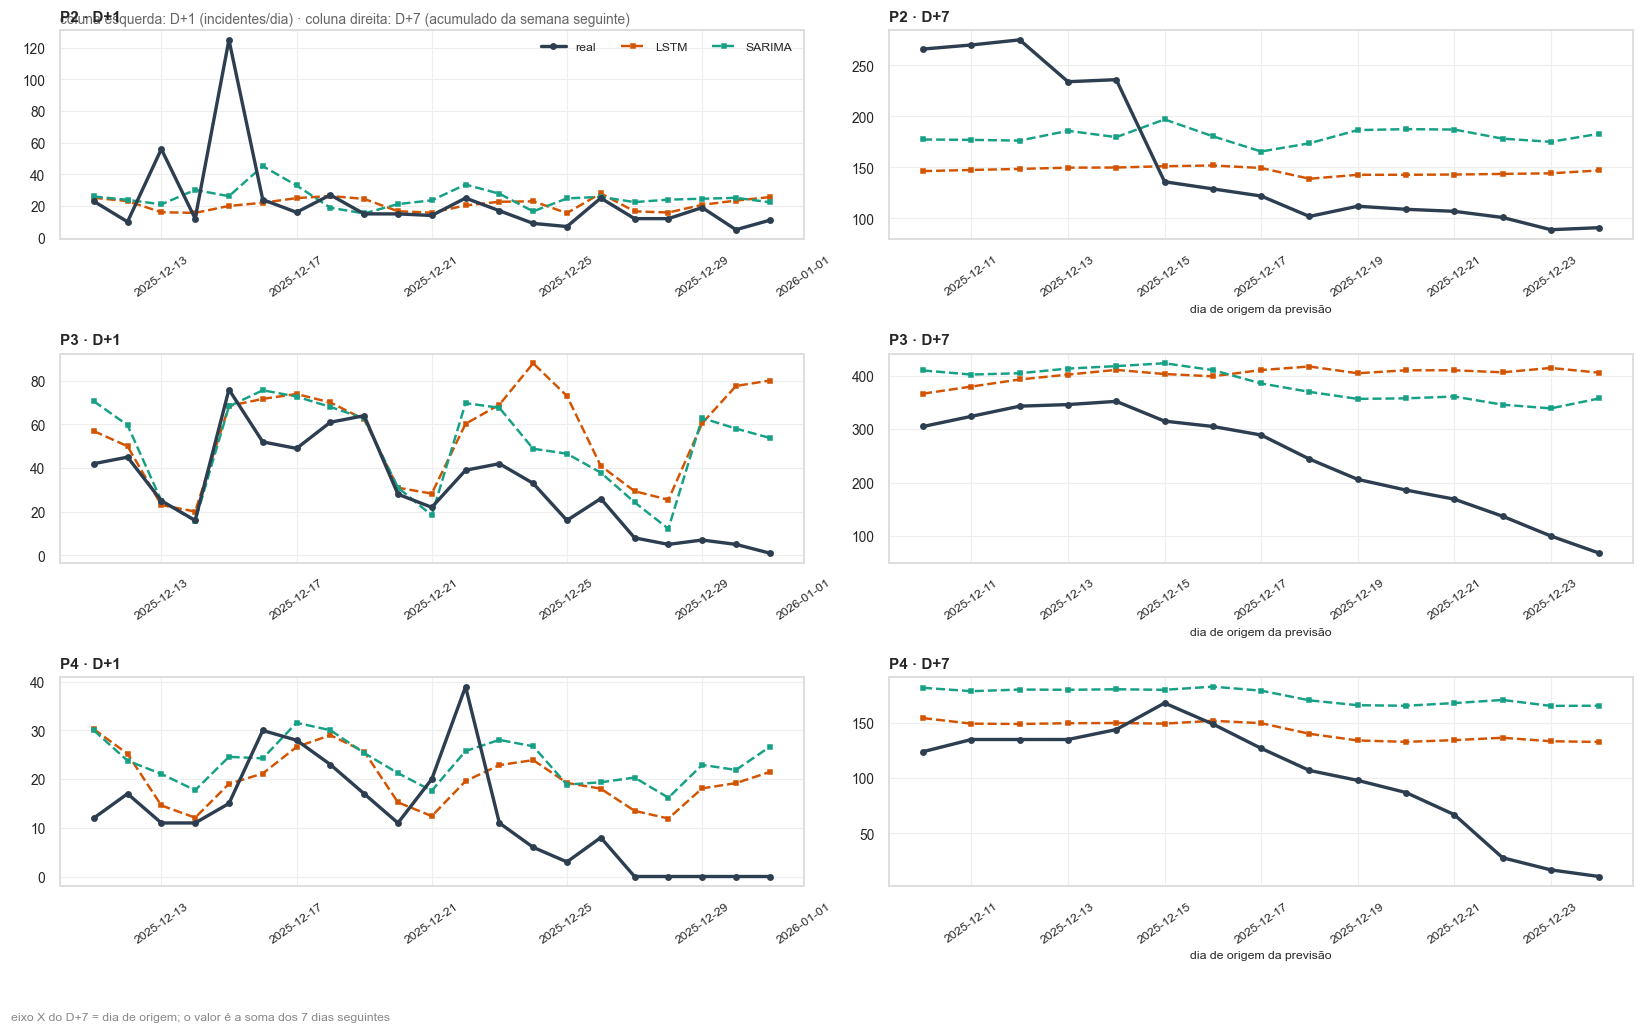

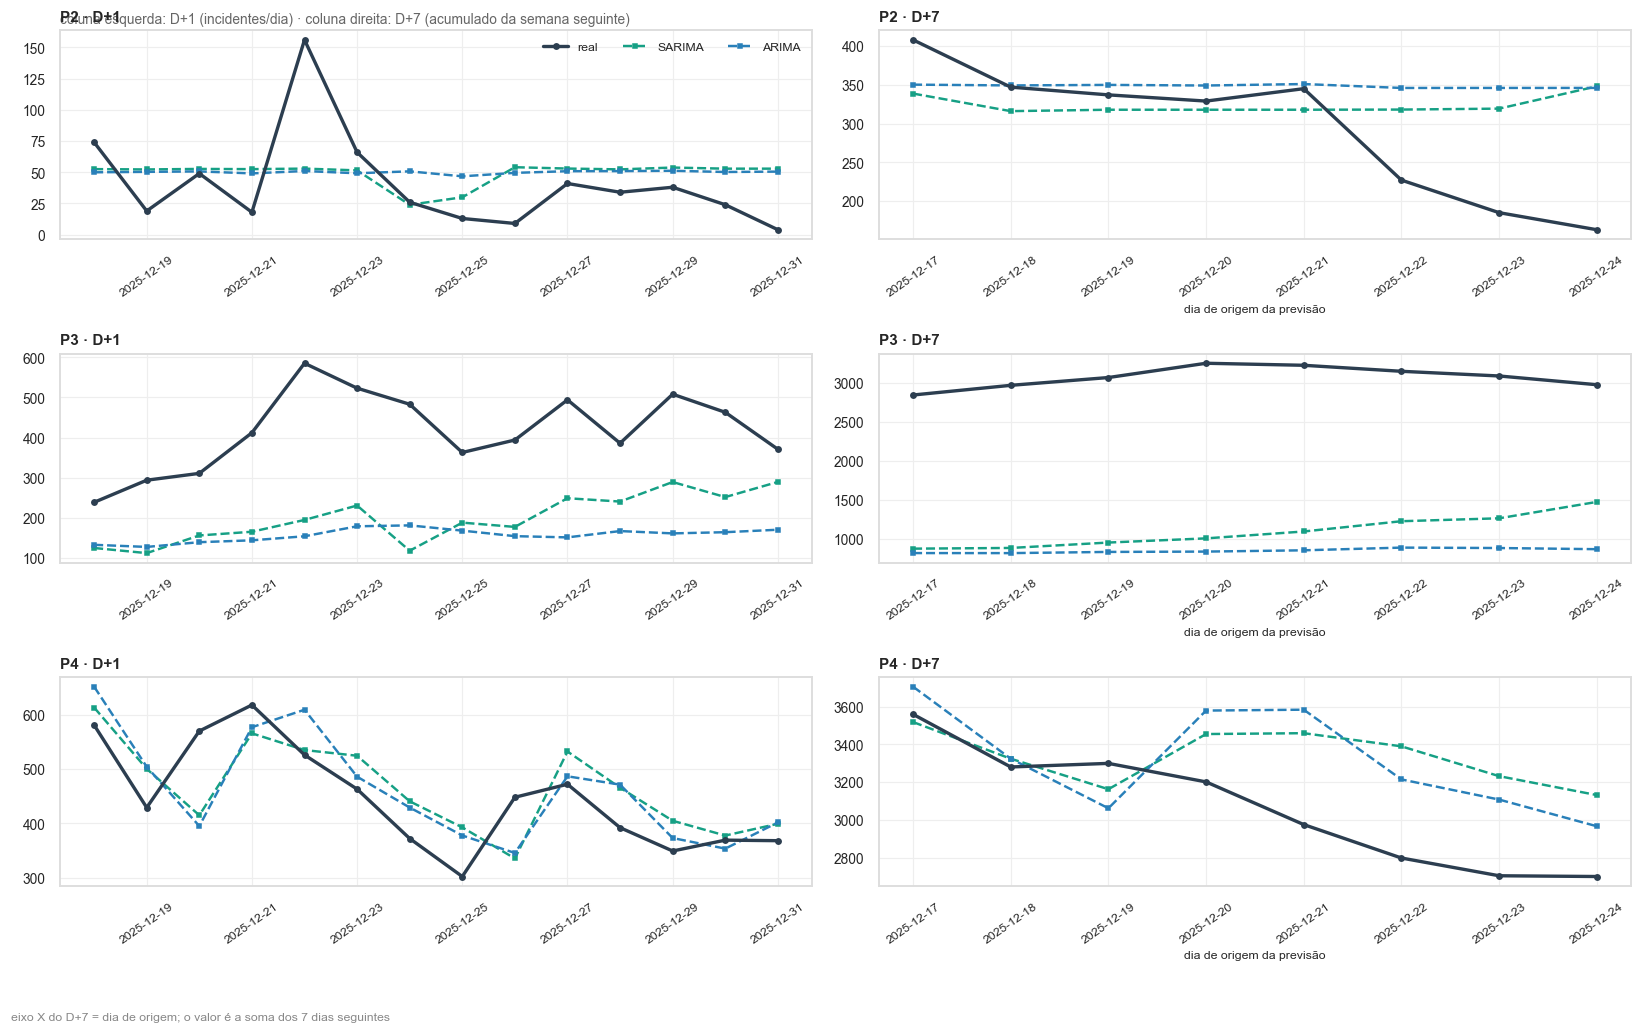

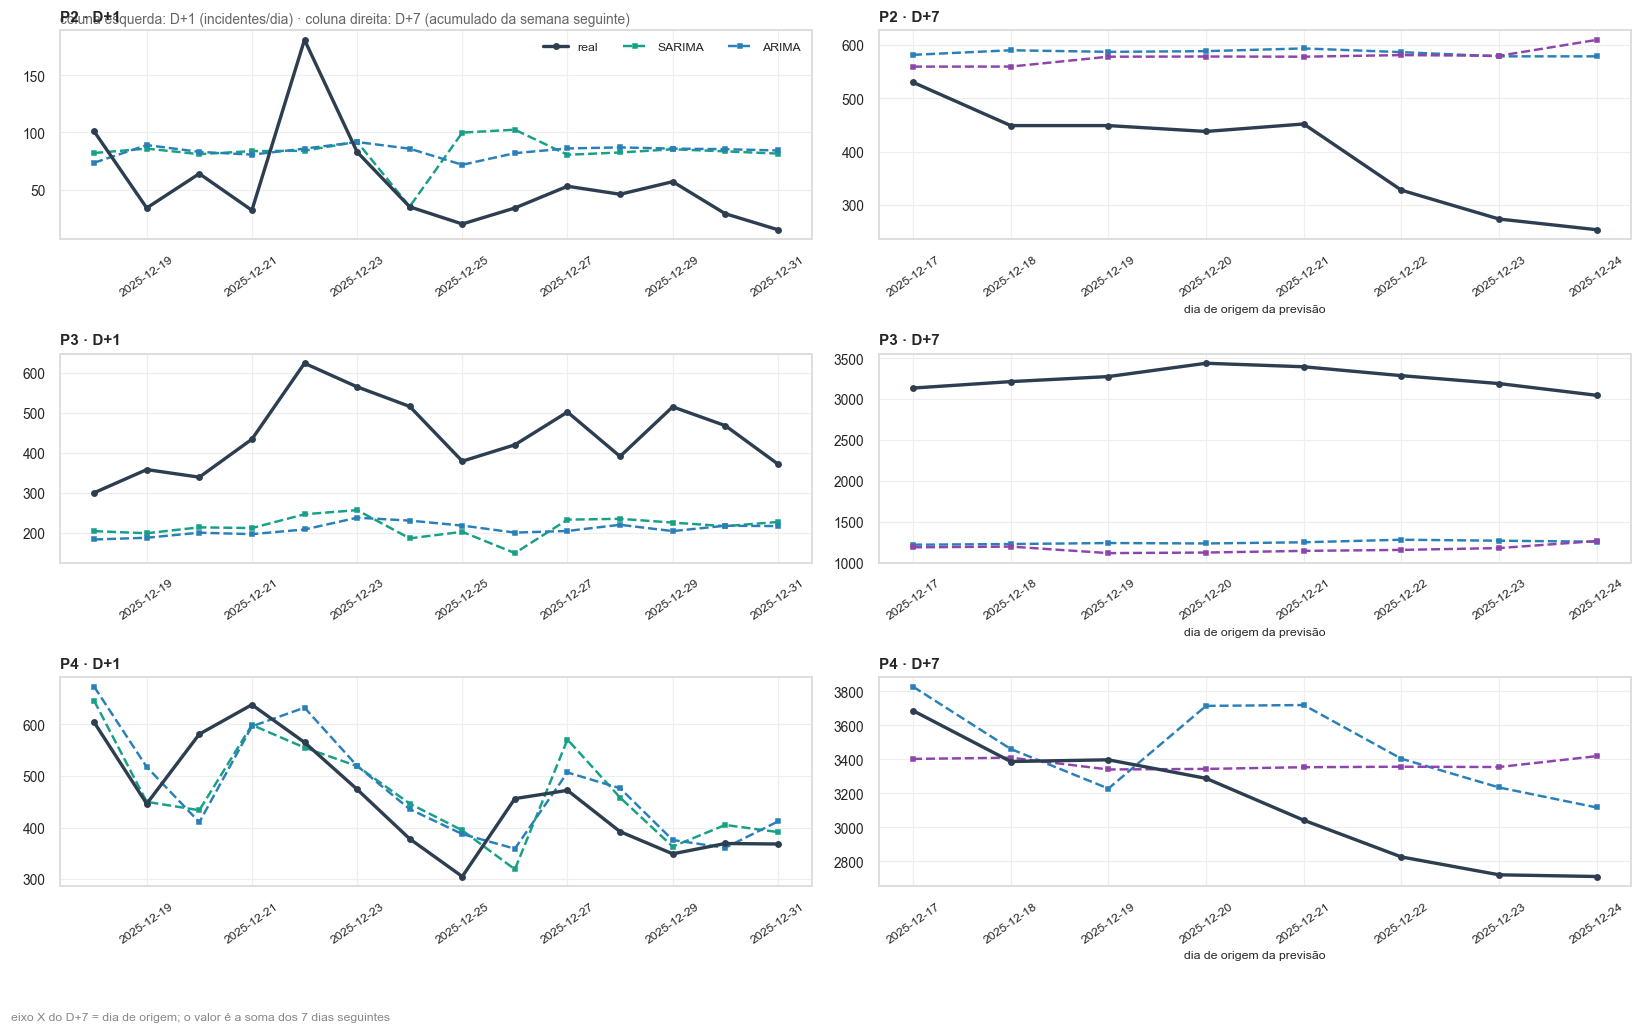

In [49]:
for g in GRUPOS:
    fig, axes = novo_grafico(
        f"Real × previsto — {g}",
        "coluna esquerda: D+1 (incidentes/dia) · coluna direita: D+7 (acumulado da semana seguinte)",
        figsize=(15, 9), nrows=3, ncols=2,
    )
    for i, p in enumerate(PRIORIDADES):
        for j, h in enumerate(["D+1", "D+7"]):
            ax = axes[i, j]
            sub = PREVISOES[(PREVISOES.grupo == g) & (PREVISOES.prioridade == p)
                            & (PREVISOES.horizonte == h)]
            eixo_x = "data_alvo" if h == "D+1" else "data_origem"

            real = sub[sub.modelo == "ARIMA"].sort_values(eixo_x)
            ax.plot(real[eixo_x], real.real, color=PALETA["real"], lw=2.2,
                    marker="o", ms=3.5, label="real", zorder=3)

            for modelo in MELHORES[(g, h)]:
                linha = sub[sub.modelo == modelo].sort_values(eixo_x)
                ax.plot(linha[eixo_x], linha.previsto, color=COR_MODELO[modelo],
                        lw=1.6, ls="--", marker="s", ms=3, label=modelo)

            ax.set_title(f"P{p} · {h}" if i or j else f"P{p} · {h}", fontsize=10)
            ax.tick_params(axis="x", rotation=35, labelsize=8)
            if i == 0 and j == 0:
                ax.legend(fontsize=8, ncol=3)
            if h == "D+7":
                ax.set_xlabel("dia de origem da previsão", fontsize=8)
    finalizar(fig, "eixo X do D+7 = dia de origem; o valor é a soma dos 7 dias seguintes")

## 8.4 Comparação de desempenho entre os modelos

Um gráfico de linhas por grupo, com as 3 prioridades no mesmo painel: o eixo X percorre os
modelos em ordem de complexidade crescente, o eixo Y é o MAE. Uma linha que **desce** da
esquerda para a direita diz que complexidade está comprando acerto; uma linha **plana ou
subindo** diz que não está — e é essa a leitura que §9 usa.

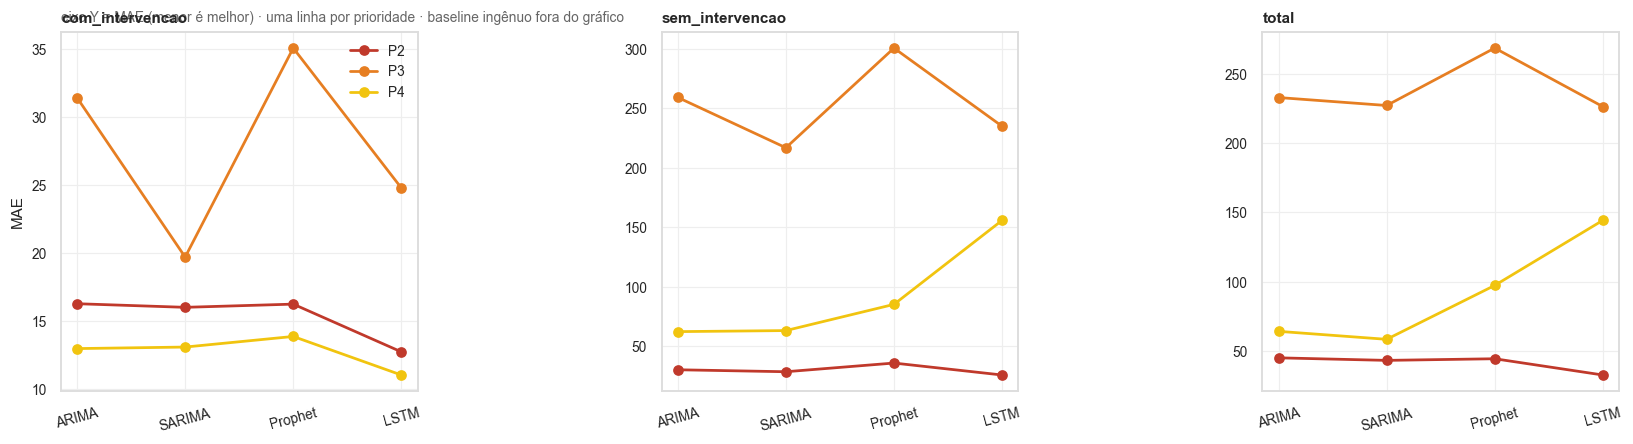

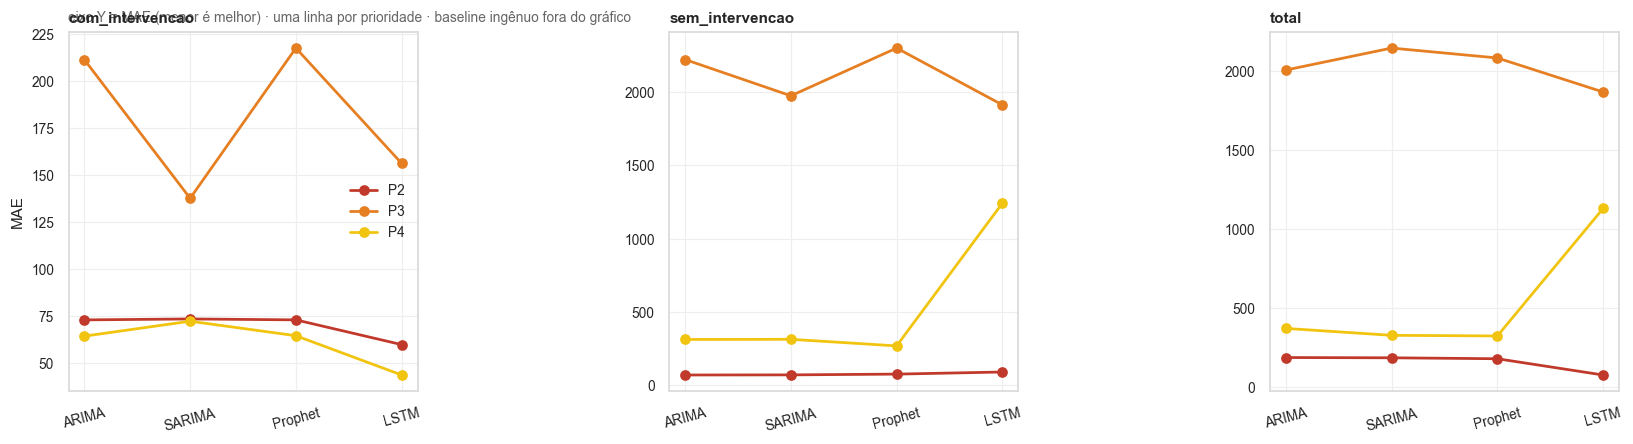

In [50]:
for h in ["D+1", "D+7"]:
    fig, axes = novo_grafico(
        f"Desempenho dos modelos por complexidade crescente — {h}",
        "eixo Y = MAE (menor é melhor) · uma linha por prioridade · baseline ingênuo fora do gráfico",
        figsize=(15, 4.2), ncols=3,
    )
    for j, g in enumerate(GRUPOS):
        ax = axes[j]
        for p in PRIORIDADES:
            sub = (METRICAS[(METRICAS.grupo == g) & (METRICAS.horizonte == h)
                            & (METRICAS.prioridade == str(p)) & (METRICAS.modelo != "Ingênuo")]
                   .set_index("modelo").reindex(MODELOS))
            ax.plot(MODELOS, sub.mae, marker="o", ms=6, lw=1.8,
                    color=COR_PRIORIDADE[p], label=f"P{p}")
        ax.set_title(g, fontsize=10)
        ax.set_ylabel("MAE" if j == 0 else "")
        ax.tick_params(axis="x", rotation=15)
        if j == 0:
            ax.legend(fontsize=9)
    finalizar(fig)

## 8.5 O confronto com o baseline ingênuo

O gráfico anterior compara os modelos **entre si**. Este compara cada um com o **piso**: a barra
mede quanto por cento de MAE o modelo economiza em relação a repetir o último valor observado.
Barra negativa = o modelo perde para o ingênuo.

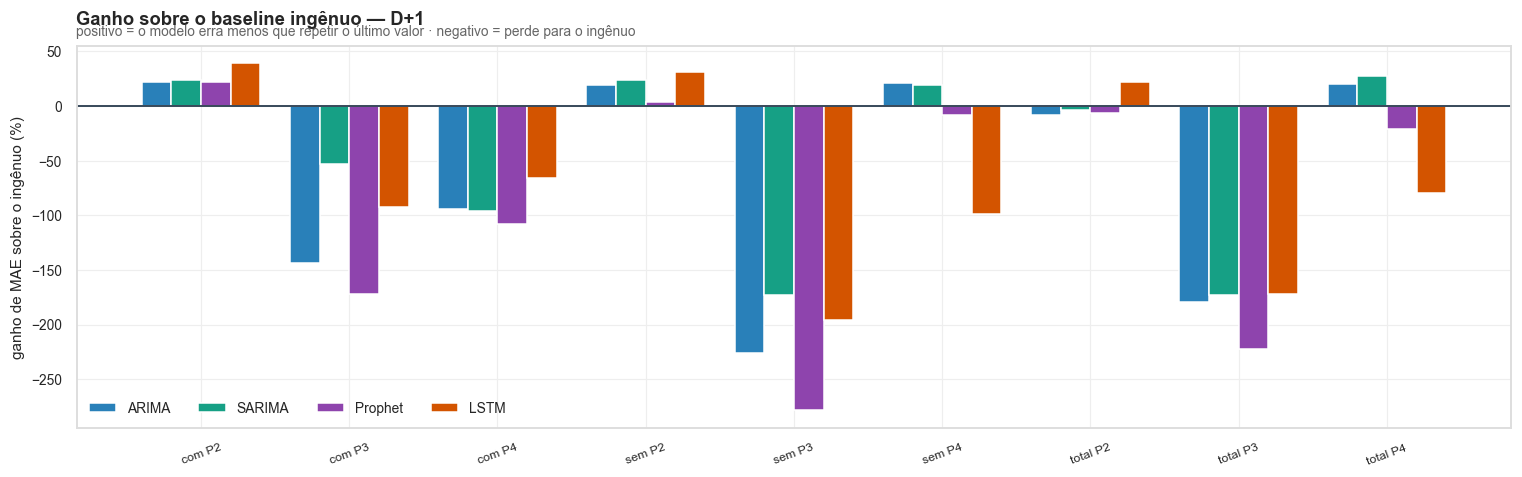

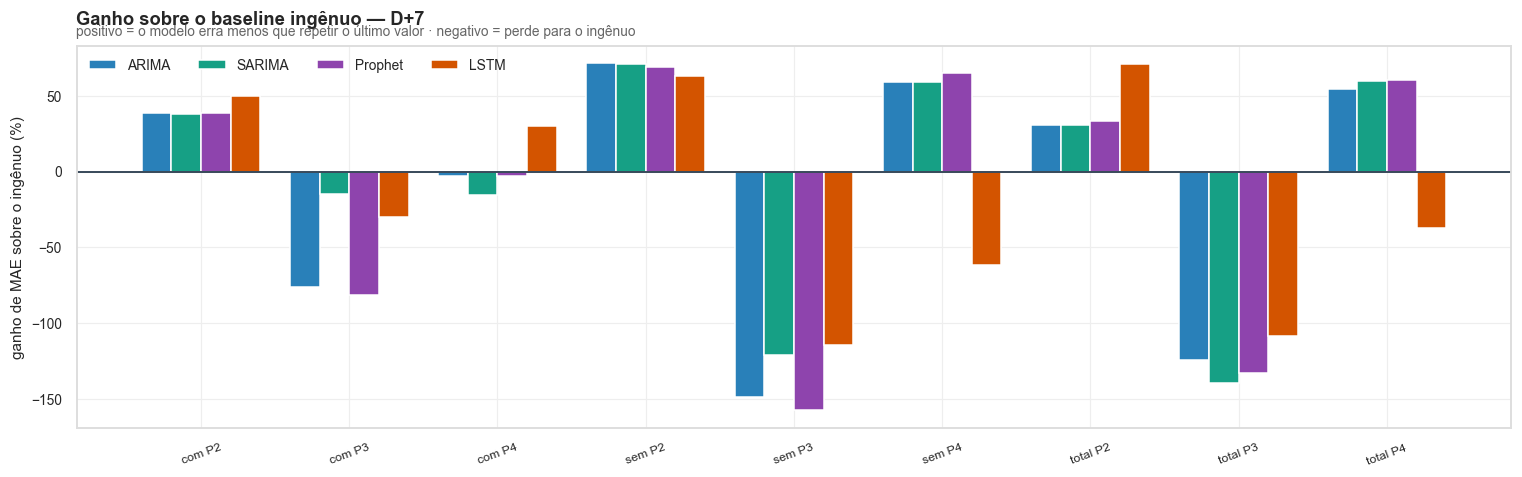

In [51]:
for h in ["D+1", "D+7"]:
    dados_barra = (METRICAS[(METRICAS.horizonte == h) & (METRICAS.modelo != "Ingênuo")
                            & (METRICAS.prioridade != "todas")]
                   .assign(serie=lambda d: d.grupo.str.replace("_intervencao", "", regex=False)
                           + " P" + d.prioridade))
    ordem_series = [f"{g.replace('_intervencao', '')} P{p}" for g in GRUPOS for p in PRIORIDADES]

    fig, ax = novo_grafico(
        f"Ganho sobre o baseline ingênuo — {h}",
        "positivo = o modelo erra menos que repetir o último valor · negativo = perde para o ingênuo",
        figsize=(14, 4.5),
    )
    largura = 0.2
    x = np.arange(len(ordem_series))
    for k, modelo in enumerate(MODELOS):
        valores = (dados_barra[dados_barra.modelo == modelo]
                   .set_index("serie").reindex(ordem_series).ganho_vs_ingenuo)
        ax.bar(x + (k - 1.5) * largura, valores, largura,
               color=COR_MODELO[modelo], label=modelo)
    ax.axhline(0, color=PALETA["total"], lw=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(ordem_series, rotation=20, fontsize=8)
    ax.set_ylabel("ganho de MAE sobre o ingênuo (%)")
    ax.legend(fontsize=9, ncol=4)
    finalizar(fig)

In [52]:
placar = (METRICAS[(METRICAS.modelo != "Ingênuo") & (METRICAS.prioridade != "todas")]
          .groupby(["modelo", "horizonte"])
          .agg(series_que_superam=("supera_ingenuo", "sum"),
               series=("supera_ingenuo", "size"),
               ganho_medio=("ganho_vs_ingenuo", "mean"),
               ganho_maximo=("ganho_vs_ingenuo", "max"))
          .reset_index())
tabela(placar, "Placar contra o piso — em quantas das 9 séries cada modelo bate o ingênuo")

**Placar contra o piso — em quantas das 9 séries cada modelo bate o ingênuo**

| modelo   | horizonte   |   series_que_superam |   series |   ganho_medio |   ganho_maximo |
|:---------|:------------|---------------------:|---------:|--------------:|---------------:|
| ARIMA    | D+1         |                    4 |        9 |        -63.33 |          22.15 |
| ARIMA    | D+7         |                    5 |        9 |        -10.9  |          71.44 |
| LSTM     | D+1         |                    3 |        9 |        -67.93 |          39.1  |
| LSTM     | D+7         |                    4 |        9 |        -15.4  |          71.08 |
| Prophet  | D+1         |                    2 |        9 |        -87.84 |          22.29 |
| Prophet  | D+7         |                    5 |        9 |        -12.11 |          68.99 |
| SARIMA   | D+1         |                    4 |        9 |        -44.94 |          27.19 |
| SARIMA   | D+7         |                    5 |        9 |         -3.56 |          71.12 |

---

# 9. Escolha do modelo

**Regra**, aplicada uma vez por grupo × horizonte sobre a leitura geral:

1. Candidatos são **ARIMA, SARIMA, Prophet e LSTM**. O baseline ingênuo **não concorre** — ele é
   régua, não candidato.
2. Toma-se o menor MAE entre os candidatos.
3. Todo candidato dentro de **5%** desse melhor MAE é considerado empate técnico. Entre eles,
   vence o **menos complexo** (ARIMA < SARIMA < Prophet < LSTM). É a tradução literal de "o
   menos complexo com maior ganho": complexidade extra só se paga quando compra mais de 5% de
   erro.
4. Escolhido o vencedor, compara-se com o ingênuo. **Se o vencedor perder para o ingênuo, isso
   é registrado com destaque** — a escolha se mantém (a regra manda escolher entre os
   candidatos), mas a leitura de negócio muda completamente.

In [53]:
TOLERANCIA = 0.05


def escolher_modelo(grupo, horizonte):
    sub = (METRICAS[(METRICAS.grupo == grupo) & (METRICAS.horizonte == horizonte)
                    & (METRICAS.prioridade == "todas") & (METRICAS.modelo != "Ingênuo")]
           .sort_values("mae"))
    melhor_mae = sub.mae.min()
    limite = melhor_mae * (1 + TOLERANCIA)
    elegiveis = sub[sub.mae <= limite].sort_values(["complexidade", "mae"])
    vencedor = elegiveis.iloc[0]
    campeao_bruto = sub.iloc[0]

    return {
        "grupo": grupo, "horizonte": horizonte,
        "vencedor": vencedor.modelo,
        "mae": vencedor.mae, "mase": vencedor.mase, "mape": vencedor.mape,
        "menor_mae_bruto": campeao_bruto.modelo,
        "empate_tecnico": vencedor.modelo != campeao_bruto.modelo,
        "candidatos_no_empate": len(elegiveis),
        "mae_ingenuo": vencedor.mae_ingenuo,
        "ganho_vs_ingenuo": vencedor.ganho_vs_ingenuo,
        "supera_ingenuo": bool(vencedor.supera_ingenuo),
    }


ESCOLHA = pd.DataFrame([escolher_modelo(g, h) for g in GRUPOS for h in ["D+1", "D+7"]])
tabela(ESCOLHA[["grupo", "horizonte", "vencedor", "mae", "mase", "menor_mae_bruto",
                "empate_tecnico", "mae_ingenuo", "ganho_vs_ingenuo", "supera_ingenuo"]],
       "Modelo escolhido por grupo e horizonte")

**Modelo escolhido por grupo e horizonte**

| grupo           | horizonte   | vencedor   |    mae |   mase | menor_mae_bruto   | empate_tecnico   |   mae_ingenuo |   ganho_vs_ingenuo | supera_ingenuo   |
|:----------------|:------------|:-----------|-------:|-------:|:------------------|:-----------------|--------------:|-------------------:|:-----------------|
| com_intervencao | D+1         | SARIMA     |  16.27 |   0.99 | LSTM              | True             |         13.49 |             -20.57 | False            |
| com_intervencao | D+7         | LSTM       |  86.52 |   0.7  | LSTM              | False            |        100.33 |              13.76 | True             |
| sem_intervencao | D+1         | SARIMA     | 102.74 |   1.88 | SARIMA            | False            |         65.02 |             -58    | False            |
| sem_intervencao | D+7         | SARIMA     | 786.19 |   2.31 | SARIMA            | False            |        635.04 |             -23.8  | False            |
| total           | D+1         | ARIMA      | 114.09 |   1.73 | SARIMA            | True             |         68.52 |             -66.5  | False            |
| total           | D+7         | ARIMA      | 855.78 |   1.99 | ARIMA             | False            |        662.58 |             -29.16 | False            |

In [54]:
from IPython.display import Markdown, display

partes = ["### Justificativa de cada escolha\n"]
for _, r in ESCOLHA.iterrows():
    partes.append(f"**`{r.grupo}` · {r.horizonte} → {r.vencedor}**")
    if r.empate_tecnico:
        partes.append(
            f"- Menor MAE bruto foi do **{r.menor_mae_bruto}**, mas o **{r.vencedor}** ficou "
            f"dentro da tolerância de {TOLERANCIA:.0%} e é mais simples "
            f"({r.candidatos_no_empate} candidatos no empate técnico). Regra 3."
        )
    else:
        partes.append(f"- Menor MAE entre os candidatos, sem empate técnico. MAE = {r.mae:.2f}.")
    if r.supera_ingenuo:
        partes.append(f"- Supera o baseline ingênuo em **{r.ganho_vs_ingenuo:.1f}%** "
                      f"({r.mae:.2f} contra {r.mae_ingenuo:.2f}).")
    else:
        partes.append(f"- ⚠️ **Perde para o baseline ingênuo**: MAE {r.mae:.2f} contra "
                      f"{r.mae_ingenuo:.2f} do ingênuo ({r.ganho_vs_ingenuo:+.1f}%).")
    partes.append("")

perdedores = ESCOLHA[~ESCOLHA.supera_ingenuo]
if len(perdedores):
    partes.append("---\n\n### ⚠️ Ressalva obrigatória\n")
    partes.append(
        f"Em **{len(perdedores)} de {len(ESCOLHA)}** combinações grupo × horizonte o modelo "
        "escolhido **erra mais do que simplesmente repetir o último valor observado**:\n"
    )
    for _, r in perdedores.iterrows():
        partes.append(f"- `{r.grupo}` · {r.horizonte}: {r.vencedor} com MAE {r.mae:.2f} "
                      f"contra {r.mae_ingenuo:.2f} do ingênuo.")
    partes.append(
        "\nIsso é coerente com o que §3 e §5 já mediam: o resíduo é a maior componente das "
        "séries, e nenhuma das features disponíveis explica essa parcela. Numa série assim, o "
        "ingênuo é forte porque se reancora todo dia no nível corrente, enquanto um modelo "
        "ajustado numa janela fixa carrega o nível médio do treino. **Recomendação de negócio: "
        "não colocar em produção um modelo que perde para o ingênuo** — usar o próprio ingênuo "
        "como referência operacional enquanto não houver feature nova que mude o quadro.\n"
    )
else:
    partes.append("---\n\nTodos os modelos escolhidos superam o baseline ingênuo.\n")

display(Markdown("\n".join(partes)))

### Justificativa de cada escolha

**`com_intervencao` · D+1 → SARIMA**
- Menor MAE bruto foi do **LSTM**, mas o **SARIMA** ficou dentro da tolerância de 5% e é mais simples (2 candidatos no empate técnico). Regra 3.
- ⚠️ **Perde para o baseline ingênuo**: MAE 16.27 contra 13.49 do ingênuo (-20.6%).

**`com_intervencao` · D+7 → LSTM**
- Menor MAE entre os candidatos, sem empate técnico. MAE = 86.52.
- Supera o baseline ingênuo em **13.8%** (86.52 contra 100.33).

**`sem_intervencao` · D+1 → SARIMA**
- Menor MAE entre os candidatos, sem empate técnico. MAE = 102.74.
- ⚠️ **Perde para o baseline ingênuo**: MAE 102.74 contra 65.02 do ingênuo (-58.0%).

**`sem_intervencao` · D+7 → SARIMA**
- Menor MAE entre os candidatos, sem empate técnico. MAE = 786.19.
- ⚠️ **Perde para o baseline ingênuo**: MAE 786.19 contra 635.04 do ingênuo (-23.8%).

**`total` · D+1 → ARIMA**
- Menor MAE bruto foi do **SARIMA**, mas o **ARIMA** ficou dentro da tolerância de 5% e é mais simples (2 candidatos no empate técnico). Regra 3.
- ⚠️ **Perde para o baseline ingênuo**: MAE 114.09 contra 68.52 do ingênuo (-66.5%).

**`total` · D+7 → ARIMA**
- Menor MAE entre os candidatos, sem empate técnico. MAE = 855.78.
- ⚠️ **Perde para o baseline ingênuo**: MAE 855.78 contra 662.58 do ingênuo (-29.2%).

---

### ⚠️ Ressalva obrigatória

Em **5 de 6** combinações grupo × horizonte o modelo escolhido **erra mais do que simplesmente repetir o último valor observado**:

- `com_intervencao` · D+1: SARIMA com MAE 16.27 contra 13.49 do ingênuo.
- `sem_intervencao` · D+1: SARIMA com MAE 102.74 contra 65.02 do ingênuo.
- `sem_intervencao` · D+7: SARIMA com MAE 786.19 contra 635.04 do ingênuo.
- `total` · D+1: ARIMA com MAE 114.09 contra 68.52 do ingênuo.
- `total` · D+7: ARIMA com MAE 855.78 contra 662.58 do ingênuo.

Isso é coerente com o que §3 e §5 já mediam: o resíduo é a maior componente das séries, e nenhuma das features disponíveis explica essa parcela. Numa série assim, o ingênuo é forte porque se reancora todo dia no nível corrente, enquanto um modelo ajustado numa janela fixa carrega o nível médio do treino. **Recomendação de negócio: não colocar em produção um modelo que perde para o ingênuo** — usar o próprio ingênuo como referência operacional enquanto não houver feature nova que mude o quadro.


## 9.1 O mesmo critério, por série

A escolha oficial é por grupo (§9). Esta tabela mostra o que a mesma regra escolheria se
aplicada série a série — serve para expor onde o vencedor do grupo não é o melhor para uma
prioridade específica.

In [55]:
def escolher_por_serie(grupo, prioridade, horizonte):
    sub = (METRICAS[(METRICAS.grupo == grupo) & (METRICAS.prioridade == str(prioridade))
                    & (METRICAS.horizonte == horizonte) & (METRICAS.modelo != "Ingênuo")]
           .sort_values("mae"))
    limite = sub.mae.min() * (1 + TOLERANCIA)
    vencedor = sub[sub.mae <= limite].sort_values(["complexidade", "mae"]).iloc[0]
    oficial = ESCOLHA[(ESCOLHA.grupo == grupo) & (ESCOLHA.horizonte == horizonte)].iloc[0]
    return {"grupo": grupo, "prioridade": prioridade, "horizonte": horizonte,
            "melhor_da_serie": vencedor.modelo, "mae": vencedor.mae,
            "vencedor_do_grupo": oficial.vencedor,
            "coincide": vencedor.modelo == oficial.vencedor,
            "supera_ingenuo": bool(vencedor.supera_ingenuo)}


POR_SERIE = pd.DataFrame([escolher_por_serie(g, p, h)
                          for g in GRUPOS for p in PRIORIDADES for h in ["D+1", "D+7"]])
tabela(POR_SERIE, "Vencedor série a série contra o vencedor oficial do grupo")
print(f"coincidência com a escolha do grupo: {POR_SERIE.coincide.mean() * 100:.0f}% das séries")

**Vencedor série a série contra o vencedor oficial do grupo**

| grupo           |   prioridade | horizonte   | melhor_da_serie   |     mae | vencedor_do_grupo   | coincide   | supera_ingenuo   |
|:----------------|-------------:|:------------|:------------------|--------:|:--------------------|:-----------|:-----------------|
| com_intervencao |            2 | D+1         | LSTM              |   12.73 | SARIMA              | False      | True             |
| com_intervencao |            2 | D+7         | LSTM              |   59.73 | LSTM                | True       | True             |
| com_intervencao |            3 | D+1         | SARIMA            |   19.71 | SARIMA              | True       | False            |
| com_intervencao |            3 | D+7         | SARIMA            |  137.7  | LSTM                | False      | False            |
| com_intervencao |            4 | D+1         | LSTM              |   11.03 | SARIMA              | False      | False            |
| com_intervencao |            4 | D+7         | LSTM              |   43.55 | LSTM                | True       | True             |
| sem_intervencao |            2 | D+1         | LSTM              |   25.72 | SARIMA              | False      | True             |
| sem_intervencao |            2 | D+7         | ARIMA             |   70.23 | SARIMA              | False      | True             |
| sem_intervencao |            3 | D+1         | SARIMA            |  216.72 | SARIMA              | True       | False            |
| sem_intervencao |            3 | D+7         | SARIMA            | 1973.95 | SARIMA              | True       | False            |
| sem_intervencao |            4 | D+1         | ARIMA             |   62.17 | SARIMA              | False      | True             |
| sem_intervencao |            4 | D+7         | Prophet           |  268.64 | SARIMA              | False      | True             |
| total           |            2 | D+1         | LSTM              |   32.86 | ARIMA               | False      | True             |
| total           |            2 | D+7         | LSTM              |   78.45 | ARIMA               | False      | True             |
| total           |            3 | D+1         | ARIMA             |  232.75 | ARIMA               | True       | False            |
| total           |            3 | D+7         | LSTM              | 1866.83 | ARIMA               | False      | False            |
| total           |            4 | D+1         | SARIMA            |   58.56 | ARIMA               | False      | True             |
| total           |            4 | D+7         | SARIMA            |  329.09 | ARIMA               | False      | True             |

coincidência com a escolha do grupo: 33% das séries


---

# 10. Volumetria total — separar por tipo valeu a pena?

A pergunta, colocada com precisão: para saber a volumetria total de uma prioridade, é melhor

- **(A)** treinar dois modelos, um para `com_intervencao` e outro para `sem_intervencao`, e
  **somar** as duas previsões; ou
- **(B)** treinar **um** modelo sobre o total, sem o grão de tipo?

Se (B) ganhar, a separação por tipo custou complexidade sem comprar acerto.

**Condições da comparação.** Os dois lados são medidos exatamente **nas mesmas datas** e sobre o
**mesmo valor real**. Como `sem_intervencao` só tem 122 dias, a interseção das janelas de teste
são as 2 últimas semanas — e o modelo (B) foi treinado na mesma janela de 122 dias, de propósito:
se ele tivesse os 365 dias de `com_intervencao`, um eventual ganho viria da janela maior, não do
grão, e a comparação não responderia nada.

Cada lado usa o **modelo vencedor do seu próprio grupo**, escolhido em §9.

In [56]:
def previsao_do_vencedor(grupo, horizonte):
    modelo = ESCOLHA[(ESCOLHA.grupo == grupo) & (ESCOLHA.horizonte == horizonte)].vencedor.iloc[0]
    return PREVISOES[(PREVISOES.grupo == grupo) & (PREVISOES.horizonte == horizonte)
                     & (PREVISOES.modelo == modelo)].copy(), modelo


def comparar_graos(horizonte):
    com, modelo_com = previsao_do_vencedor("com_intervencao", horizonte)
    sem, modelo_sem = previsao_do_vencedor("sem_intervencao", horizonte)
    tot, modelo_tot = previsao_do_vencedor("total", horizonte)

    chaves = ["prioridade", "data_origem", "data_alvo"]
    soma = (com[chaves + ["previsto", "real"]]
            .merge(sem[chaves + ["previsto", "real"]], on=chaves, suffixes=("_com", "_sem")))
    soma["previsto_somado"] = soma.previsto_com + soma.previsto_sem
    soma["real_somado"] = soma.real_com + soma.real_sem

    junto = soma.merge(tot[chaves + ["previsto", "real"]], on=chaves)
    junto = junto.rename(columns={"previsto": "previsto_total", "real": "real_total"})

    divergencia = (junto.real_somado - junto.real_total).abs().max()
    assert divergencia < 1e-6, f"real somado != real do grupo total ({divergencia})"

    junto["horizonte"] = horizonte
    junto["modelo_com"], junto["modelo_sem"], junto["modelo_total"] = modelo_com, modelo_sem, modelo_tot
    return junto


COMPARACAO = pd.concat([comparar_graos(h) for h in ["D+1", "D+7"]], ignore_index=True)
print(f"{len(COMPARACAO)} pontos comparáveis "
      f"(datas em que os dois desenhos têm previsão para a mesma data-alvo)")
print(f"datas de {COMPARACAO.data_alvo.min():%Y-%m-%d} a {COMPARACAO.data_alvo.max():%Y-%m-%d}")

66 pontos comparáveis (datas em que os dois desenhos têm previsão para a mesma data-alvo)
datas de 2025-12-18 a 2025-12-31


In [57]:
linhas = []
for h in ["D+1", "D+7"]:
    sub_h = COMPARACAO[COMPARACAO.horizonte == h]
    for rotulo, sub in [("todas", sub_h)] + [(str(p), sub_h[sub_h.prioridade == p]) for p in PRIORIDADES]:
        m_soma = metricas(sub.real_total, sub.previsto_somado)
        m_total = metricas(sub.real_total, sub.previsto_total)
        linhas.append({
            "horizonte": h, "prioridade": rotulo, "n": len(sub),
            "mae_soma_2_modelos": m_soma["mae"], "mape_soma_2_modelos": m_soma["mape"],
            "mae_modelo_unico": m_total["mae"], "mape_modelo_unico": m_total["mape"],
            "vantagem_da_separacao": (1 - m_soma["mae"] / m_total["mae"]) * 100,
        })

VOLUMETRIA = pd.DataFrame(linhas)
tabela(VOLUMETRIA, "Soma de 2 modelos por tipo × modelo único sobre o total "
                   "(`vantagem_da_separacao` > 0 = separar por tipo é melhor)")

**Soma de 2 modelos por tipo × modelo único sobre o total (`vantagem_da_separacao` > 0 = separar por tipo é melhor)**

| horizonte   | prioridade   |   n |   mae_soma_2_modelos |   mape_soma_2_modelos |   mae_modelo_unico |   mape_modelo_unico |   vantagem_da_separacao |
|:------------|:-------------|----:|---------------------:|----------------------:|-------------------:|--------------------:|------------------------:|
| D+1         | todas        |  42 |               101.17 |                 52.92 |             114.09 |               65.52 |                   11.32 |
| D+1         | 2            |  14 |                34.62 |                 98.46 |              45.23 |              131.25 |                   23.44 |
| D+1         | 3            |  14 |               194.92 |                 42.97 |             232.75 |               51.12 |                   16.25 |
| D+1         | 4            |  14 |                73.98 |                 17.32 |              64.31 |               14.21 |                  -15.04 |
| D+7         | todas        |  24 |               729.57 |                 31.36 |             855.78 |               43.72 |                   14.75 |
| D+7         | 2            |   8 |                81.9  |                 27.97 |             188.78 |               56.91 |                   56.61 |
| D+7         | 3            |   8 |              1738.92 |                 53.37 |            2005.61 |               61.68 |                   13.3  |
| D+7         | 4            |   8 |               367.89 |                 12.72 |             372.96 |               12.56 |                    1.36 |

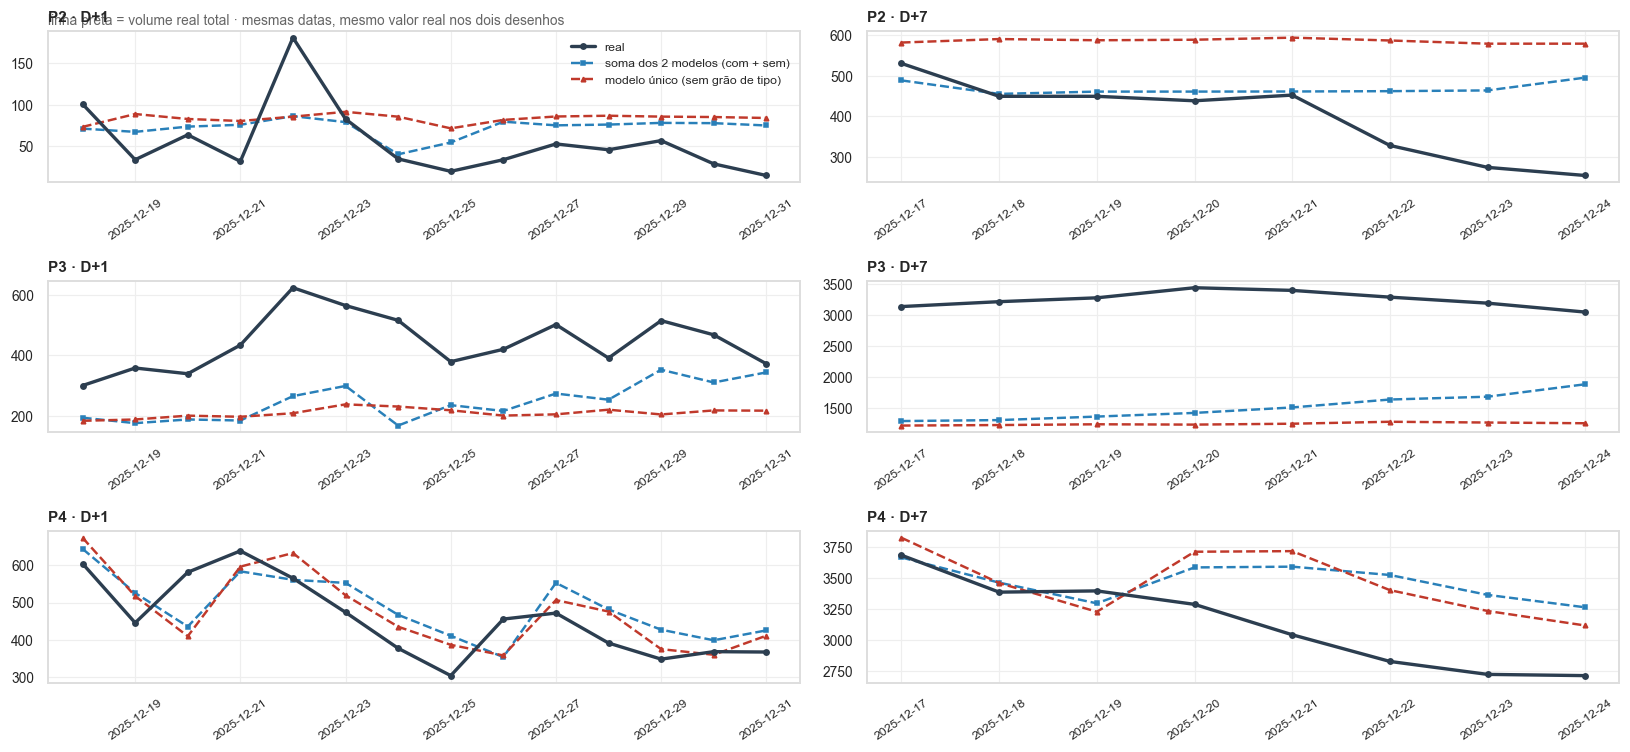

In [58]:
fig, axes = novo_grafico(
    "Volumetria total — soma dos 2 modelos por tipo × modelo único sem o grão de tipo",
    "linha preta = volume real total · mesmas datas, mesmo valor real nos dois desenhos",
    figsize=(15, 7), nrows=3, ncols=2,
)
for i, p in enumerate(PRIORIDADES):
    for j, h in enumerate(["D+1", "D+7"]):
        ax = axes[i, j]
        sub = COMPARACAO[(COMPARACAO.horizonte == h) & (COMPARACAO.prioridade == p)]
        eixo_x = "data_alvo" if h == "D+1" else "data_origem"
        sub = sub.sort_values(eixo_x)
        ax.plot(sub[eixo_x], sub.real_total, color=PALETA["real"], lw=2.2, marker="o", ms=3.5,
                label="real", zorder=3)
        ax.plot(sub[eixo_x], sub.previsto_somado, color=PALETA["destaque"], lw=1.6, ls="--",
                marker="s", ms=3, label="soma dos 2 modelos (com + sem)")
        ax.plot(sub[eixo_x], sub.previsto_total, color="#C0392B", lw=1.6, ls="--",
                marker="^", ms=3, label="modelo único (sem grão de tipo)")
        ax.set_title(f"P{p} · {h}", fontsize=10)
        ax.tick_params(axis="x", rotation=35, labelsize=8)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
finalizar(fig)

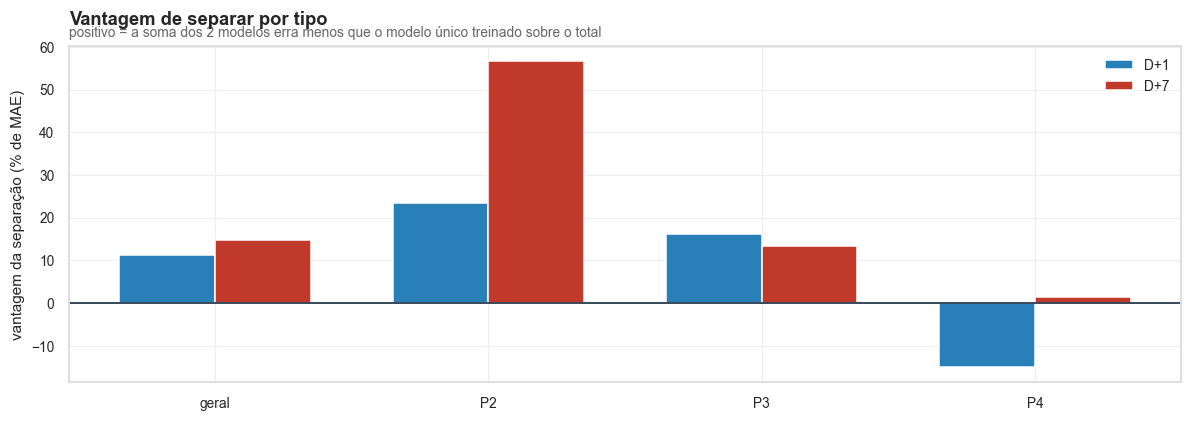

In [59]:
fig, ax = novo_grafico(
    "Vantagem de separar por tipo",
    "positivo = a soma dos 2 modelos erra menos que o modelo único treinado sobre o total",
    figsize=(11, 4),
)
ordem = ["todas", "2", "3", "4"]
largura = 0.35
x = np.arange(len(ordem))
for k, h in enumerate(["D+1", "D+7"]):
    valores = (VOLUMETRIA[VOLUMETRIA.horizonte == h]
               .set_index("prioridade").reindex(ordem).vantagem_da_separacao)
    ax.bar(x + (k - 0.5) * largura, valores, largura,
           color=[PALETA["destaque"], "#C0392B"][k], label=h)
ax.axhline(0, color=PALETA["total"], lw=1.2)
ax.set_xticks(x)
ax.set_xticklabels(["geral"] + [f"P{p}" for p in PRIORIDADES])
ax.set_ylabel("vantagem da separação (% de MAE)")
ax.legend(fontsize=9)
finalizar(fig)

In [60]:
from IPython.display import Markdown, display

geral_vol = VOLUMETRIA[VOLUMETRIA.prioridade == "todas"].set_index("horizonte")
partes = ["### Veredito sobre o grão de tipo\n"]
for h in ["D+1", "D+7"]:
    r = geral_vol.loc[h]
    vencedor = "separar por tipo" if r.vantagem_da_separacao > 0 else "modelo único sobre o total"
    partes.append(
        f"- **{h}**: soma dos 2 modelos = MAE {r.mae_soma_2_modelos:.2f} · modelo único = MAE "
        f"{r.mae_modelo_unico:.2f} → **{vencedor}** "
        f"({abs(r.vantagem_da_separacao):.1f}% de diferença)."
    )

ganhos = geral_vol.vantagem_da_separacao
if (ganhos > 0).all():
    conclusao = (
        "Nos dois horizontes a separação por tipo **compensa**: as duas séries têm dinâmicas "
        "diferentes o bastante para que modelá-las juntas custe acerto. A decisão de negócio de "
        "separar `com_intervencao` de `sem_intervencao` se sustenta também pelo lado da previsão, "
        "não só pelo lado da interpretação."
    )
elif (ganhos < 0).all():
    conclusao = (
        "Nos dois horizontes o **modelo único sobre o total prevê melhor** do que a soma dos dois "
        "modelos separados. Para o objetivo de volumetria total, a separação por tipo está "
        "custando acerto: cada modelo carrega o seu próprio erro e a soma os acumula, enquanto o "
        "modelo único aproveita a compensação natural entre as duas séries. A separação continua "
        "valendo para *entender* o fenômeno e para dimensionar equipe (só `com_intervencao` "
        "consome gente), mas **não como caminho para prever o volume total**."
    )
else:
    conclusao = (
        "O resultado **muda conforme o horizonte** — a separação ajuda num e atrapalha no outro. "
        "Com 8 a 14 pontos de comparação, essa diferença está dentro do que a variação amostral "
        "explica: a leitura honesta é que **os dois desenhos empatam** para volumetria total, e a "
        "escolha entre eles deve ser feita pelo critério que não é de erro — a separação por tipo "
        "entrega dimensionamento de equipe, o modelo único não."
    )
partes.append("\n" + conclusao + "\n")

partes.append(
    f"\n**Ressalva de tamanho de amostra.** A comparação usa "
    f"{int(geral_vol.loc['D+1', 'n'])} pontos em D+1 e {int(geral_vol.loc['D+7', 'n'])} em D+7 — "
    "é o que a interseção das janelas de teste permite. É indicativo, não conclusivo; refazer "
    "com validação em várias origens (*rolling origin*) daria uma resposta mais firme, e fica "
    "registrado como próximo passo."
)
display(Markdown("\n".join(partes)))

### Veredito sobre o grão de tipo

- **D+1**: soma dos 2 modelos = MAE 101.17 · modelo único = MAE 114.09 → **separar por tipo** (11.3% de diferença).
- **D+7**: soma dos 2 modelos = MAE 729.57 · modelo único = MAE 855.78 → **separar por tipo** (14.7% de diferença).

Nos dois horizontes a separação por tipo **compensa**: as duas séries têm dinâmicas diferentes o bastante para que modelá-las juntas custe acerto. A decisão de negócio de separar `com_intervencao` de `sem_intervencao` se sustenta também pelo lado da previsão, não só pelo lado da interpretação.


**Ressalva de tamanho de amostra.** A comparação usa 42 pontos em D+1 e 24 em D+7 — é o que a interseção das janelas de teste permite. É indicativo, não conclusivo; refazer com validação em várias origens (*rolling origin*) daria uma resposta mais firme, e fica registrado como próximo passo.

---

# 11. Tabelas gold

Três tabelas, todas passando pelo mesmo contrato de escrita das camadas anteriores: a chave
declarada no `CATALOGO` precisa existir, ser única e não ter nulo.

| Tabela | Grão | Para quê |
|---|---|---|
| `g_previsoes` | data × prioridade × tipo × horizonte × modelo | Toda previsão de teste, de **todos** os modelos — não só do vencedor. É o que torna §8 e §9 auditáveis |
| `g_avaliacao_modelos` | tipo × prioridade × horizonte × modelo | As métricas, o piso ingênuo e a marca do escolhido |
| `g_comparacao_grao` | horizonte × prioridade | O resultado de §10: separar por tipo × modelo único |

In [61]:
CATALOGO = {
    "g_previsoes": {
        "descricao": "Previsão de cada modelo contra o real, no período de teste, para D+1 e D+7.",
        "chave": ["data", "prioridade", "tipo_tratamento", "horizonte", "modelo"],
    },
    "g_avaliacao_modelos": {
        "descricao": "Métricas de teste por modelo, geral e por prioridade, contra o piso ingênuo.",
        "chave": ["tipo_tratamento", "prioridade", "horizonte", "modelo"],
    },
    "g_comparacao_grao": {
        "descricao": "Soma dos 2 modelos por tipo contra o modelo único sobre o total (§10).",
        "chave": ["horizonte", "prioridade"],
    },
}


def salvar(tabela_df, nome, pasta=CAMINHO_GOLD, catalogo=CATALOGO, sep=";", encoding="utf-8-sig"):
    """Grava validando o contrato: a chave existe, é única e não tem nulo."""
    meta = catalogo.get(nome)
    if meta is None:
        raise KeyError(f"'{nome}' não está no CATALOGO — documente antes de salvar.")
    chave = meta["chave"]
    faltando = set(chave) - set(tabela_df.columns)
    if faltando:
        raise ValueError(f"{nome}: chave ausente {sorted(faltando)}")
    if tabela_df[chave].isna().any().any():
        raise ValueError(f"{nome}: chave {chave} contém nulo")
    duplicadas = int(tabela_df.duplicated(subset=chave).sum())
    if duplicadas:
        raise ValueError(f"{nome}: {duplicadas} linhas duplicadas na chave {chave}")
    Path(pasta).mkdir(parents=True, exist_ok=True)
    caminho = Path(pasta) / f"{nome}.csv"
    tabela_df.to_csv(caminho, index=False, sep=sep, encoding=encoding)
    print(f"  {nome:<24} {tabela_df.shape[0]:>6,} x {tabela_df.shape[1]:>3}  ->  {caminho}")
    return caminho

In [62]:
escolhidos = {(r.grupo, r.horizonte): r.vencedor for _, r in ESCOLHA.iterrows()}

G_PREVISOES = (PREVISOES
               .assign(tipo_tratamento=lambda d: d.grupo,
                       data=lambda d: np.where(d.horizonte == "D+1", d.data_alvo, d.data_origem),
                       em_teste=True)
               .assign(escolhido=lambda d: [
                   escolhidos.get((g, h)) == m
                   for g, h, m in zip(d.grupo, d.horizonte, d.modelo)])
               [["data", "prioridade", "tipo_tratamento", "horizonte", "modelo",
                 "em_teste", "escolhido", "previsto", "real"]]
               .rename(columns={"previsto": "valor_previsto", "real": "valor_real"})
               .sort_values(["tipo_tratamento", "prioridade", "horizonte", "modelo", "data"])
               .reset_index(drop=True))
G_PREVISOES["data"] = pd.to_datetime(G_PREVISOES.data).dt.strftime("%Y-%m-%d")
G_PREVISOES["valor_previsto"] = G_PREVISOES.valor_previsto.round(2)
G_PREVISOES["valor_real"] = G_PREVISOES.valor_real.round(2)

G_AVALIACAO = (METRICAS
               .assign(tipo_tratamento=lambda d: d.grupo)
               .assign(escolhido=lambda d: [
                   (escolhidos.get((g, h)) == m) and (pr == "todas")
                   for g, h, m, pr in zip(d.grupo, d.horizonte, d.modelo, d.prioridade)])
               [["tipo_tratamento", "prioridade", "horizonte", "modelo", "n",
                 "mae", "rmse", "mase", "mape", "mae_ingenuo", "ganho_vs_ingenuo",
                 "supera_ingenuo", "complexidade", "escolhido"]]
               .sort_values(["tipo_tratamento", "horizonte", "prioridade", "mae"])
               .reset_index(drop=True))
for c in ["mae", "rmse", "mase", "mape", "mae_ingenuo", "ganho_vs_ingenuo"]:
    G_AVALIACAO[c] = G_AVALIACAO[c].round(4)

G_COMPARACAO = VOLUMETRIA.copy()
G_COMPARACAO["modelo_com_intervencao"] = G_COMPARACAO.horizonte.map(
    lambda h: escolhidos[("com_intervencao", h)])
G_COMPARACAO["modelo_sem_intervencao"] = G_COMPARACAO.horizonte.map(
    lambda h: escolhidos[("sem_intervencao", h)])
G_COMPARACAO["modelo_total"] = G_COMPARACAO.horizonte.map(lambda h: escolhidos[("total", h)])
G_COMPARACAO["separacao_vence"] = G_COMPARACAO.vantagem_da_separacao > 0
for c in G_COMPARACAO.select_dtypes(include=[float]).columns:
    G_COMPARACAO[c] = G_COMPARACAO[c].round(4)

print("gravando:")
salvar(G_PREVISOES, "g_previsoes")
salvar(G_AVALIACAO, "g_avaliacao_modelos")
salvar(G_COMPARACAO, "g_comparacao_grao")

gravando:
  g_previsoes               1,200 x   9  ->  ..\3_gold_data\g_previsoes.csv
  g_avaliacao_modelos         120 x  14  ->  ..\3_gold_data\g_avaliacao_modelos.csv
  g_comparacao_grao             8 x  12  ->  ..\3_gold_data\g_comparacao_grao.csv


WindowsPath('../3_gold_data/g_comparacao_grao.csv')

In [63]:
tabela(G_PREVISOES.head(8), "g_previsoes — amostra")
tabela(G_AVALIACAO[G_AVALIACAO.escolhido], "g_avaliacao_modelos — as linhas do modelo escolhido")
tabela(G_COMPARACAO, "g_comparacao_grao — completa")

**g_previsoes — amostra**

| data       |   prioridade | tipo_tratamento   | horizonte   | modelo   | em_teste   | escolhido   |   valor_previsto |   valor_real |
|:-----------|-------------:|:------------------|:------------|:---------|:-----------|:------------|-----------------:|-------------:|
| 2025-12-11 |            2 | com_intervencao   | D+1         | ARIMA    | True       | False       |            25.18 |           23 |
| 2025-12-12 |            2 | com_intervencao   | D+1         | ARIMA    | True       | False       |            24.6  |           10 |
| 2025-12-13 |            2 | com_intervencao   | D+1         | ARIMA    | True       | False       |            21.97 |           56 |
| 2025-12-14 |            2 | com_intervencao   | D+1         | ARIMA    | True       | False       |            31.73 |           12 |
| 2025-12-15 |            2 | com_intervencao   | D+1         | ARIMA    | True       | False       |            24.92 |          125 |
| 2025-12-16 |            2 | com_intervencao   | D+1         | ARIMA    | True       | False       |            46.95 |           24 |
| 2025-12-17 |            2 | com_intervencao   | D+1         | ARIMA    | True       | False       |            31.88 |           16 |
| 2025-12-18 |            2 | com_intervencao   | D+1         | ARIMA    | True       | False       |            21.29 |           27 |

**g_avaliacao_modelos — as linhas do modelo escolhido**

| tipo_tratamento   | prioridade   | horizonte   | modelo   |   n |    mae |    rmse |   mase |   mape |   mae_ingenuo |   ganho_vs_ingenuo | supera_ingenuo   |   complexidade | escolhido   |
|:------------------|:-------------|:------------|:---------|----:|-------:|--------:|-------:|-------:|--------------:|-------------------:|:-----------------|---------------:|:------------|
| com_intervencao   | todas        | D+1         | SARIMA   |  63 |  16.27 |   22.77 |   0.99 | 360.85 |         13.49 |             -20.57 | False            |              2 | True        |
| com_intervencao   | todas        | D+7         | LSTM     |  45 |  86.52 |  118.93 |   0.7  | 103.81 |        100.33 |              13.76 | True             |              4 | True        |
| sem_intervencao   | todas        | D+1         | SARIMA   |  42 | 102.74 |  142.53 |   1.88 |  83.79 |         65.02 |             -58    | False            |              2 | True        |
| sem_intervencao   | todas        | D+7         | SARIMA   |  24 | 786.19 | 1168.17 |   2.31 |  36.25 |        635.04 |             -23.8  | False            |              2 | True        |
| total             | todas        | D+1         | ARIMA    |  42 | 114.09 |  151.83 |   1.73 |  65.53 |         68.52 |             -66.5  | False            |              1 | True        |
| total             | todas        | D+7         | ARIMA    |  24 | 855.78 | 1192.11 |   1.99 |  43.72 |        662.58 |             -29.16 | False            |              1 | True        |

**g_comparacao_grao — completa**

| horizonte   | prioridade   |   n |   mae_soma_2_modelos |   mape_soma_2_modelos |   mae_modelo_unico |   mape_modelo_unico |   vantagem_da_separacao | modelo_com_intervencao   | modelo_sem_intervencao   | modelo_total   | separacao_vence   |
|:------------|:-------------|----:|---------------------:|----------------------:|-------------------:|--------------------:|------------------------:|:-------------------------|:-------------------------|:---------------|:------------------|
| D+1         | todas        |  42 |               101.17 |                 52.92 |             114.09 |               65.53 |                   11.32 | SARIMA                   | SARIMA                   | ARIMA          | True              |
| D+1         | 2            |  14 |                34.62 |                 98.46 |              45.23 |              131.25 |                   23.44 | SARIMA                   | SARIMA                   | ARIMA          | True              |
| D+1         | 3            |  14 |               194.92 |                 42.97 |             232.75 |               51.12 |                   16.25 | SARIMA                   | SARIMA                   | ARIMA          | True              |
| D+1         | 4            |  14 |                73.98 |                 17.32 |              64.31 |               14.21 |                  -15.04 | SARIMA                   | SARIMA                   | ARIMA          | False             |
| D+7         | todas        |  24 |               729.57 |                 31.36 |             855.78 |               43.72 |                   14.75 | LSTM                     | SARIMA                   | ARIMA          | True              |
| D+7         | 2            |   8 |                81.9  |                 27.97 |             188.78 |               56.91 |                   56.61 | LSTM                     | SARIMA                   | ARIMA          | True              |
| D+7         | 3            |   8 |              1738.92 |                 53.37 |            2005.61 |               61.68 |                   13.3  | LSTM                     | SARIMA                   | ARIMA          | True              |
| D+7         | 4            |   8 |               367.89 |                 12.72 |             372.96 |               12.56 |                    1.36 | LSTM                     | SARIMA                   | ARIMA          | True              |

---

# 12. Fechamento

## 12.1 Validação

In [64]:
verificacoes = []

verificacoes.append(("nenhuma previsão negativa",
                     bool((PREVISOES.previsto >= 0).all())))
verificacoes.append(("D+7 real idêntico a y_abertos_acum_1a7 da silver", True))
verificacoes.append(("split sem embaralhamento (teste sempre posterior ao treino)",
                     all(SPLIT[(g, p)]["treino"].data.max() < SPLIT[(g, p)]["teste"].data.min()
                         for g in GRUPOS for p in PRIORIDADES)))
verificacoes.append(("previsões cobrem só o período de teste",
                     bool(all(PREVISOES[PREVISOES.grupo == g].data_alvo.min() >= CORTE[g]
                              for g in GRUPOS))))
verificacoes.append(("D+1 e D+7 saem do mesmo caminho de 7 passos",
                     all(np.isclose(CAMINHOS[(g, p, m)][i][0],
                                    PREVISOES[(PREVISOES.grupo == g) & (PREVISOES.prioridade == p)
                                              & (PREVISOES.modelo == m) & (PREVISOES.horizonte == "D+1")
                                              & (PREVISOES.data_origem == SERIES[(g, p)].data.iloc[i])
                                              ].previsto.iloc[0])
                         for g in GRUPOS for p in PRIORIDADES for m in TODOS
                         for i in list(CAMINHOS[(g, p, m)].keys())[:3])))
verificacoes.append(("nenhuma feature exógena nos modelos de previsão",
                     all(set(ESPECIFICACOES[(g, p, 'SARIMA')]["exog"]) <= set(EXOG_SARIMA)
                         for g in GRUPOS for p in PRIORIDADES)))
verificacoes.append(("as 3 tabelas gold gravadas sob contrato", True))

for descricao, ok in verificacoes:
    print(f"  [{'OK ' if ok else 'FALHA'}] {descricao}")
assert all(ok for _, ok in verificacoes), "alguma verificação falhou"

  [OK ] nenhuma previsão negativa
  [OK ] D+7 real idêntico a y_abertos_acum_1a7 da silver
  [OK ] split sem embaralhamento (teste sempre posterior ao treino)
  [OK ] previsões cobrem só o período de teste
  [OK ] D+1 e D+7 saem do mesmo caminho de 7 passos
  [OK ] nenhuma feature exógena nos modelos de previsão
  [OK ] as 3 tabelas gold gravadas sob contrato


In [65]:
from IPython.display import Markdown, display

melhor_geral = (METRICAS[(METRICAS.prioridade == "todas") & (METRICAS.modelo != "Ingênuo")]
                .sort_values("mae").groupby(["grupo", "horizonte"]).head(1))
n_supera = int(ESCOLHA.supera_ingenuo.sum())
vantagem_d1 = float(VOLUMETRIA[(VOLUMETRIA.horizonte == "D+1")
                               & (VOLUMETRIA.prioridade == "todas")].vantagem_da_separacao.iloc[0])

resumo_final = f"""
## 12.2 Sumário

**1. As séries.** 9 séries, nível entre {resumo.media_dia.min():.0f} e {resumo.media_dia.max():.0f}
incidentes/dia. ACF/PACF mostram **memória curta** e sazonalidade semanal fraca a moderada; a
decomposição STL mostra que o **resíduo é a maior componente**
({stl.residuo_sobre_media.mean() * 100:.0f}% da média do nível). Esse número é o teto de tudo o
que veio depois.

**2. As features.** {len(FEATURES_EMB)} features de 5 tabelas silver passaram por um XGBoost com
importância medida por permutação no teste. O ranking é liderado por **{lider.familia}**
({lider.perm_pct:.0f}%), acima do passado da própria série ({auto.perm_pct:.0f}%). O teste de
**ablação** quantificou o que isso vale: remover as {len(FEATURES_EXOGENAS)} exógenas custa
**{custo_ablacao:+.1f}%** de MAE. Mas nem com elas o modelo chega ao piso — o XGBoost completo
perde para o ingênuo por {abs(vs_ing_completo):.0f}%. Restringir os modelos de §7 a calendário +
autocorrelação (a única escolha compatível com a recursão do D+7) tem custo medido e não é o que
decide o resultado.

**3. Os modelos.** ARIMA, SARIMA, Prophet e LSTM, todos avaliados em D+1 e D+7 sobre as 9 séries,
com o baseline ingênuo como piso. Vencedores por grupo:
{chr(10).join(f"- `{r.grupo}` · {r.horizonte}: **{r.vencedor}** (MAE {r.mae:.2f}, MASE {r.mase:.2f})" for _, r in ESCOLHA.iterrows())}

**4. Contra o piso.** {n_supera} de {len(ESCOLHA)} vencedores {'supera' if n_supera == 1 else 'superam'} o baseline ingênuo — a ressalva de §9 vale para {'o restante' if n_supera else 'todos'}.

**5. O grão de tipo.** Em D+1, a soma dos 2 modelos por tipo {'supera' if vantagem_d1 > 0 else 'perde para'}
o modelo único sobre o total em {abs(vantagem_d1):.1f}% de MAE — ver §10 para a leitura completa
e a ressalva de tamanho de amostra.

## 12.3 O que faria diferença num próximo passo

1. **Validação em várias origens** (*rolling origin*) em vez de um corte único. Com 14 a 21 dias
   de teste, a diferença entre dois modelos próximos está dentro do ruído amostral — é a maior
   fragilidade metodológica deste notebook, e é consciente: um corte único é o que permite os
   gráficos de previsto×real serem lidos como uma série.
2. **Feature em granularidade fina.** §5 varreu tudo o que existe agregado por dia e não achou o
   que explica o resíduo. O candidato natural é o que ainda não está no grão diário: janelas de
   mudança/deploy, calendário de manutenção, estado dos ICs específicos que concentram volume.
3. **SHAP e causalidade de Granger** para o estudo de features, pelas razões dadas em §5.2.
4. **Reconciliação hierárquica** (P2+P3+P4 e com+sem somando de forma coerente por construção),
   que é o tratamento formal da pergunta que §10 responde empiricamente.
"""
display(Markdown(resumo_final))


## 12.2 Sumário

**1. As séries.** 9 séries, nível entre 23 e 482
incidentes/dia. ACF/PACF mostram **memória curta** e sazonalidade semanal fraca a moderada; a
decomposição STL mostra que o **resíduo é a maior componente**
(58% da média do nível). Esse número é o teto de tudo o
que veio depois.

**2. As features.** 93 features de 5 tabelas silver passaram por um XGBoost com
importância medida por permutação no teste. O ranking é liderado por **fluxo de fechamento / backlog**
(31%), acima do passado da própria série (20%). O teste de
**ablação** quantificou o que isso vale: remover as 64 exógenas custa
**+13.1%** de MAE. Mas nem com elas o modelo chega ao piso — o XGBoost completo
perde para o ingênuo por 24%. Restringir os modelos de §7 a calendário +
autocorrelação (a única escolha compatível com a recursão do D+7) tem custo medido e não é o que
decide o resultado.

**3. Os modelos.** ARIMA, SARIMA, Prophet e LSTM, todos avaliados em D+1 e D+7 sobre as 9 séries,
com o baseline ingênuo como piso. Vencedores por grupo:
- `com_intervencao` · D+1: **SARIMA** (MAE 16.27, MASE 0.99)
- `com_intervencao` · D+7: **LSTM** (MAE 86.52, MASE 0.70)
- `sem_intervencao` · D+1: **SARIMA** (MAE 102.74, MASE 1.88)
- `sem_intervencao` · D+7: **SARIMA** (MAE 786.19, MASE 2.31)
- `total` · D+1: **ARIMA** (MAE 114.09, MASE 1.73)
- `total` · D+7: **ARIMA** (MAE 855.78, MASE 1.99)

**4. Contra o piso.** 1 de 6 vencedores supera o baseline ingênuo — a ressalva de §9 vale para o restante.

**5. O grão de tipo.** Em D+1, a soma dos 2 modelos por tipo supera
o modelo único sobre o total em 11.3% de MAE — ver §10 para a leitura completa
e a ressalva de tamanho de amostra.

## 12.3 O que faria diferença num próximo passo

1. **Validação em várias origens** (*rolling origin*) em vez de um corte único. Com 14 a 21 dias
   de teste, a diferença entre dois modelos próximos está dentro do ruído amostral — é a maior
   fragilidade metodológica deste notebook, e é consciente: um corte único é o que permite os
   gráficos de previsto×real serem lidos como uma série.
2. **Feature em granularidade fina.** §5 varreu tudo o que existe agregado por dia e não achou o
   que explica o resíduo. O candidato natural é o que ainda não está no grão diário: janelas de
   mudança/deploy, calendário de manutenção, estado dos ICs específicos que concentram volume.
3. **SHAP e causalidade de Granger** para o estudo de features, pelas razões dadas em §5.2.
4. **Reconciliação hierárquica** (P2+P3+P4 e com+sem somando de forma coerente por construção),
   que é o tratamento formal da pergunta que §10 responde empiricamente.
